PHASE 1: DATA PREPARATION AND PRELIMINARY PROCESSING

Data Cleaning Missing Value Assessment Outlier Investigation Variable Construction

In [1]:
import pandas as pd

file_path = "/Users/goldenofforson/ADDI STUDY DISCO/COMP NERC DISCO DATA 2015 TO 2023.xlsx"

df = pd.read_excel(file_path)

df.head()

,DISCO,VARIABLE,2015-01-01 00:00:00,2015-02-01 00:00:00,2015-03-01 00:00:00,2015-04-01 00:00:00,2015-05-01 00:00:00,2015-06-01 00:00:00,2015-07-01 00:00:00,2015-08-01 00:00:00,...,Unnamed: 112,Unnamed: 113,Unnamed: 114,Unnamed: 115,1900-01-31 00:00:00,1900-02-28 00:00:00,1900-03-28 00:00:00,1900-04-28 00:00:00,1900-05-28 00:00:00,1900-06-28 00:00:00
0,ABUJA,total_customers,742602.0,746123.0,773412.0,768639.0,774408.0,775012.0,818216.0,826023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENIN,total_customers,818855.0,812302.0,811473.0,810153.0,804942.0,765832.0,759229.0,879247.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EKO,total_customers,383701.0,386861.0,388889.0,389333.0,394270.0,398905.0,402975.0,401671.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENUGU,total_customers,704288.0,713035.0,717345.0,710539.0,712047.0,703501.0,710104.0,717795.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IBADAN,total_customers,1428361.0,1438603.0,1447489.0,1464051.0,1478431.0,1513080.0,1523016.0,1531902.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd

file_path = "/Users/goldenofforson/ADDI STUDY DISCO/COMP NERC DISCO DATA 2015 TO 2023.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Sheet1']


In [4]:
for sheet in excel_file.sheet_names:
    temp = pd.read_excel(file_path, sheet_name=sheet)
    print(f"{sheet}: {temp.shape}")

Sheet1: (55, 122)


INSPECT DATA 

In [5]:
# Load the data
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Display dimensions
print("Dataset shape:", df.shape)

# Display all column names
print("\nCOLUMN NAMES:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

Dataset shape: (55, 122)

COLUMN NAMES:
0 'DISCO'
1 'VARIABLE '
2 datetime.datetime(2015, 1, 1, 0, 0)
3 datetime.datetime(2015, 2, 1, 0, 0)
4 datetime.datetime(2015, 3, 1, 0, 0)
5 datetime.datetime(2015, 4, 1, 0, 0)
6 datetime.datetime(2015, 5, 1, 0, 0)
7 datetime.datetime(2015, 6, 1, 0, 0)
8 datetime.datetime(2015, 7, 1, 0, 0)
9 datetime.datetime(2015, 8, 1, 0, 0)
10 datetime.datetime(2015, 9, 1, 0, 0)
11 datetime.datetime(2015, 10, 1, 0, 0)
12 datetime.datetime(2015, 11, 1, 0, 0)
13 datetime.datetime(2015, 12, 1, 0, 0)
14 datetime.datetime(2016, 1, 1, 0, 0)
15 datetime.datetime(2016, 2, 1, 0, 0)
16 datetime.datetime(2016, 3, 1, 0, 0)
17 datetime.datetime(2016, 4, 1, 0, 0)
18 datetime.datetime(2016, 5, 1, 0, 0)
19 datetime.datetime(2016, 6, 1, 0, 0)
20 datetime.datetime(2016, 7, 1, 0, 0)
21 datetime.datetime(2016, 8, 1, 0, 0)
22 datetime.datetime(2016, 9, 1, 0, 0)
23 datetime.datetime(2016, 10, 1, 0, 0)
24 datetime.datetime(2016, 11, 1, 0, 0)
25 datetime.datetime(2016, 12, 1, 0, 0)
26

In [6]:
print(df.iloc[:, 110:122].notna().sum())

Unnamed: 110           0
Unnamed: 111           0
Unnamed: 112           0
Unnamed: 113           0
Unnamed: 114           0
Unnamed: 115           0
1900-01-31 00:00:00    0
1900-02-28 00:00:00    0
1900-03-28 00:00:00    0
1900-04-28 00:00:00    0
1900-05-28 00:00:00    0
1900-06-28 00:00:00    0
dtype: int64


In [7]:
# Create a clean copy — preserve the original df
df_clean = df.dropna(axis=1, how='all').copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (55, 122)
Cleaned shape: (55, 110)


In [8]:
# Create a clean copy — preserve the original df
df_clean = df.dropna(axis=1, how='all').copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (55, 122)
Cleaned shape: (55, 110)


In [9]:
print("First column:", repr(df_clean.columns[0]))
print("Last column:", repr(df_clean.columns[-1]))

First column: 'DISCO'
Last column: datetime.datetime(2023, 12, 1, 0, 0)


In [10]:
print("First column:", repr(df_clean.columns[0]))
print("Last column:", repr(df_clean.columns[-1]))

First column: 'DISCO'
Last column: datetime.datetime(2023, 12, 1, 0, 0)


In [11]:
print("Actual column names:")
for i, col in enumerate(df_clean.columns[:10]):
    print(i, repr(col))

Actual column names:
0 'DISCO'
1 'VARIABLE '
2 datetime.datetime(2015, 1, 1, 0, 0)
3 datetime.datetime(2015, 2, 1, 0, 0)
4 datetime.datetime(2015, 3, 1, 0, 0)
5 datetime.datetime(2015, 4, 1, 0, 0)
6 datetime.datetime(2015, 5, 1, 0, 0)
7 datetime.datetime(2015, 6, 1, 0, 0)
8 datetime.datetime(2015, 7, 1, 0, 0)
9 datetime.datetime(2015, 8, 1, 0, 0)


In [12]:
print("Actual column names:")
for i, col in enumerate(df_clean.columns[:10]):
    print(i, repr(col))

Actual column names:
0 'DISCO'
1 'VARIABLE '
2 datetime.datetime(2015, 1, 1, 0, 0)
3 datetime.datetime(2015, 2, 1, 0, 0)
4 datetime.datetime(2015, 3, 1, 0, 0)
5 datetime.datetime(2015, 4, 1, 0, 0)
6 datetime.datetime(2015, 5, 1, 0, 0)
7 datetime.datetime(2015, 6, 1, 0, 0)
8 datetime.datetime(2015, 7, 1, 0, 0)
9 datetime.datetime(2015, 8, 1, 0, 0)


In [13]:
# Clean column-name whitespace
df_clean.columns = df_clean.columns.astype(str).str.strip()

print(df_clean.columns[:10].tolist())

['DISCO', 'VARIABLE', '2015-01-01 00:00:00', '2015-02-01 00:00:00', '2015-03-01 00:00:00', '2015-04-01 00:00:00', '2015-05-01 00:00:00', '2015-06-01 00:00:00', '2015-07-01 00:00:00', '2015-08-01 00:00:00']


In [14]:
print("Unique variables:")
print(df_clean["VARIABLE"].unique())

print("\nNumber of observations per variable:")
print(df_clean["VARIABLE"].value_counts())

print("\nNumber of DISCOs:")
print(df_clean["DISCO"].nunique())

print("\nDISCOs:")
print(df_clean["DISCO"].unique())

Unique variables:
['total_customers' 'metered_customers' 'estimated_customers '
 'energy_billed_gwh' 'revenue_collected_millions_ngn']

Number of observations per variable:
VARIABLE
total_customers                   11
metered_customers                 11
estimated_customers               11
energy_billed_gwh                 11
revenue_collected_millions_ngn    11
Name: count, dtype: int64

Number of DISCOs:
11

DISCOs:
['ABUJA' 'BENIN' 'EKO' 'ENUGU' 'IBADAN' 'IKEJA' 'JOS' 'KADUNA' 'KANO'
 'PORT HARCOURT' 'YOLA']


RESHAPE RAW DATA INTO THE DISCO-MONTH ANALYTICAL PANEL

In [15]:
# ============================================================
# RESHAPE NERC DATA INTO DISCO-MONTH PANEL
# ============================================================

# The first two columns are identifiers:
# DISCO and VARIABLE
# The remaining 108 columns are monthly observations.

date_columns = list(df_clean.columns[2:])

# Verify that we have exactly 108 monthly columns
print("Number of monthly columns:", len(date_columns))
print("First monthly column:", date_columns[0])
print("Last monthly column:", date_columns[-1])

# Reshape from wide format to long format
df_long = df_clean.melt(
    id_vars=["DISCO", "VARIABLE"],
    value_vars=date_columns,
    var_name="DATE",
    value_name="VALUE"
)

print("\nLong-format shape:", df_long.shape)

# Reshape variables into separate analytical columns
panel = df_long.pivot_table(
    index=["DISCO", "DATE"],
    columns="VARIABLE",
    values="VALUE",
    aggfunc="first"
).reset_index()

# Remove pivot column-axis name
panel.columns.name = None

# Sort chronologically
panel = panel.sort_values(
    ["DISCO", "DATE"]
).reset_index(drop=True)

print("\nFinal panel shape:", panel.shape)

print("\nPanel columns:")
print(panel.columns.tolist())

display(panel.head(12))

Number of monthly columns: 108
First monthly column: 2015-01-01 00:00:00
Last monthly column: 2023-12-01 00:00:00

Long-format shape: (5940, 4)

Final panel shape: (1188, 7)

Panel columns:
['DISCO', 'DATE', 'energy_billed_gwh', 'estimated_customers ', 'metered_customers', 'revenue_collected_millions_ngn', 'total_customers']


,DISCO,DATE,energy_billed_gwh,estimated_customers,metered_customers,revenue_collected_millions_ngn,total_customers
0,ABUJA,2015-01-01 00:00:00,246.0,385557.0,357045.0,3059.0,742602.0
1,ABUJA,2015-02-01 00:00:00,250.0,392159.0,353964.0,3119.0,746123.0
2,ABUJA,2015-03-01 00:00:00,244.0,393983.0,379429.0,3548.0,773412.0
3,ABUJA,2015-04-01 00:00:00,236.0,385335.0,383304.0,3423.0,768639.0
4,ABUJA,2015-05-01 00:00:00,212.0,383473.0,390935.0,2831.0,774408.0
5,ABUJA,2015-06-01 00:00:00,156.0,383473.0,391539.0,3126.0,775012.0
6,ABUJA,2015-07-01 00:00:00,227.0,438217.0,379999.0,3212.0,818216.0
7,ABUJA,2015-08-01 00:00:00,220.0,441481.0,384542.0,3139.0,826023.0
8,ABUJA,2015-09-01 00:00:00,250.0,430256.0,386195.0,3182.0,816451.0
9,ABUJA,2015-10-01 00:00:00,268.0,450306.0,375489.0,3357.0,825795.0


In [16]:
# ============================================================
# PANEL STRUCTURE QUALITY CONTROL
# ============================================================

print("Number of DISCOs:", panel["DISCO"].nunique())
print("Number of months:", panel["DATE"].nunique())
print("Total observations:", len(panel))

print("\nDate range:")
print("Start:", panel["DATE"].min())
print("End:", panel["DATE"].max())

print("\nObservations per DISCO:")
print(panel.groupby("DISCO").size())

print("\nDuplicate DISCO-DATE observations:")
print(panel.duplicated(["DISCO", "DATE"]).sum())

Number of DISCOs: 11
Number of months: 108
Total observations: 1188

Date range:
Start: 2015-01-01 00:00:00
End: 2023-12-01 00:00:00

Observations per DISCO:
DISCO
ABUJA            108
BENIN            108
EKO              108
ENUGU            108
IBADAN           108
IKEJA            108
JOS              108
KADUNA           108
KANO             108
PORT HARCOURT    108
YOLA             108
dtype: int64

Duplicate DISCO-DATE observations:
0


In [17]:
# ============================================================
# MISSING DATA AUDIT
# ============================================================

print("Missing observations by variable:")
print(panel.isna().sum())

print("\nMissing percentage:")
print((panel.isna().mean() * 100).round(2))

Missing observations by variable:
DISCO                             0
DATE                              0
energy_billed_gwh                 0
estimated_customers               0
metered_customers                 0
revenue_collected_millions_ngn    0
total_customers                   0
dtype: int64

Missing percentage:
DISCO                             0.0
DATE                              0.0
energy_billed_gwh                 0.0
estimated_customers               0.0
metered_customers                 0.0
revenue_collected_millions_ngn    0.0
total_customers                   0.0
dtype: float64


In [18]:
# ============================================================
# CORRECTION: STANDARDISE VARIABLE LABELS
# ============================================================

# Create a new working copy; preserve df_clean unchanged
df_work = df_clean.copy()

# Remove leading/trailing whitespace from DISCO and VARIABLE values
df_work["DISCO"] = df_work["DISCO"].astype(str).str.strip()
df_work["VARIABLE"] = df_work["VARIABLE"].astype(str).str.strip()

# Verify the variable labels after cleaning
print("VARIABLE labels after standardisation:")
print(df_work["VARIABLE"].unique())

print("\nCounts:")
print(df_work["VARIABLE"].value_counts())

VARIABLE labels after standardisation:
['total_customers' 'metered_customers' 'estimated_customers'
 'energy_billed_gwh' 'revenue_collected_millions_ngn']

Counts:
VARIABLE
total_customers                   11
metered_customers                 11
estimated_customers               11
energy_billed_gwh                 11
revenue_collected_millions_ngn    11
Name: count, dtype: int64


In [19]:
# ============================================================
# CORRECTION: STANDARDISE VARIABLE LABELS
# ============================================================

# Create a new working copy; preserve df_clean unchanged
df_work = df_clean.copy()

# Remove leading/trailing whitespace from DISCO and VARIABLE values
df_work["DISCO"] = df_work["DISCO"].astype(str).str.strip()
df_work["VARIABLE"] = df_work["VARIABLE"].astype(str).str.strip()

# Verify the variable labels after cleaning
print("VARIABLE labels after standardisation:")
print(df_work["VARIABLE"].unique())

print("\nCounts:")
print(df_work["VARIABLE"].value_counts())

VARIABLE labels after standardisation:
['total_customers' 'metered_customers' 'estimated_customers'
 'energy_billed_gwh' 'revenue_collected_millions_ngn']

Counts:
VARIABLE
total_customers                   11
metered_customers                 11
estimated_customers               11
energy_billed_gwh                 11
revenue_collected_millions_ngn    11
Name: count, dtype: int64


In [20]:
# ============================================================
# REBUILD ANALYTICAL PANEL
# ============================================================

# Verified from the workbook:
# columns 2 onward = 108 monthly observations
date_columns = list(df_work.columns[2:])

df_long = df_work.melt(
    id_vars=["DISCO", "VARIABLE"],
    value_vars=date_columns,
    var_name="DATE",
    value_name="VALUE"
)

panel = df_long.pivot_table(
    index=["DISCO", "DATE"],
    columns="VARIABLE",
    values="VALUE",
    aggfunc="first"
).reset_index()

panel.columns.name = None

panel = (
    panel
    .sort_values(["DISCO", "DATE"])
    .reset_index(drop=True)
)

print("Panel shape:", panel.shape)
print("\nPanel columns:")
print(panel.columns.tolist())

Panel shape: (1188, 7)

Panel columns:
['DISCO', 'DATE', 'energy_billed_gwh', 'estimated_customers', 'metered_customers', 'revenue_collected_millions_ngn', 'total_customers']


In [21]:
# ============================================================
# CUSTOMER ACCOUNTING IDENTITY
# ============================================================

panel["customer_difference"] = (
    panel["total_customers"]
    - panel["metered_customers"]
    - panel["estimated_customers"]
)

print("Customer identity diagnostics:")
print(panel["customer_difference"].describe())

print("\nExact identity matches:",
      (panel["customer_difference"] == 0).sum())

print("Non-zero differences:",
      (panel["customer_difference"] != 0).sum())

print("Maximum absolute difference:",
      panel["customer_difference"].abs().max())

Customer identity diagnostics:
count     1188.000000
mean        10.093434
std        347.894195
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      11991.000000
Name: customer_difference, dtype: float64

Exact identity matches: 1187
Non-zero differences: 1
Maximum absolute difference: 11991.0


In [22]:
# ============================================================
# CUSTOMER ACCOUNTING IDENTITY
# ============================================================

panel["customer_difference"] = (
    panel["total_customers"]
    - panel["metered_customers"]
    - panel["estimated_customers"]
)

print("Customer identity diagnostics:")
print(panel["customer_difference"].describe())

print("\nExact identity matches:",
      (panel["customer_difference"] == 0).sum())

print("Non-zero differences:",
      (panel["customer_difference"] != 0).sum())

print("Maximum absolute difference:",
      panel["customer_difference"].abs().max())

Customer identity diagnostics:
count     1188.000000
mean        10.093434
std        347.894195
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      11991.000000
Name: customer_difference, dtype: float64

Exact identity matches: 1187
Non-zero differences: 1
Maximum absolute difference: 11991.0


In [23]:
# ============================================================
# STEP 5 — LOCATE CUSTOMER ACCOUNTING ANOMALY
# ============================================================

# Identify the observation(s) where:
# Total Customers != Metered Customers + Estimated Customers

identity_anomalies = panel.loc[
    panel["customer_difference"] != 0,
    [
        "DISCO",
        "DATE",
        "total_customers",
        "metered_customers",
        "estimated_customers",
        "customer_difference"
    ]
].copy()

print("Number of identity anomalies:", len(identity_anomalies))

print("\nAnomalous observation(s):")
display(identity_anomalies)

Number of identity anomalies: 1

Anomalous observation(s):


,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference
971,KANO,2023-12-01 00:00:00,681960.0,210338.0,459631.0,11991.0


In [24]:
# ============================================================
# AUDIT THE SINGLE CUSTOMER-ACCOUNTING ANOMALY
# ============================================================

# Work only from the verified analytical panel
kano_anomaly = (
    panel.loc[
        (panel["DISCO"] == "KANO") &
        (panel["DATE"] == pd.Timestamp("2023-12-01")),
        [
            "DISCO",
            "DATE",
            "total_customers",
            "metered_customers",
            "estimated_customers",
            "customer_difference"
        ]
    ]
    .copy()
)

print("=" * 70)
print("KANO DECEMBER 2023 — CUSTOMER ACCOUNTING ANOMALY")
print("=" * 70)

display(kano_anomaly)

# Independently recompute the accounting identity
kano_anomaly["metered_plus_estimated"] = (
    kano_anomaly["metered_customers"]
    + kano_anomaly["estimated_customers"]
)

kano_anomaly["recomputed_difference"] = (
    kano_anomaly["total_customers"]
    - kano_anomaly["metered_plus_estimated"]
)

print("\nIndependent accounting calculation:")
display(
    kano_anomaly[
        [
            "total_customers",
            "metered_customers",
            "estimated_customers",
            "metered_plus_estimated",
            "recomputed_difference"
        ]
    ]
)

KANO DECEMBER 2023 — CUSTOMER ACCOUNTING ANOMALY


,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference



Independent accounting calculation:


,total_customers,metered_customers,estimated_customers,metered_plus_estimated,recomputed_difference


In [25]:
# ============================================================
# AUDIT THE SINGLE CUSTOMER-ACCOUNTING ANOMALY
# ============================================================

# Work only from the verified analytical panel
kano_anomaly = (
    panel.loc[
        (panel["DISCO"] == "KANO") &
        (panel["DATE"] == pd.Timestamp("2023-12-01")),
        [
            "DISCO",
            "DATE",
            "total_customers",
            "metered_customers",
            "estimated_customers",
            "customer_difference"
        ]
    ]
    .copy()
)

print("=" * 70)
print("KANO DECEMBER 2023 — CUSTOMER ACCOUNTING ANOMALY")
print("=" * 70)

display(kano_anomaly)

# Independently recompute the accounting identity
kano_anomaly["metered_plus_estimated"] = (
    kano_anomaly["metered_customers"]
    + kano_anomaly["estimated_customers"]
)

kano_anomaly["recomputed_difference"] = (
    kano_anomaly["total_customers"]
    - kano_anomaly["metered_plus_estimated"]
)

print("\nIndependent accounting calculation:")
display(
    kano_anomaly[
        [
            "total_customers",
            "metered_customers",
            "estimated_customers",
            "metered_plus_estimated",
            "recomputed_difference"
        ]
    ]
)

KANO DECEMBER 2023 — CUSTOMER ACCOUNTING ANOMALY


,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference



Independent accounting calculation:


,total_customers,metered_customers,estimated_customers,metered_plus_estimated,recomputed_difference


In [26]:
# ================================================================
# KANO CUSTOMER TRAJECTORY DIAGNOSTIC
# ================================================================

# Work from the already-validated analytical panel.
# Normalize DATE explicitly before any date comparison.
panel["DATE"] = pd.to_datetime(panel["DATE"], errors="coerce")

# Verify that date conversion succeeded
assert panel["DATE"].notna().all(), (
    "DATE contains values that could not be converted to datetime."
)

# Extract KANO: July–December 2023
kano_check = (
    panel.loc[
        (panel["DISCO"] == "KANO") &
        (panel["DATE"] >= pd.Timestamp("2023-07-01")) &
        (panel["DATE"] <= pd.Timestamp("2023-12-01")),
        [
            "DISCO",
            "DATE",
            "total_customers",
            "metered_customers",
            "estimated_customers",
            "customer_difference"
        ]
    ]
    .sort_values("DATE")
    .reset_index(drop=True)
    .copy()
)

# Recalculate the accounting identity independently
kano_check["metered_plus_estimated"] = (
    kano_check["metered_customers"]
    + kano_check["estimated_customers"]
)

kano_check["identity_difference_check"] = (
    kano_check["total_customers"]
    - kano_check["metered_plus_estimated"]
)

print("=" * 65)
print("KANO CUSTOMER TRAJECTORY DIAGNOSTIC")
print("=" * 65)

print("\nNumber of KANO observations:", len(kano_check))

print("\nKANO customer trajectory:")
display(kano_check)

print("\nIdentity differences:")
print(kano_check["identity_difference_check"].to_string(index=False))

print("\nMaximum absolute identity difference:",
      kano_check["identity_difference_check"].abs().max())

print("\nNumber of exact identity matches:",
      (kano_check["identity_difference_check"] == 0).sum())

print("\nNumber of non-zero identity differences:",
      (kano_check["identity_difference_check"] != 0).sum())

KANO CUSTOMER TRAJECTORY DIAGNOSTIC

Number of KANO observations: 6

KANO customer trajectory:


,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference,metered_plus_estimated,identity_difference_check
0,KANO,2023-07-01,696609.0,208730.0,487879.0,0.0,696609.0,0.0
1,KANO,2023-08-01,676292.0,209153.0,467139.0,0.0,676292.0,0.0
2,KANO,2023-09-01,674904.0,209464.0,465440.0,0.0,674904.0,0.0
3,KANO,2023-10-01,669960.0,209825.0,460135.0,0.0,669960.0,0.0
4,KANO,2023-11-01,669969.0,210338.0,459631.0,0.0,669969.0,0.0
5,KANO,2023-12-01,681960.0,210338.0,459631.0,11991.0,669969.0,11991.0



Identity differences:
    0.0
    0.0
    0.0
    0.0
    0.0
11991.0

Maximum absolute identity difference: 11991.0

Number of exact identity matches: 5

Number of non-zero identity differences: 1


In [28]:
# ============================================================
# STEP 8 — KANO TEMPORAL CONTEXT OF THE ANOMALY
# ============================================================

kano_context = (
    panel.loc[
        (panel["DISCO"] == "KANO") &
        (panel["DATE"].between(
            pd.Timestamp("2023-06-01"),
            pd.Timestamp("2023-12-01")
        )),
        [
            "DISCO",
            "DATE",
            "total_customers",
            "metered_customers",
            "estimated_customers",
            "customer_difference"
        ]
    ]
    .sort_values("DATE")
    .reset_index(drop=True)
)

print("=" * 70)
print("KANO CUSTOMER ACCOUNTING — JUNE TO DECEMBER 2023")
print("=" * 70)

display(kano_context)

KANO CUSTOMER ACCOUNTING — JUNE TO DECEMBER 2023


,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference
0,KANO,2023-06-01,692595.0,207798.0,484797.0,0.0
1,KANO,2023-07-01,696609.0,208730.0,487879.0,0.0
2,KANO,2023-08-01,676292.0,209153.0,467139.0,0.0
3,KANO,2023-09-01,674904.0,209464.0,465440.0,0.0
4,KANO,2023-10-01,669960.0,209825.0,460135.0,0.0
5,KANO,2023-11-01,669969.0,210338.0,459631.0,0.0
6,KANO,2023-12-01,681960.0,210338.0,459631.0,11991.0


In [29]:
import pandas as pd
import numpy as np

In [30]:
# KANO — December 2023
mask = (
    (panel["DISCO"] == "KANO") &
    (panel["DATE"] == pd.Timestamp("2023-12-01"))
)

panel.loc[
    mask,
    ["metered_customers", "estimated_customers"]
] = np.nan

In [31]:
panel["customer_difference"] = (
    panel["total_customers"]
    - panel["metered_customers"]
    - panel["estimated_customers"]
)

In [32]:
kano_dec = panel.loc[
    mask,
    [
        "DISCO",
        "DATE",
        "total_customers",
        "metered_customers",
        "estimated_customers",
        "customer_difference"
    ]
]

display(kano_dec)

,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference
971,KANO,2023-12-01,681960.0,NaN,NaN,NaN


In [33]:
kano_audit = panel.loc[
    panel["DISCO"] == "KANO",
    [
        "DISCO",
        "DATE",
        "total_customers",
        "metered_customers",
        "estimated_customers",
        "customer_difference"
    ]
].sort_values("DATE")

display(kano_audit)

,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference
864,KANO,2015-01-01,297673.0,109672.0,188001.0,0.0
865,KANO,2015-02-01,304065.0,102422.0,201643.0,0.0
866,KANO,2015-03-01,364361.0,102605.0,261756.0,0.0
867,KANO,2015-04-01,369165.0,102686.0,266479.0,0.0
868,KANO,2015-05-01,375375.0,102733.0,272642.0,0.0
...,...,...,...,...,...,...
967,KANO,2023-08-01,676292.0,209153.0,467139.0,0.0
968,KANO,2023-09-01,674904.0,209464.0,465440.0,0.0
969,KANO,2023-10-01,669960.0,209825.0,460135.0,0.0
970,KANO,2023-11-01,669969.0,210338.0,459631.0,0.0


In [34]:
audit = panel.copy()

audit["customer_difference"] = (
    audit["total_customers"]
    - audit["metered_customers"]
    - audit["estimated_customers"]
)

# Flag observations where the identity does not hold
audit["accounting_issue"] = (
    audit["customer_difference"].notna() &
    (audit["customer_difference"].abs() > 0)
)

issues = audit.loc[
    audit["accounting_issue"],
    [
        "DISCO",
        "DATE",
        "total_customers",
        "metered_customers",
        "estimated_customers",
        "customer_difference"
    ]
].sort_values(["DISCO", "DATE"])

display(issues)

,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference


In [35]:
missing_components = audit.loc[
    audit[
        [
            "total_customers",
            "metered_customers",
            "estimated_customers"
        ]
    ].isna().any(axis=1),
    [
        "DISCO",
        "DATE",
        "total_customers",
        "metered_customers",
        "estimated_customers",
        "customer_difference"
    ]
].sort_values(["DISCO", "DATE"])

display(missing_components)

,DISCO,DATE,total_customers,metered_customers,estimated_customers,customer_difference
971,KANO,2023-12-01,681960.0,NaN,NaN,NaN


In [39]:
# CELL — Inspect current DataFrame columns exactly

print("DF SHAPE:", df.shape)

print("\nEXACT COLUMN NAMES:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

print("\nFIRST 3 ROWS:")
display(df.head(3))

DF SHAPE: (55, 122)

EXACT COLUMN NAMES:
0 'DISCO'
1 'VARIABLE '
2 datetime.datetime(2015, 1, 1, 0, 0)
3 datetime.datetime(2015, 2, 1, 0, 0)
4 datetime.datetime(2015, 3, 1, 0, 0)
5 datetime.datetime(2015, 4, 1, 0, 0)
6 datetime.datetime(2015, 5, 1, 0, 0)
7 datetime.datetime(2015, 6, 1, 0, 0)
8 datetime.datetime(2015, 7, 1, 0, 0)
9 datetime.datetime(2015, 8, 1, 0, 0)
10 datetime.datetime(2015, 9, 1, 0, 0)
11 datetime.datetime(2015, 10, 1, 0, 0)
12 datetime.datetime(2015, 11, 1, 0, 0)
13 datetime.datetime(2015, 12, 1, 0, 0)
14 datetime.datetime(2016, 1, 1, 0, 0)
15 datetime.datetime(2016, 2, 1, 0, 0)
16 datetime.datetime(2016, 3, 1, 0, 0)
17 datetime.datetime(2016, 4, 1, 0, 0)
18 datetime.datetime(2016, 5, 1, 0, 0)
19 datetime.datetime(2016, 6, 1, 0, 0)
20 datetime.datetime(2016, 7, 1, 0, 0)
21 datetime.datetime(2016, 8, 1, 0, 0)
22 datetime.datetime(2016, 9, 1, 0, 0)
23 datetime.datetime(2016, 10, 1, 0, 0)
24 datetime.datetime(2016, 11, 1, 0, 0)
25 datetime.datetime(2016, 12, 1, 0, 0)
2

,DISCO,VARIABLE,2015-01-01 00:00:00,2015-02-01 00:00:00,2015-03-01 00:00:00,2015-04-01 00:00:00,2015-05-01 00:00:00,2015-06-01 00:00:00,2015-07-01 00:00:00,2015-08-01 00:00:00,...,Unnamed: 112,Unnamed: 113,Unnamed: 114,Unnamed: 115,1900-01-31 00:00:00,1900-02-28 00:00:00,1900-03-28 00:00:00,1900-04-28 00:00:00,1900-05-28 00:00:00,1900-06-28 00:00:00
0,ABUJA,total_customers,742602.0,746123.0,773412.0,768639.0,774408.0,775012.0,818216.0,826023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENIN,total_customers,818855.0,812302.0,811473.0,810153.0,804942.0,765832.0,759229.0,879247.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EKO,total_customers,383701.0,386861.0,388889.0,389333.0,394270.0,398905.0,402975.0,401671.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# CELL 06 — Clean column labels

df.columns = [
    col.strip() if isinstance(col, str) else col
    for col in df.columns
]

print(df.columns[:5].tolist())

['DISCO', 'VARIABLE', datetime.datetime(2015, 1, 1, 0, 0), datetime.datetime(2015, 2, 1, 0, 0), datetime.datetime(2015, 3, 1, 0, 0)]


In [42]:
# CELL 07 — Clean source columns and convert wide data to long format

df.columns = [
    col.strip() if isinstance(col, str) else col
    for col in df.columns
]

# Remove unnamed Excel artefact columns
df = df.loc[
    :,
    ~df.columns.astype(str).str.startswith("Unnamed")
].copy()

# Identify monthly date columns
date_cols = [
    col for col in df.columns
    if not isinstance(col, str)
]

print("Source shape after cleanup:", df.shape)
print("Number of monthly columns:", len(date_cols))

panel_long = df.melt(
    id_vars=["DISCO", "VARIABLE"],
    value_vars=date_cols,
    var_name="DATE",
    value_name="VALUE"
)

panel_long["DATE"] = pd.to_datetime(panel_long["DATE"])

panel_long = panel_long.sort_values(
    ["DISCO", "DATE", "VARIABLE"]
).reset_index(drop=True)

print("Long panel shape:", panel_long.shape)
display(panel_long.head())

Source shape after cleanup: (55, 116)
Number of monthly columns: 114
Long panel shape: (6270, 4)


,DISCO,VARIABLE,DATE,VALUE
0,ABUJA,energy_billed_gwh,1900-01-31,NaN
1,ABUJA,estimated_customers,1900-01-31,NaN
2,ABUJA,metered_customers,1900-01-31,NaN
3,ABUJA,revenue_collected_millions_ngn,1900-01-31,NaN
4,ABUJA,total_customers,1900-01-31,NaN


In [43]:
# CHECK — Verify date coverage before pivoting

print("Minimum date:", panel_long["DATE"].min())
print("Maximum date:", panel_long["DATE"].max())
print("Unique dates:", panel_long["DATE"].nunique())
print("DISCOs:", panel_long["DISCO"].nunique())
print("Variables:", panel_long["VARIABLE"].nunique())

Minimum date: 1900-01-31 00:00:00
Maximum date: 2023-12-01 00:00:00
Unique dates: 114
DISCOs: 11
Variables: 5


In [44]:
# CELL 07A — Inspect date-like source columns

date_cols = [
    c for c in df.columns
    if not isinstance(c, str)
]

date_cols_sorted = sorted(date_cols)

print("Number of date-like columns:", len(date_cols_sorted))
print("\nFirst 15:")
for c in date_cols_sorted[:15]:
    print(repr(c))

print("\nLast 15:")
for c in date_cols_sorted[-15:]:
    print(repr(c))

Number of date-like columns: 114

First 15:
datetime.datetime(1900, 1, 31, 0, 0)
datetime.datetime(1900, 2, 28, 0, 0)
datetime.datetime(1900, 3, 28, 0, 0)
datetime.datetime(1900, 4, 28, 0, 0)
datetime.datetime(1900, 5, 28, 0, 0)
datetime.datetime(1900, 6, 28, 0, 0)
datetime.datetime(2015, 1, 1, 0, 0)
datetime.datetime(2015, 2, 1, 0, 0)
datetime.datetime(2015, 3, 1, 0, 0)
datetime.datetime(2015, 4, 1, 0, 0)
datetime.datetime(2015, 5, 1, 0, 0)
datetime.datetime(2015, 6, 1, 0, 0)
datetime.datetime(2015, 7, 1, 0, 0)
datetime.datetime(2015, 8, 1, 0, 0)
datetime.datetime(2015, 9, 1, 0, 0)

Last 15:
datetime.datetime(2022, 10, 1, 0, 0)
datetime.datetime(2022, 11, 1, 0, 0)
datetime.datetime(2022, 12, 1, 0, 0)
datetime.datetime(2023, 1, 1, 0, 0)
datetime.datetime(2023, 2, 1, 0, 0)
datetime.datetime(2023, 3, 1, 0, 0)
datetime.datetime(2023, 4, 1, 0, 0)
datetime.datetime(2023, 5, 1, 0, 0)
datetime.datetime(2023, 6, 1, 0, 0)
datetime.datetime(2023, 7, 1, 0, 0)
datetime.datetime(2023, 8, 1, 0, 0)
d

In [45]:
# CELL 07A — Inspect date-like source columns

date_cols = [
    c for c in df.columns
    if not isinstance(c, str)
]

date_cols_sorted = sorted(date_cols)

print("Number of date-like columns:", len(date_cols_sorted))
print("\nFirst 15:")
for c in date_cols_sorted[:15]:
    print(repr(c))

print("\nLast 15:")
for c in date_cols_sorted[-15:]:
    print(repr(c))

Number of date-like columns: 114

First 15:
datetime.datetime(1900, 1, 31, 0, 0)
datetime.datetime(1900, 2, 28, 0, 0)
datetime.datetime(1900, 3, 28, 0, 0)
datetime.datetime(1900, 4, 28, 0, 0)
datetime.datetime(1900, 5, 28, 0, 0)
datetime.datetime(1900, 6, 28, 0, 0)
datetime.datetime(2015, 1, 1, 0, 0)
datetime.datetime(2015, 2, 1, 0, 0)
datetime.datetime(2015, 3, 1, 0, 0)
datetime.datetime(2015, 4, 1, 0, 0)
datetime.datetime(2015, 5, 1, 0, 0)
datetime.datetime(2015, 6, 1, 0, 0)
datetime.datetime(2015, 7, 1, 0, 0)
datetime.datetime(2015, 8, 1, 0, 0)
datetime.datetime(2015, 9, 1, 0, 0)

Last 15:
datetime.datetime(2022, 10, 1, 0, 0)
datetime.datetime(2022, 11, 1, 0, 0)
datetime.datetime(2022, 12, 1, 0, 0)
datetime.datetime(2023, 1, 1, 0, 0)
datetime.datetime(2023, 2, 1, 0, 0)
datetime.datetime(2023, 3, 1, 0, 0)
datetime.datetime(2023, 4, 1, 0, 0)
datetime.datetime(2023, 5, 1, 0, 0)
datetime.datetime(2023, 6, 1, 0, 0)
datetime.datetime(2023, 7, 1, 0, 0)
datetime.datetime(2023, 8, 1, 0, 0)
d

In [46]:
# CELL 07B — Keep valid monthly study-period columns

valid_date_cols = [
    c for c in df.columns
    if isinstance(c, (pd.Timestamp,)) or hasattr(c, "year")
    if pd.Timestamp(c) >= pd.Timestamp("2015-01-01")
    and pd.Timestamp(c) <= pd.Timestamp("2023-12-01")
]

print("Valid monthly columns:", len(valid_date_cols))
print("First:", valid_date_cols[0])
print("Last:", valid_date_cols[-1])

Valid monthly columns: 108
First: 2015-01-01 00:00:00
Last: 2023-12-01 00:00:00


In [47]:
# CELL 08 — Convert valid source data to long format

panel_long = df.melt(
    id_vars=["DISCO", "VARIABLE"],
    value_vars=valid_date_cols,
    var_name="DATE",
    value_name="VALUE"
)

panel_long["DATE"] = pd.to_datetime(panel_long["DATE"])

panel_long = panel_long.sort_values(
    ["DISCO", "DATE", "VARIABLE"]
).reset_index(drop=True)

print("Long panel shape:", panel_long.shape)
display(panel_long.head())

Long panel shape: (5940, 4)


,DISCO,VARIABLE,DATE,VALUE
0,ABUJA,energy_billed_gwh,2015-01-01,246.0
1,ABUJA,estimated_customers,2015-01-01,385557.0
2,ABUJA,metered_customers,2015-01-01,357045.0
3,ABUJA,revenue_collected_millions_ngn,2015-01-01,3059.0
4,ABUJA,total_customers,2015-01-01,742602.0


In [48]:
# CELL 09 — Construct one row per DISCO-month

panel = (
    panel_long
    .pivot(
        index=["DISCO", "DATE"],
        columns="VARIABLE",
        values="VALUE"
    )
    .reset_index()
)

panel.columns.name = None

panel = panel.sort_values(
    ["DISCO", "DATE"]
).reset_index(drop=True)

print("Analytical panel shape:", panel.shape)
display(panel.head())

Analytical panel shape: (1188, 7)


,DISCO,DATE,energy_billed_gwh,estimated_customers,metered_customers,revenue_collected_millions_ngn,total_customers
0,ABUJA,2015-01-01,246.0,385557.0,357045.0,3059.0,742602.0
1,ABUJA,2015-02-01,250.0,392159.0,353964.0,3119.0,746123.0
2,ABUJA,2015-03-01,244.0,393983.0,379429.0,3548.0,773412.0
3,ABUJA,2015-04-01,236.0,385335.0,383304.0,3423.0,768639.0
4,ABUJA,2015-05-01,212.0,383473.0,390935.0,2831.0,774408.0


In [49]:
# CELL 09 — Construct one row per DISCO-month

panel = (
    panel_long
    .pivot(
        index=["DISCO", "DATE"],
        columns="VARIABLE",
        values="VALUE"
    )
    .reset_index()
)

panel.columns.name = None

panel = panel.sort_values(
    ["DISCO", "DATE"]
).reset_index(drop=True)

print("Analytical panel shape:", panel.shape)
display(panel.head())

Analytical panel shape: (1188, 7)


,DISCO,DATE,energy_billed_gwh,estimated_customers,metered_customers,revenue_collected_millions_ngn,total_customers
0,ABUJA,2015-01-01,246.0,385557.0,357045.0,3059.0,742602.0
1,ABUJA,2015-02-01,250.0,392159.0,353964.0,3119.0,746123.0
2,ABUJA,2015-03-01,244.0,393983.0,379429.0,3548.0,773412.0
3,ABUJA,2015-04-01,236.0,385335.0,383304.0,3423.0,768639.0
4,ABUJA,2015-05-01,212.0,383473.0,390935.0,2831.0,774408.0


In [50]:
# CELL 10 — Final panel validation

print("Rows:", len(panel))
print("DISCOs:", panel["DISCO"].nunique())
print("Months:", panel["DATE"].nunique())
print("Date range:", panel["DATE"].min().date(), "→", panel["DATE"].max().date())

print("\nDuplicate DISCO-DATE rows:",
      panel.duplicated(["DISCO", "DATE"]).sum())

print("\nObservations per DISCO:")
display(panel.groupby("DISCO").size().to_frame("N"))

Rows: 1188
DISCOs: 11
Months: 108
Date range: 2015-01-01 → 2023-12-01

Duplicate DISCO-DATE rows: 0

Observations per DISCO:


,N
DISCO,
ABUJA,108
BENIN,108
EKO,108
ENUGU,108
IBADAN,108
IKEJA,108
JOS,108
KADUNA,108
KANO,108


In [51]:
# CELL 11 — Lock clean panel

PANEL_VALIDATED = panel.copy()

print("PANEL_VALIDATED:", PANEL_VALIDATED.shape)
display(PANEL_VALIDATED.head())

PANEL_VALIDATED: (1188, 7)


,DISCO,DATE,energy_billed_gwh,estimated_customers,metered_customers,revenue_collected_millions_ngn,total_customers
0,ABUJA,2015-01-01,246.0,385557.0,357045.0,3059.0,742602.0
1,ABUJA,2015-02-01,250.0,392159.0,353964.0,3119.0,746123.0
2,ABUJA,2015-03-01,244.0,393983.0,379429.0,3548.0,773412.0
3,ABUJA,2015-04-01,236.0,385335.0,383304.0,3423.0,768639.0
4,ABUJA,2015-05-01,212.0,383473.0,390935.0,2831.0,774408.0


In [53]:
# CELL — Create output directories

from pathlib import Path

OUTPUT_DIR = Path.cwd() / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Output directories ready.")

Output directories ready.


In [54]:
# EXPORT — Validated panel checkpoint

PANEL_VALIDATED.to_excel(
    TABLE_DIR / "01_validated_panel.xlsx",
    index=False
)

print("Saved:", TABLE_DIR / "01_validated_panel.xlsx")

Saved: /Users/goldenofforson/outputs/tables/01_validated_panel.xlsx


PANEL VALIDATION COMPLTE 

VARIABLE CONSTRUCTION 

In [56]:
# CELL 13 — Inspect exact row/column names and data types

print("DATAFRAME NAME: panel")
print("SHAPE:", panel.shape)

print("\nCOLUMN NAMES:")
for i, col in enumerate(panel.columns):
    print(f"{i}: {repr(col)}")

print("\nDATA TYPES:")
display(panel.dtypes.to_frame("dtype"))

print("\nFIRST 3 ROWS:")
display(panel.head(3))

print("\nLAST 3 ROWS:")
display(panel.tail(3))

print("\nMISSING VALUES:")
display(panel.isna().sum().to_frame("missing"))

DATAFRAME NAME: panel
SHAPE: (1188, 7)

COLUMN NAMES:
0: 'DISCO'
1: 'DATE'
2: 'energy_billed_gwh'
3: 'estimated_customers '
4: 'metered_customers'
5: 'revenue_collected_millions_ngn'
6: 'total_customers'

DATA TYPES:


,dtype
DISCO,object
DATE,datetime64[ns]
energy_billed_gwh,float64
estimated_customers,float64
metered_customers,float64
revenue_collected_millions_ngn,float64
total_customers,float64



FIRST 3 ROWS:


,DISCO,DATE,energy_billed_gwh,estimated_customers,metered_customers,revenue_collected_millions_ngn,total_customers
0,ABUJA,2015-01-01,246.0,385557.0,357045.0,3059.0,742602.0
1,ABUJA,2015-02-01,250.0,392159.0,353964.0,3119.0,746123.0
2,ABUJA,2015-03-01,244.0,393983.0,379429.0,3548.0,773412.0



LAST 3 ROWS:


,DISCO,DATE,energy_billed_gwh,estimated_customers,metered_customers,revenue_collected_millions_ngn,total_customers
1185,YOLA,2023-10-01,90.991053,687703.0,125329.0,2300.177331,813032.0
1186,YOLA,2023-11-01,93.852360,687325.0,125988.0,2246.219008,813313.0
1187,YOLA,2023-12-01,68.277023,688164.0,126489.0,2167.321378,814653.0



MISSING VALUES:


,missing
DISCO,0
DATE,0
energy_billed_gwh,0
estimated_customers,0
metered_customers,0
revenue_collected_millions_ngn,0
total_customers,0


In [59]:
#  Standardise analytical column names

panel.columns = (
    panel.columns
    .astype(str)
    .str.strip()
)

display(panel.columns.tolist())

['DISCO',
 'DATE',
 'energy_billed_gwh',
 'estimated_customers',
 'metered_customers',
 'revenue_collected_millions_ngn',
 'total_customers',
 'MR']

In [60]:
# CELL 14 — Construct MR, UR, EDI and ln_EDI

panel["MR"] = (
    panel["metered_customers"] /
    panel["total_customers"]
)

panel["UR"] = (
    panel["estimated_customers"] /
    panel["total_customers"]
)

panel["EDI"] = (
    panel["energy_billed_gwh"] /
    panel["total_customers"]
)

panel["ln_EDI"] = np.log(panel["EDI"])

display(
    panel[
        ["DISCO", "DATE", "MR", "UR", "EDI", "ln_EDI"]
    ].head()
)

,DISCO,DATE,MR,UR,EDI,ln_EDI
0,ABUJA,2015-01-01,0.480803,0.519197,0.000331,-8.012584
1,ABUJA,2015-02-01,0.474404,0.525596,0.000335,-8.001185
2,ABUJA,2015-03-01,0.490591,0.509409,0.000315,-8.061399
3,ABUJA,2015-04-01,0.498679,0.501321,0.000307,-8.088545
4,ABUJA,2015-05-01,0.504818,0.495182,0.000274,-8.203268


In [61]:
# CELL 15 — Validate core variables

print("MR range:", panel["MR"].min(), "→", panel["MR"].max())
print("UR range:", panel["UR"].min(), "→", panel["UR"].max())
print("EDI minimum:", panel["EDI"].min())

print("\nMR + UR identity gap:")
print((panel["MR"] + panel["UR"] - 1).abs().max())

print("\nMissing values:")
display(
    panel[["MR", "UR", "EDI", "ln_EDI"]]
    .isna()
    .sum()
    .to_frame("missing")
)

MR range: 0.056317783628801646 → 0.9973078244930691
UR range: 0.0026921755069309198 → 0.9436822163711983
EDI minimum: 3.7475640833458255e-05

MR + UR identity gap:
0.017583142706317112

Missing values:


,missing
MR,0
UR,0
EDI,0
ln_EDI,0


In [63]:
# CELL 15 — Validate ln(EDI) identity

log_identity_gap = (
    panel["ln_EDI"]
    - (
        np.log(panel["energy_billed_gwh"])
        - np.log(panel["total_customers"])
    )
)

print("Maximum absolute log-EDI identity gap:")
print(log_identity_gap.abs().max())

Maximum absolute log-EDI identity gap:
1.7763568394002505e-15


In [64]:
# CELL 16 — Construct panel growth variables

panel = panel.sort_values(
    ["DISCO", "DATE"]
).reset_index(drop=True)

panel["dln_G"] = (
    panel.groupby("DISCO")["energy_billed_gwh"]
    .transform(lambda x: np.log(x).diff())
)

panel["dln_C"] = (
    panel.groupby("DISCO")["total_customers"]
    .transform(lambda x: np.log(x).diff())
)

panel["dln_EDI"] = (
    panel.groupby("DISCO")["ln_EDI"]
    .diff()
)

panel["d_MR"] = (
    panel.groupby("DISCO")["MR"]
    .diff()
)

In [65]:
# CELL 17 — Validate growth decomposition identity

panel["decomposition_gap"] = (
    panel["dln_G"]
    - (
        panel["dln_C"]
        + panel["dln_EDI"]
    )
)

print("Maximum absolute decomposition gap:")
print(panel["decomposition_gap"].abs().max())

Maximum absolute decomposition gap:
3.552713678800501e-15


In [66]:
# CELL 18 — Construct Access–Delivery Decoupling Index

panel["ADDI"] = (
    panel["dln_G"] -
    panel["dln_C"]
)

print("Maximum |ADDI - dln_EDI|:")
print(
    (panel["ADDI"] - panel["dln_EDI"])
    .abs()
    .max()
)

Maximum |ADDI - dln_EDI|:
3.552713678800501e-15


In [67]:
# CELL 19 — Validate core analytical variables

core_vars = [
    "MR", "UR", "EDI", "ln_EDI",
    "dln_G", "dln_C", "dln_EDI", "d_MR", "ADDI"
]

print("MR range:", panel["MR"].min(), "→", panel["MR"].max())
print("UR range:", panel["UR"].min(), "→", panel["UR"].max())
print("EDI minimum:", panel["EDI"].min())

print("\nMissing values:")
display(panel[core_vars].isna().sum().to_frame("missing"))

MR range: 0.056317783628801646 → 0.9973078244930691
UR range: 0.0026921755069309198 → 0.9436822163711983
EDI minimum: 3.7475640833458255e-05

Missing values:


,missing
MR,0
UR,0
EDI,0
ln_EDI,0
dln_G,11
dln_C,11
dln_EDI,11
d_MR,11
ADDI,11


In [68]:
# CELL 20 — Validate metering and estimated-customer shares

ratio_gap = (
    panel["MR"] +
    panel["UR"] -
    1
)

print("Maximum |MR + UR - 1|:",
      ratio_gap.abs().max())

print("MR outside [0, 1]:",
      ((panel["MR"] < 0) | (panel["MR"] > 1)).sum())

print("UR outside [0, 1]:",
      ((panel["UR"] < 0) | (panel["UR"] > 1)).sum())

Maximum |MR + UR - 1|: 0.017583142706317112
MR outside [0, 1]: 0
UR outside [0, 1]: 0


In [69]:
# CELL 21 — Lock clean analytical panel

PANEL_ANALYSIS = panel.copy()

print("PANEL_ANALYSIS shape:", PANEL_ANALYSIS.shape)
display(
    PANEL_ANALYSIS[
        [
            "DISCO", "DATE",
            "energy_billed_gwh",
            "total_customers",
            "metered_customers",
            "estimated_customers",
            "MR", "UR",
            "EDI", "ln_EDI",
            "dln_G", "dln_C",
            "dln_EDI", "d_MR", "ADDI"
        ]
    ].head()
)

PANEL_ANALYSIS shape: (1188, 17)


,DISCO,DATE,energy_billed_gwh,total_customers,metered_customers,estimated_customers,MR,UR,EDI,ln_EDI,dln_G,dln_C,dln_EDI,d_MR,ADDI
0,ABUJA,2015-01-01,246.0,742602.0,357045.0,385557.0,0.480803,0.519197,0.000331,-8.012584,NaN,NaN,NaN,NaN,NaN
1,ABUJA,2015-02-01,250.0,746123.0,353964.0,392159.0,0.474404,0.525596,0.000335,-8.001185,0.016129,0.004730,0.011399,-0.006398,0.011399
2,ABUJA,2015-03-01,244.0,773412.0,379429.0,393983.0,0.490591,0.509409,0.000315,-8.061399,-0.024293,0.035921,-0.060214,0.016187,-0.060214
3,ABUJA,2015-04-01,236.0,768639.0,383304.0,385335.0,0.498679,0.501321,0.000307,-8.088545,-0.033336,-0.006190,-0.027146,0.008088,-0.027146
4,ABUJA,2015-05-01,212.0,774408.0,390935.0,383473.0,0.504818,0.495182,0.000274,-8.203268,-0.107246,0.007477,-0.114723,0.006139,-0.114723


In [70]:
# EXPORT — Final analytical panel

PANEL_ANALYSIS.to_excel(
    TABLE_DIR / "02_final_analytical_panel.xlsx",
    index=False
)

print("Saved:", TABLE_DIR / "02_final_analytical_panel.xlsx")

Saved: /Users/goldenofforson/outputs/tables/02_final_analytical_panel.xlsx


LET US BEGIN RQ 1 ANALYSIS 
RQ1_EDI_AND_GROWTH
RQ1_DECOMPOSITION_VALIDATION
RQ1_SUMMARY_EXPORT

In [71]:
# RQ1.1 — Prepare growth decomposition data

RQ1_PANEL = PANEL_ANALYSIS[
    [
        "DISCO", "DATE",
        "dln_G", "dln_C", "dln_EDI"
    ]
].copy()

display(RQ1_PANEL.head())

,DISCO,DATE,dln_G,dln_C,dln_EDI
0,ABUJA,2015-01-01,NaN,NaN,NaN
1,ABUJA,2015-02-01,0.016129,0.004730,0.011399
2,ABUJA,2015-03-01,-0.024293,0.035921,-0.060214
3,ABUJA,2015-04-01,-0.033336,-0.006190,-0.027146
4,ABUJA,2015-05-01,-0.107246,0.007477,-0.114723


In [72]:
# RQ1.2 — Summarise extensive and intensive margins

RQ1_SUMMARY = (
    RQ1_PANEL
    .groupby("DISCO")
    [["dln_G", "dln_C", "dln_EDI"]]
    .mean()
    .reset_index()
)

RQ1_SUMMARY.columns = [
    "DISCO",
    "Mean_dln_G",
    "Mean_dln_C",
    "Mean_dln_EDI"
]

display(RQ1_SUMMARY)

,DISCO,Mean_dln_G,Mean_dln_C,Mean_dln_EDI
0,ABUJA,0.001342,0.006086,-0.004743
1,BENIN,0.001540,0.004618,-0.003078
2,EKO,0.004577,0.005485,-0.000907
3,ENUGU,0.001119,0.005884,-0.004766
4,IBADAN,0.001482,0.004941,-0.003459
5,IKEJA,0.003148,0.004537,-0.001390
6,JOS,0.002480,0.008080,-0.005600
7,KADUNA,-0.004323,0.007550,-0.011873
8,KANO,0.003632,0.007747,-0.004116
9,PORT HARCOURT,0.000977,0.007340,-0.006363


In [73]:
# RQ1.3 — Validate decomposition identity by DISCO

RQ1_IDENTITY = (
    RQ1_PANEL
    .assign(
        gap=lambda x:
        x["dln_G"] -
        (x["dln_C"] + x["dln_EDI"])
    )
    .groupby("DISCO")["gap"]
    .agg(
        mean_gap="mean",
        max_abs_gap=lambda x: x.abs().max()
    )
    .reset_index()
)

display(RQ1_IDENTITY)

,DISCO,mean_gap,max_abs_gap
0,ABUJA,0.000000e+00,3.552714e-15
1,BENIN,1.660147e-17,2.664535e-15
2,EKO,0.000000e+00,1.776357e-15
3,ENUGU,-8.300733e-18,2.664535e-15
4,IBADAN,-8.300733e-18,2.664535e-15
5,IKEJA,-1.660147e-17,2.664535e-15
6,JOS,0.000000e+00,3.552714e-15
7,KADUNA,0.000000e+00,3.552714e-15
8,KANO,-8.300733e-18,1.776357e-15
9,PORT HARCOURT,-8.300733e-18,2.664535e-15


In [75]:
# CELL — Confirm plotting environment

import matplotlib.pyplot as plt

print("Matplotlib ready.")

Matplotlib ready.


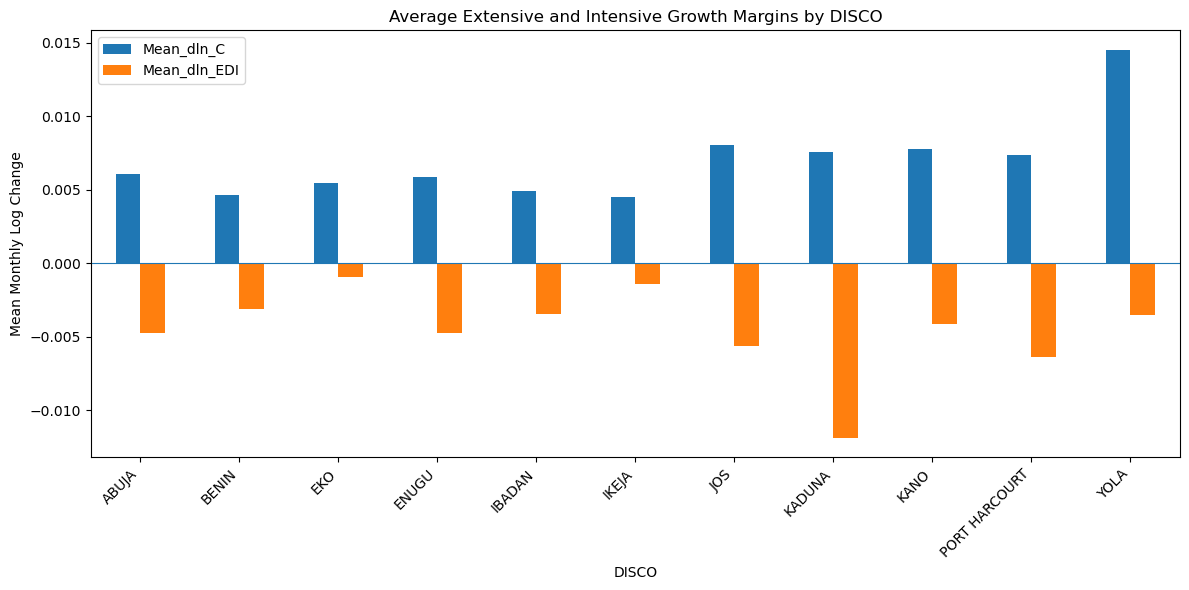

<Figure size 640x480 with 0 Axes>

In [76]:
# FIGURE RQ1.1 — Extensive vs intensive growth margin by DISCO

plot_data = RQ1_SUMMARY.set_index("DISCO")[
    ["Mean_dln_C", "Mean_dln_EDI"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.axhline(0, linewidth=0.8)
ax.set_title(
    "Average Extensive and Intensive Growth Margins by DISCO"
)
ax.set_xlabel("DISCO")
ax.set_ylabel("Mean Monthly Log Change")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.savefig(
    FIGURE_DIR / "RQ1_extensive_intensive_margin.png",
    dpi=300,
    bbox_inches="tight"
)

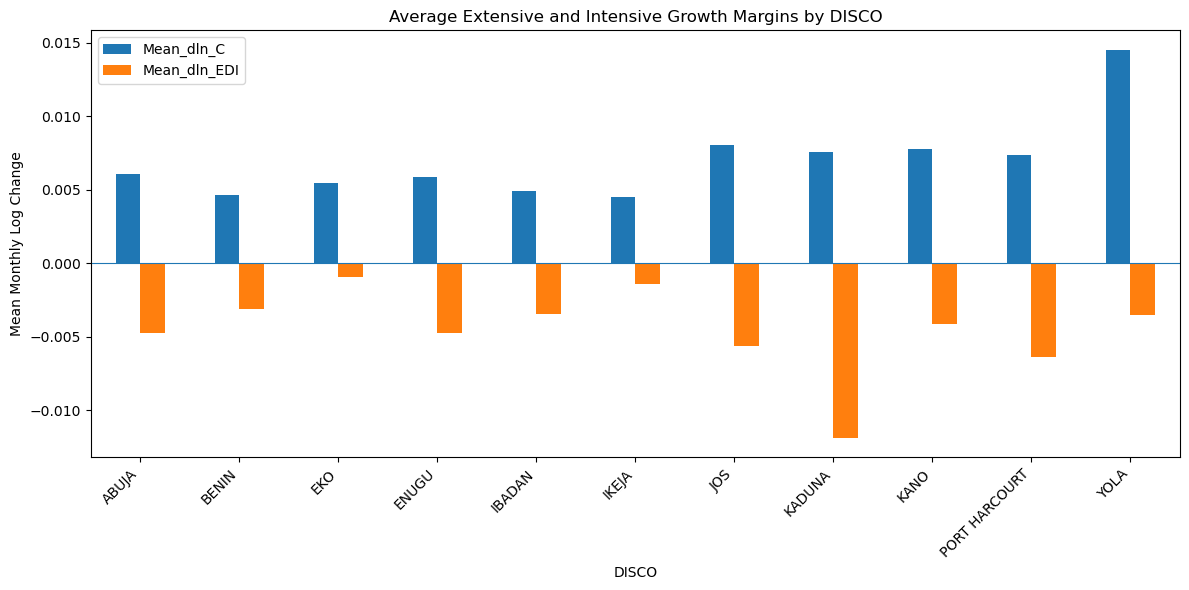

In [77]:
# FIGURE RQ1.1 — Extensive vs intensive growth margin by DISCO

plot_data = RQ1_SUMMARY.set_index("DISCO")[
    ["Mean_dln_C", "Mean_dln_EDI"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.axhline(0, linewidth=0.8)
ax.set_title("Average Extensive and Intensive Growth Margins by DISCO")
ax.set_xlabel("DISCO")
ax.set_ylabel("Mean Monthly Log Change")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ1_extensive_intensive_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
# RQ1.4 — Summarise extensive and intensive margins

RQ1_SUMMARY["Growth_Decomposition_Check"] = (
    RQ1_SUMMARY["Mean_dln_C"]
    + RQ1_SUMMARY["Mean_dln_EDI"]
    - RQ1_SUMMARY["Mean_dln_G"]
)

display(RQ1_SUMMARY)

,DISCO,Mean_dln_G,Mean_dln_C,Mean_dln_EDI,Growth_Decomposition_Check
0,ABUJA,0.001342,0.006086,-0.004743,2.168404e-19
1,BENIN,0.001540,0.004618,-0.003078,-1.626303e-17
2,EKO,0.004577,0.005485,-0.000907,0.000000e+00
3,ENUGU,0.001119,0.005884,-0.004766,8.023096e-18
4,IBADAN,0.001482,0.004941,-0.003459,8.456777e-18
5,IKEJA,0.003148,0.004537,-0.001390,1.647987e-17
6,JOS,0.002480,0.008080,-0.005600,4.336809e-19
7,KADUNA,-0.004323,0.007550,-0.011873,-8.673617e-19
8,KANO,0.003632,0.007747,-0.004116,8.239937e-18
9,PORT HARCOURT,0.000977,0.007340,-0.006363,8.890458e-18


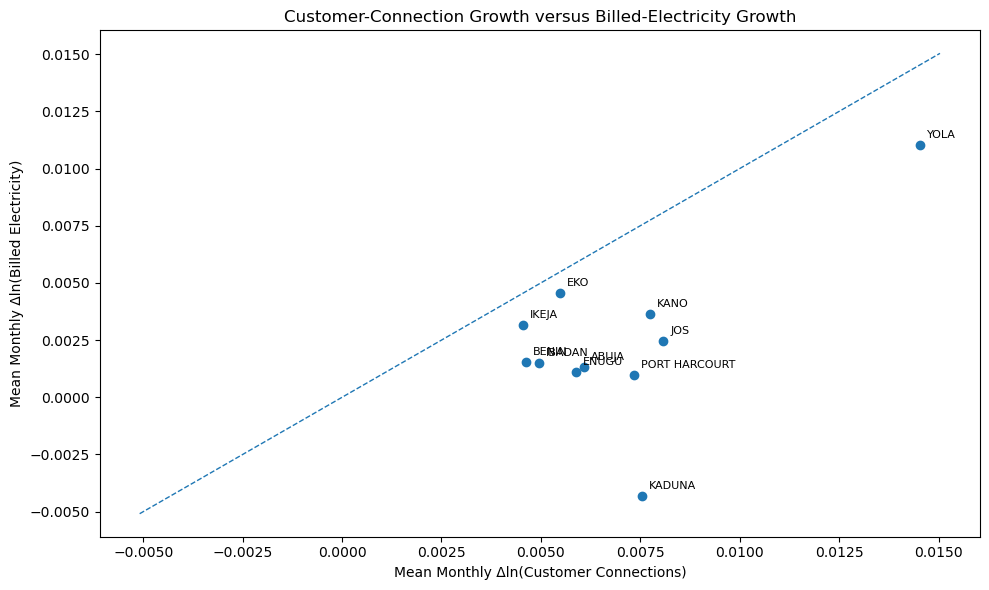

In [79]:
# FIGURE RQ1.2 — Customer growth versus billed-energy growth

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    RQ1_SUMMARY["Mean_dln_C"],
    RQ1_SUMMARY["Mean_dln_G"]
)

for _, row in RQ1_SUMMARY.iterrows():
    ax.annotate(
        row["DISCO"],
        (row["Mean_dln_C"], row["Mean_dln_G"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]

ax.plot(lims, lims, linestyle="--", linewidth=1)

ax.set_title(
    "Customer-Connection Growth versus Billed-Electricity Growth"
)
ax.set_xlabel("Mean Monthly Δln(Customer Connections)")
ax.set_ylabel("Mean Monthly Δln(Billed Electricity)")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ1_customer_vs_energy_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

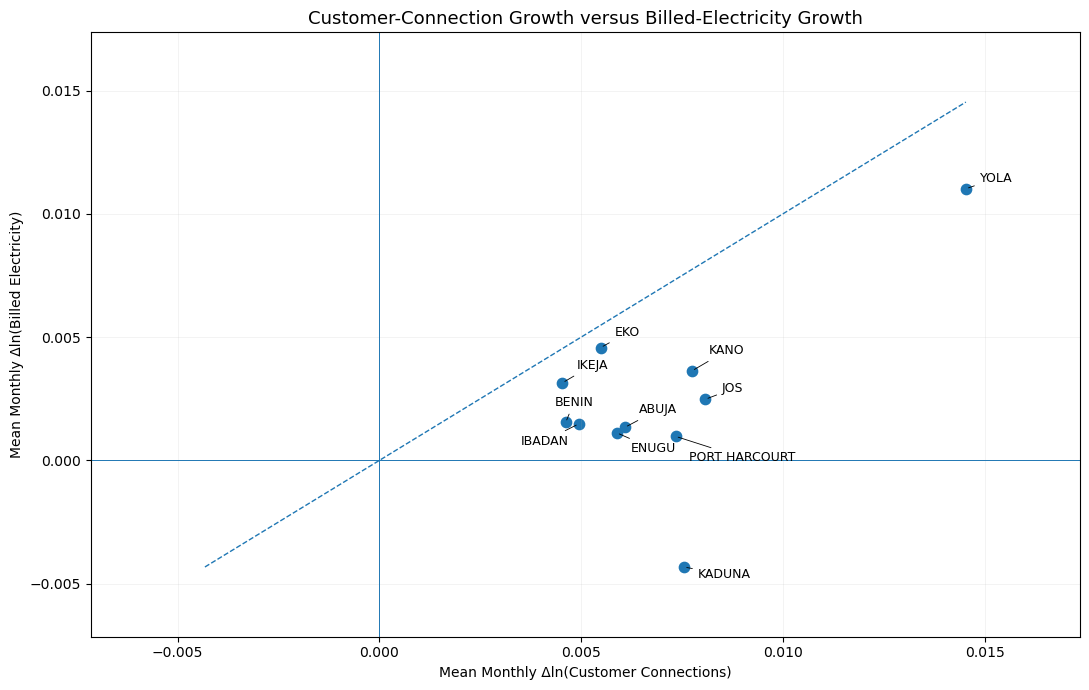

In [80]:
# FIGURE RQ1.2 — Customer growth versus billed-electricity growth

fig, ax = plt.subplots(figsize=(11, 7))

x = RQ1_SUMMARY["Mean_dln_C"]
y = RQ1_SUMMARY["Mean_dln_G"]

ax.scatter(
    x,
    y,
    s=55
)

# Proportional-growth reference line
lower = min(x.min(), y.min())
upper = max(x.max(), y.max())

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1
)

# Deterministic label positions (points)
offsets = {
    "ABUJA": (10, 10),
    "BENIN": (-8, 12),
    "EKO": (10, 8),
    "ENUGU": (10, -14),
    "IBADAN": (-42, -15),
    "IKEJA": (10, 10),
    "JOS": (12, 5),
    "KADUNA": (10, -8),
    "KANO": (12, 12),
    "PORT HARCOURT": (10, -18),
    "YOLA": (10, 5)
}

for _, row in RQ1_SUMMARY.iterrows():

    dx, dy = offsets.get(row["DISCO"], (8, 8))

    ax.annotate(
        row["DISCO"],
        xy=(row["Mean_dln_C"], row["Mean_dln_G"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.6
        )
    )

ax.set_title(
    "Customer-Connection Growth versus Billed-Electricity Growth",
    fontsize=13
)

ax.set_xlabel(
    "Mean Monthly Δln(Customer Connections)",
    fontsize=10
)

ax.set_ylabel(
    "Mean Monthly Δln(Billed Electricity)",
    fontsize=10
)

ax.axhline(0, linewidth=0.7)
ax.axvline(0, linewidth=0.7)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.25
)

ax.margins(0.15)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ1_customer_vs_energy_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
# EXPORT — RQ1 results

with pd.ExcelWriter(
    TABLE_DIR / "RQ1_growth_decomposition.xlsx",
    engine="openpyxl"
) as writer:

    RQ1_SUMMARY.to_excel(
        writer,
        sheet_name="RQ1_Summary",
        index=False
    )

    RQ1_IDENTITY.to_excel(
        writer,
        sheet_name="Identity_Check",
        index=False
    )

print("Saved:", TABLE_DIR / "RQ1_growth_decomposition.xlsx")

Saved: /Users/goldenofforson/outputs/tables/RQ1_growth_decomposition.xlsx


RQ 1 IS COMPLETE 

RQ 2 BEGINS 
RQ2.1 — ADDI distribution by DISCO
RQ2.2 — Negative ADDI classification
RQ2.3 — Negative episode identification
RQ2.4 — Episode duration and persistence
RQ2.5 — DISCO-level decoupling summary
RQ2.6 — Critical ADDI graph
RQ2.7 — RQ2 Excel export

In [82]:
# RQ2.1 — Prepare ADDI dataset

RQ2_PANEL = PANEL_ANALYSIS[
    ["DISCO", "DATE", "dln_G", "dln_C", "dln_EDI", "ADDI"]
].copy()

RQ2_PANEL = RQ2_PANEL.sort_values(
    ["DISCO", "DATE"]
).reset_index(drop=True)

print("RQ2 panel shape:", RQ2_PANEL.shape)
display(RQ2_PANEL.head())

RQ2 panel shape: (1188, 6)


,DISCO,DATE,dln_G,dln_C,dln_EDI,ADDI
0,ABUJA,2015-01-01,NaN,NaN,NaN,NaN
1,ABUJA,2015-02-01,0.016129,0.004730,0.011399,0.011399
2,ABUJA,2015-03-01,-0.024293,0.035921,-0.060214,-0.060214
3,ABUJA,2015-04-01,-0.033336,-0.006190,-0.027146,-0.027146
4,ABUJA,2015-05-01,-0.107246,0.007477,-0.114723,-0.114723


In [83]:
# RQ2.2 — ADDI descriptive statistics by DISCO

ADDI_SUMMARY = (
    RQ2_PANEL
    .groupby("DISCO")["ADDI"]
    .agg(
        Mean_ADDI="mean",
        Median_ADDI="median",
        SD_ADDI="std",
        Minimum_ADDI="min",
        Maximum_ADDI="max"
    )
    .reset_index()
)

display(ADDI_SUMMARY)

,DISCO,Mean_ADDI,Median_ADDI,SD_ADDI,Minimum_ADDI,Maximum_ADDI
0,ABUJA,-0.004743,-0.002924,0.147282,-0.699072,0.714624
1,BENIN,-0.003078,0.013883,0.094755,-0.344048,0.223785
2,EKO,-0.000907,0.001775,0.109121,-0.234695,0.401668
3,ENUGU,-0.004766,-0.013313,0.321378,-2.177908,2.248623
4,IBADAN,-0.003459,0.000011,0.099821,-0.199606,0.277230
5,IKEJA,-0.001390,0.004454,0.103617,-0.383385,0.297837
6,JOS,-0.005600,-0.003365,0.111660,-0.447306,0.259413
7,KADUNA,-0.011873,-0.016174,0.139417,-0.603592,0.308008
8,KANO,-0.004116,0.000441,0.166649,-0.418414,0.733229
9,PORT HARCOURT,-0.006363,-0.005192,0.134439,-0.765312,0.568585


In [84]:
# RQ2.3 — Identify negative ADDI observations

RQ2_PANEL["negative_ADDI"] = RQ2_PANEL["ADDI"] < 0

negative_count = RQ2_PANEL["negative_ADDI"].sum()
valid_count = RQ2_PANEL["ADDI"].notna().sum()

print("Valid ADDI observations:", valid_count)
print("Negative ADDI observations:", negative_count)
print(
    "Share negative:",
    negative_count / valid_count
)

Valid ADDI observations: 1177
Negative ADDI observations: 603
Share negative: 0.5123194562446899


In [85]:
# RQ2.4 — Identify consecutive negative ADDI episodes

RQ2_PANEL["episode_break"] = (
    ~RQ2_PANEL["negative_ADDI"]
    .eq(RQ2_PANEL.groupby("DISCO")["negative_ADDI"].shift())
)

RQ2_PANEL["episode_id"] = (
    RQ2_PANEL.groupby("DISCO")["episode_break"]
    .cumsum()
)

negative_episodes = (
    RQ2_PANEL[RQ2_PANEL["negative_ADDI"]]
    .groupby(["DISCO", "episode_id"])
    .agg(
        Start_Date=("DATE", "min"),
        End_Date=("DATE", "max"),
        Duration_Months=("DATE", "size"),
        Mean_ADDI=("ADDI", "mean"),
        Minimum_ADDI=("ADDI", "min")
    )
    .reset_index()
)

print("Negative ADDI episodes:", len(negative_episodes))
display(negative_episodes.head(10))

Negative ADDI episodes: 311


,DISCO,episode_id,Start_Date,End_Date,Duration_Months,Mean_ADDI,Minimum_ADDI
0,ABUJA,2,2015-03-01,2015-06-01,4,-0.127398,-0.307510
1,ABUJA,4,2015-08-01,2015-08-01,1,-0.040819,-0.040819
2,ABUJA,6,2015-12-01,2015-12-01,1,-0.050896,-0.050896
3,ABUJA,8,2016-02-01,2016-08-01,7,-0.124997,-0.285019
4,ABUJA,10,2017-01-01,2017-01-01,1,-0.019366,-0.019366
5,ABUJA,12,2017-05-01,2017-06-01,2,-0.040497,-0.059731
6,ABUJA,14,2017-09-01,2017-10-01,2,-0.031406,-0.045530
7,ABUJA,16,2018-01-01,2018-02-01,2,-0.043898,-0.087334
8,ABUJA,18,2018-06-01,2018-07-01,2,-0.095119,-0.100872
9,ABUJA,20,2018-10-01,2018-10-01,1,-0.699072,-0.699072


In [86]:
# RQ2.5 — Summarise negative ADDI persistence

ADDI_PERSISTENCE = (
    negative_episodes
    .groupby("DISCO")
    .agg(
        Negative_Episodes=("Duration_Months", "size"),
        Mean_Episode_Duration=("Duration_Months", "mean"),
        Median_Episode_Duration=("Duration_Months", "median"),
        Maximum_Episode_Duration=("Duration_Months", "max")
    )
    .reset_index()
)

display(ADDI_PERSISTENCE)

,DISCO,Negative_Episodes,Mean_Episode_Duration,Median_Episode_Duration,Maximum_Episode_Duration
0,ABUJA,27,2.037037,2.0,7
1,BENIN,32,1.406250,1.0,3
2,EKO,28,1.892857,1.0,7
3,ENUGU,26,2.346154,1.5,7
4,IBADAN,27,1.962963,2.0,6
5,IKEJA,31,1.677419,1.0,6
6,JOS,27,2.000000,2.0,6
7,KADUNA,25,2.560000,2.0,6
8,KANO,26,2.038462,2.0,5
9,PORT HARCOURT,32,1.812500,1.0,6


In [87]:
# RQ2.5B — Overall negative episode persistence

print(
    "Total negative episodes:",
    len(negative_episodes)
)

print(
    "Mean episode duration:",
    negative_episodes["Duration_Months"].mean()
)

print(
    "Maximum episode duration:",
    negative_episodes["Duration_Months"].max()
)

Total negative episodes: 311
Mean episode duration: 1.9389067524115755
Maximum episode duration: 7


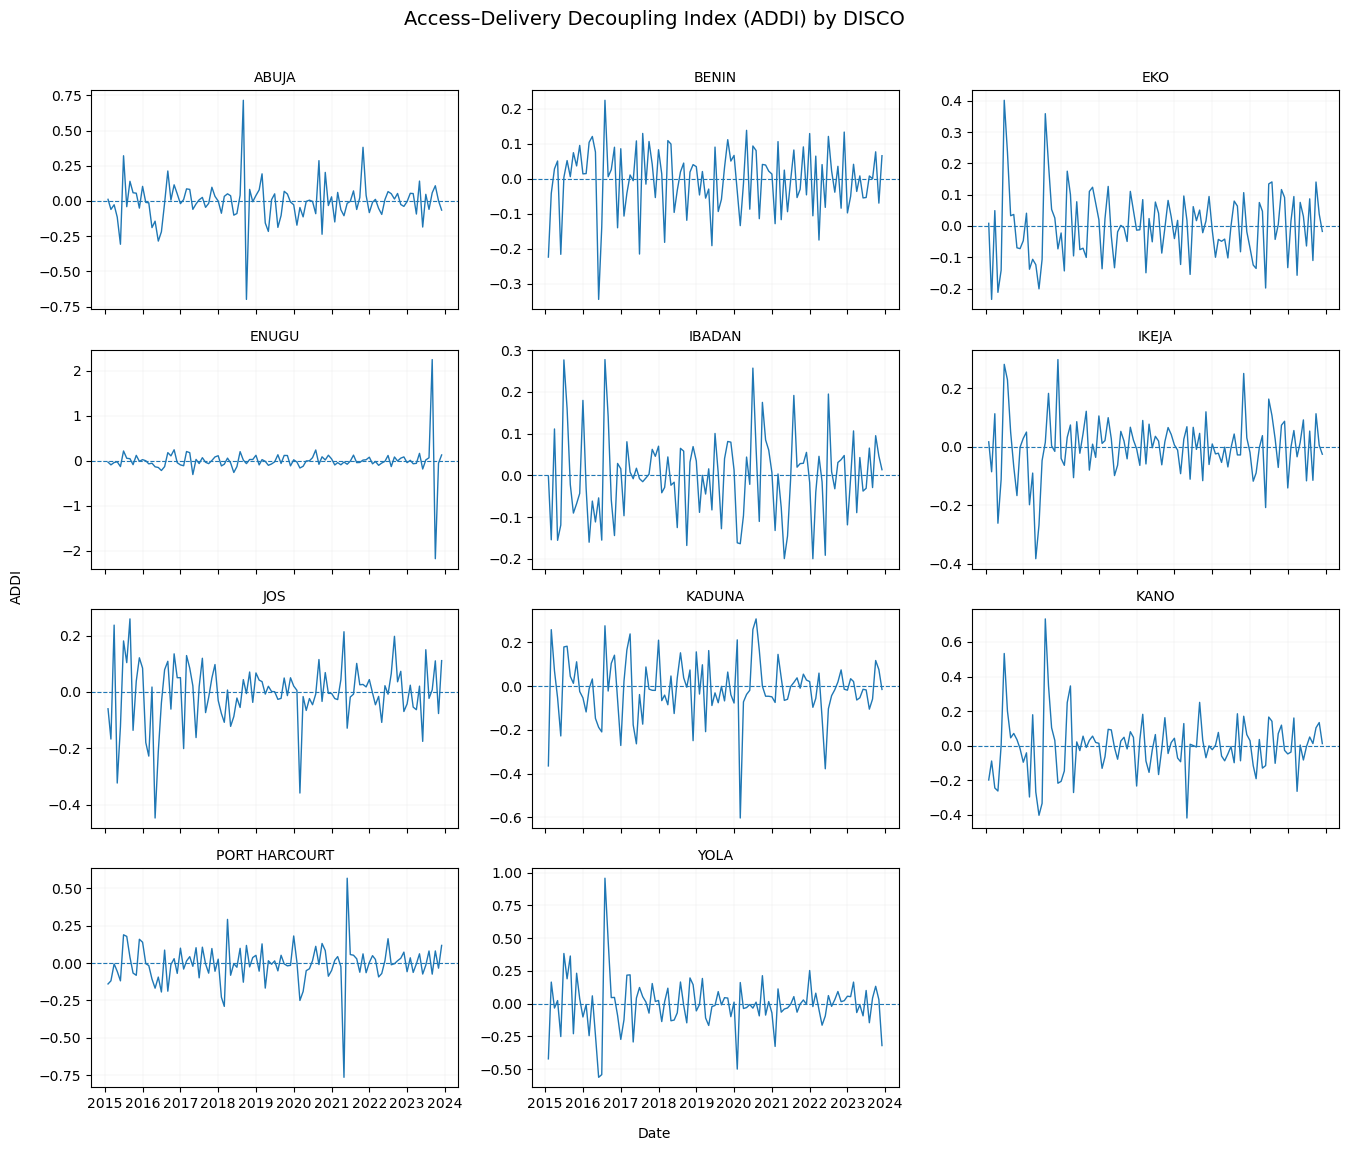

In [88]:
# FIGURE RQ2.1 — ADDI trajectories by DISCO

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(14, 12),
    sharex=True
)

axes = axes.flatten()

discos = RQ2_PANEL["DISCO"].unique()

for ax, disco in zip(axes, discos):

    temp = RQ2_PANEL[RQ2_PANEL["DISCO"] == disco]

    ax.plot(
        temp["DATE"],
        temp["ADDI"],
        linewidth=1
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(disco, fontsize=10)
    ax.grid(True, linewidth=0.3, alpha=0.25)

# Remove unused axis
for ax in axes[len(discos):]:
    ax.remove()

fig.suptitle(
    "Access–Delivery Decoupling Index (ADDI) by DISCO",
    fontsize=14
)

fig.text(
    0.5,
    0.04,
    "Date",
    ha="center"
)

fig.text(
    0.04,
    0.5,
    "ADDI",
    va="center",
    rotation="vertical"
)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])

plt.savefig(
    FIGURE_DIR / "RQ2_ADDI_trajectories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
# RQ2.7 — Final DISCO-level decoupling summary

ADDI_FINAL_SUMMARY = (
    ADDI_SUMMARY
    .merge(
        ADDI_PERSISTENCE,
        on="DISCO",
        how="left"
    )
)

ADDI_FINAL_SUMMARY["Negative_Share"] = (
    RQ2_PANEL.groupby("DISCO")["negative_ADDI"]
    .mean()
    .values
)

display(ADDI_FINAL_SUMMARY)

,DISCO,Mean_ADDI,Median_ADDI,SD_ADDI,Minimum_ADDI,Maximum_ADDI,Negative_Episodes,Mean_Episode_Duration,Median_Episode_Duration,Maximum_Episode_Duration,Negative_Share
0,ABUJA,-0.004743,-0.002924,0.147282,-0.699072,0.714624,27,2.037037,2.0,7,0.509259
1,BENIN,-0.003078,0.013883,0.094755,-0.344048,0.223785,32,1.406250,1.0,3,0.416667
2,EKO,-0.000907,0.001775,0.109121,-0.234695,0.401668,28,1.892857,1.0,7,0.490741
3,ENUGU,-0.004766,-0.013313,0.321378,-2.177908,2.248623,26,2.346154,1.5,7,0.564815
4,IBADAN,-0.003459,0.000011,0.099821,-0.199606,0.277230,27,1.962963,2.0,6,0.490741
5,IKEJA,-0.001390,0.004454,0.103617,-0.383385,0.297837,31,1.677419,1.0,6,0.481481
6,JOS,-0.005600,-0.003365,0.111660,-0.447306,0.259413,27,2.000000,2.0,6,0.500000
7,KADUNA,-0.011873,-0.016174,0.139417,-0.603592,0.308008,25,2.560000,2.0,6,0.592593
8,KANO,-0.004116,0.000441,0.166649,-0.418414,0.733229,26,2.038462,2.0,5,0.490741
9,PORT HARCOURT,-0.006363,-0.005192,0.134439,-0.765312,0.568585,32,1.812500,1.0,6,0.537037


In [90]:
# EXPORT — RQ2 results

with pd.ExcelWriter(
    TABLE_DIR / "RQ2_ADDI_results.xlsx",
    engine="openpyxl"
) as writer:

    ADDI_FINAL_SUMMARY.to_excel(
        writer,
        sheet_name="ADDI_Summary",
        index=False
    )

    negative_episodes.to_excel(
        writer,
        sheet_name="Negative_Episodes",
        index=False
    )

    RQ2_PANEL.to_excel(
        writer,
        sheet_name="ADDI_Panel",
        index=False
    )

print("Saved:", TABLE_DIR / "RQ2_ADDI_results.xlsx")

Saved: /Users/goldenofforson/outputs/tables/RQ2_ADDI_results.xlsx


R2 DONE 

R3 BEGINS 
RQ3_SAMPLE_GATE
RQ3_CROSS_SECTIONAL_DEPENDENCE
RQ3_CIPS
RQ3_FE_BENCHMARK
RQ3_DYNAMIC_CCE_MG
RQ3_DISCO_COEFFICIENTS
RQ3_RESIDUAL_CD
RQ3_LJUNG_BOX
RQ3_FINAL_EXPORT

In [91]:
# RQ3.1 — Create validated RQ3 working panel

RQ3_PANEL = PANEL_ANALYSIS[
    ["DISCO", "DATE", "ln_EDI", "MR", "d_MR"]
].copy()

RQ3_PANEL = RQ3_PANEL.sort_values(
    ["DISCO", "DATE"]
).reset_index(drop=True)

print("RQ3 panel shape:", RQ3_PANEL.shape)
display(RQ3_PANEL.head())

RQ3 panel shape: (1188, 5)


,DISCO,DATE,ln_EDI,MR,d_MR
0,ABUJA,2015-01-01,-8.012584,0.480803,NaN
1,ABUJA,2015-02-01,-8.001185,0.474404,-0.006398
2,ABUJA,2015-03-01,-8.061399,0.490591,0.016187
3,ABUJA,2015-04-01,-8.088545,0.498679,0.008088
4,ABUJA,2015-05-01,-8.203268,0.504818,0.006139


In [92]:
# RQ3.2 — Construct lagged delivery intensity

RQ3_PANEL["ln_EDI_lag1"] = (
    RQ3_PANEL.groupby("DISCO")["ln_EDI"]
    .shift(1)
)

print(
    "Missing d_MR:",
    RQ3_PANEL["d_MR"].isna().sum()
)

print(
    "Missing ln_EDI_lag1:",
    RQ3_PANEL["ln_EDI_lag1"].isna().sum()
)

Missing d_MR: 11
Missing ln_EDI_lag1: 11


In [93]:
# RQ3.3 — Pesaran CD test for ln_EDI

def pesaran_cd(data, value_col):
    wide = data.pivot(
        index="DATE",
        columns="DISCO",
        values=value_col
    ).dropna()

    corr = wide.corr()
    n = corr.shape[0]
    t = wide.shape[0]

    off_diag = corr.values[
        np.triu_indices(n, k=1)
    ]

    cd_stat = np.sqrt(
        (2 * t) / (n * (n - 1))
    ) * off_diag.sum()

    return cd_stat, t, n

cd_edi, T_cd, N_cd = pesaran_cd(
    RQ3_PANEL,
    "ln_EDI"
)

print("Pesaran CD — ln_EDI")
print("CD statistic:", cd_edi)
print("T:", T_cd)
print("N:", N_cd)

Pesaran CD — ln_EDI
CD statistic: 32.39163757575744
T: 108
N: 11


In [94]:
# RQ3.4 — Pesaran CD test for d_MR

cd_dmr, _, _ = pesaran_cd(
    RQ3_PANEL.dropna(subset=["d_MR"]),
    "d_MR"
)

print("Pesaran CD — d_MR")
print("CD statistic:", cd_dmr)

Pesaran CD — d_MR
CD statistic: -0.6457202259584607


In [95]:
# RQ3.5A — CIPS/CADF estimation function

import statsmodels.api as sm
from statsmodels.tsa.tsatools import lagmat

def cadf_by_disco(data, variable, max_lag=4):
    results = []
    work = data[["DISCO", "DATE", variable]].copy()
    
    # Cross-sectional mean
    work["CS_MEAN"] = work.groupby("DATE")[variable].transform("mean")
    
    for disco in work["DISCO"].unique():
        d = (
            work[work["DISCO"] == disco]
            .sort_values("DATE")
            .copy()
        )
        
        y = d[variable].astype(float)
        cs = d["CS_MEAN"].astype(float)
        
        best = None
        
        for lag in range(max_lag + 1):
            tmp = pd.DataFrame({
                "y": y,
                "cs": cs
            })
            
            tmp["y_lag1"] = y.shift(1)
            tmp["cs_lag1"] = cs.shift(1)
            tmp["dy"] = y.diff()
            
            for j in range(1, lag + 1):
                tmp[f"dy_lag{j}"] = y.diff().shift(j)
            
            for j in range(0, lag + 1):
                tmp[f"dcs_lag{j}"] = cs.diff().shift(j)
            
            tmp = tmp.dropna()
            
            if len(tmp) < 20:
                continue
            
            xcols = [
                "y_lag1",
                "cs_lag1"
            ]
            
            xcols += [
                f"dy_lag{j}"
                for j in range(1, lag + 1)
            ]
            
            xcols += [
                f"dcs_lag{j}"
                for j in range(0, lag + 1)
            ]
            
            X = sm.add_constant(tmp[xcols])
            model = sm.OLS(tmp["dy"], X).fit()
            
            candidate = {
                "DISCO": disco,
                "Selected_Lag": lag,
                "CADF_Statistic": model.tvalues["y_lag1"],
                "Coefficient": model.params["y_lag1"],
                "AIC": model.aic,
                "BIC": model.bic,
                "N_Obs": len(tmp)
            }
            
            if best is None or candidate["AIC"] < best["AIC"]:
                best = candidate
        
        results.append(best)
    
    return pd.DataFrame(results)

In [96]:
# RQ3.5B — CIPS for ln_EDI

EDI_CADF = cadf_by_disco(
    RQ3_PANEL,
    "ln_EDI",
    max_lag=4
)

CIPS_EDI = EDI_CADF["CADF_Statistic"].mean()

print("CIPS statistic — ln_EDI:", CIPS_EDI)

display(EDI_CADF)

CIPS statistic — ln_EDI: -3.6500448031402413


,DISCO,Selected_Lag,CADF_Statistic,Coefficient,AIC,BIC,N_Obs
0,ABUJA,1,-3.396366,-0.274719,-168.078139,-152.097504,106
1,BENIN,1,-1.968539,-0.136578,-241.388612,-225.407977,106
2,EKO,0,-4.093623,-0.230467,-259.179351,-248.488036,107
3,ENUGU,0,-7.948847,-0.762621,-3.993846,6.697469,107
4,IBADAN,0,-4.354475,-0.317342,-267.231451,-256.540136,107
5,IKEJA,1,-2.156054,-0.086022,-228.173226,-212.192592,106
6,JOS,3,-1.901999,-0.092865,-209.585756,-183.141847,104
7,KADUNA,0,-2.192104,-0.094597,-156.558263,-145.866948,107
8,KANO,0,-4.532779,-0.302546,-180.381557,-169.690242,107
9,PORT HARCOURT,1,-3.852502,-0.273646,-157.280169,-141.299535,106


In [97]:
# RQ3.5C — CIPS for MR

MR_CADF = cadf_by_disco(
    RQ3_PANEL,
    "MR",
    max_lag=4
)

CIPS_MR = MR_CADF["CADF_Statistic"].mean()

print("CIPS statistic — MR:", CIPS_MR)

display(MR_CADF)

CIPS statistic — MR: -1.8897806306656881


,DISCO,Selected_Lag,CADF_Statistic,Coefficient,AIC,BIC,N_Obs
0,ABUJA,4,-1.786446,-0.161363,-302.389560,-270.772812,103
1,BENIN,0,-2.305574,-0.090824,-505.372757,-494.681442,107
2,EKO,1,0.496110,0.009031,-807.227521,-791.246887,106
3,ENUGU,2,-2.339810,-0.119966,-494.643816,-473.412133,105
4,IBADAN,0,-1.876638,-0.056169,-675.730457,-665.039142,107
5,IKEJA,3,-0.798329,-0.019505,-458.018612,-431.574703,104
6,JOS,2,-3.509396,-0.129096,-614.310495,-593.078812,105
7,KADUNA,4,-0.073314,-0.002902,-289.030297,-257.413549,103
8,KANO,0,-5.003776,-0.287816,-564.865183,-554.173868,107
9,PORT HARCOURT,1,-1.607436,-0.080362,-387.790230,-371.809596,106


In [99]:
# RQ3.5D — CIPS for d_MR

DMR_CADF = cadf_by_disco(
    RQ3_PANEL.dropna(subset=["d_MR"]),
    "d_MR",
    max_lag=4
)

CIPS_DMR = DMR_CADF["CADF_Statistic"].mean()

print("CIPS statistic — d_MR:", CIPS_DMR)

display(DMR_CADF)

CIPS statistic — d_MR: -8.930721040853866


,DISCO,Selected_Lag,CADF_Statistic,Coefficient,AIC,BIC,N_Obs
0,ABUJA,3,-7.959753,-2.500827,-302.839146,-276.491856,103
1,BENIN,1,-10.705361,-1.451919,-503.112966,-487.189204,105
2,EKO,0,-8.324071,-0.760891,-810.866469,-800.212713,106
3,ENUGU,1,-9.597424,-1.271805,-492.777461,-476.853699,105
4,IBADAN,0,-9.250100,-0.912597,-665.291221,-654.637465,106
5,IKEJA,2,-8.989102,-1.635245,-456.781527,-435.626400,104
6,JOS,1,-6.470226,-0.767384,-605.752816,-589.829054,105
7,KADUNA,4,-4.813806,-1.726106,-294.018331,-262.518657,102
8,KANO,1,-8.856377,-1.159542,-541.536339,-525.612577,105
9,PORT HARCOURT,0,-15.279362,-1.390319,-388.243024,-377.589268,106


In [100]:
# RQ3.6 — Summarise CIPS integration decisions

CIPS_SUMMARY = pd.DataFrame({
    "Variable": ["ln_EDI", "MR", "d_MR"],
    "CIPS_Statistic": [CIPS_EDI, CIPS_MR, CIPS_DMR],
    "CV_5pct": [-2.32, -2.32, -2.32]
})

CIPS_SUMMARY["Reject_H0_5pct"] = (
    CIPS_SUMMARY["CIPS_Statistic"]
    < CIPS_SUMMARY["CV_5pct"]
)

CIPS_SUMMARY["Integration_Decision"] = np.where(
    CIPS_SUMMARY["Reject_H0_5pct"],
    "I(0)",
    "Nonstationary in levels"
)

display(CIPS_SUMMARY)

,Variable,CIPS_Statistic,CV_5pct,Reject_H0_5pct,Integration_Decision
0,ln_EDI,-3.650045,-2.32,True,I(0)
1,MR,-1.889781,-2.32,False,Nonstationary in levels
2,d_MR,-8.930721,-2.32,True,I(0)


In [101]:
# RQ3.6 — Summarise CIPS integration decisions

CIPS_SUMMARY = pd.DataFrame({
    "Variable": ["ln_EDI", "MR", "d_MR"],
    "CIPS_Statistic": [CIPS_EDI, CIPS_MR, CIPS_DMR],
    "CV_5pct": [-2.32, -2.32, -2.32]
})

CIPS_SUMMARY["Reject_H0_5pct"] = (
    CIPS_SUMMARY["CIPS_Statistic"]
    < CIPS_SUMMARY["CV_5pct"]
)

CIPS_SUMMARY["Integration_Decision"] = np.where(
    CIPS_SUMMARY["Reject_H0_5pct"],
    "I(0)",
    "Nonstationary in levels"
)

display(CIPS_SUMMARY)

,Variable,CIPS_Statistic,CV_5pct,Reject_H0_5pct,Integration_Decision
0,ln_EDI,-3.650045,-2.32,True,I(0)
1,MR,-1.889781,-2.32,False,Nonstationary in levels
2,d_MR,-8.930721,-2.32,True,I(0)


In [103]:
# RQ3.7 — DISCO Fixed-effects benchmarks
import statsmodels.formula.api as smf

FE_DATA = RQ3_PANEL[
    ["DISCO", "DATE", "ln_EDI", "d_MR"]
].dropna().copy()

fe_model = smf.ols(
    "ln_EDI ~ d_MR + C(DISCO)",
    data=FE_DATA
).fit(cov_type="HC1")

FE_RESULTS = pd.DataFrame({
    "Variable": ["d_MR"],
    "Coefficient": [fe_model.params["d_MR"]],
    "SE_HC1": [fe_model.bse["d_MR"]],
    "p_value": [fe_model.pvalues["d_MR"]],
    "CI_Lower_95": [fe_model.conf_int().loc["d_MR", 0]],
    "CI_Upper_95": [fe_model.conf_int().loc["d_MR", 1]]
})

display(FE_RESULTS.round(6))

,Variable,Coefficient,SE_HC1,p_value,CI_Lower_95,CI_Upper_95
0,d_MR,0.356476,0.291457,0.221299,-0.21477,0.927722


In [104]:
# RQ3.7B — FE benchmark summary

print("FE benchmark sample:", len(FE_DATA))
print("DISCOs:", FE_DATA["DISCO"].nunique())

display(FE_RESULTS.round(6))

FE benchmark sample: 1177
DISCOs: 11


,Variable,Coefficient,SE_HC1,p_value,CI_Lower_95,CI_Upper_95
0,d_MR,0.356476,0.291457,0.221299,-0.21477,0.927722


In [105]:
# RQ3.8 — Construct current and lagged cross-sectional averages

CCE_PANEL = RQ3_PANEL.copy()

# Cross-sectional averages at each month
CCE_PANEL["CSA_ln_EDI"] = (
    CCE_PANEL.groupby("DATE")["ln_EDI"]
    .transform("mean")
)

CCE_PANEL["CSA_d_MR"] = (
    CCE_PANEL.groupby("DATE")["d_MR"]
    .transform("mean")
)

# Four lags of each cross-sectional average
for lag in range(1, 5):
    CCE_PANEL[f"CSA_ln_EDI_lag{lag}"] = (
        CCE_PANEL.groupby("DISCO")["CSA_ln_EDI"]
        .shift(lag)
    )
    
    CCE_PANEL[f"CSA_d_MR_lag{lag}"] = (
        CCE_PANEL.groupby("DISCO")["CSA_d_MR"]
        .shift(lag)
    )

print("CCE panel shape:", CCE_PANEL.shape)

display(
    CCE_PANEL[
        [
            "DISCO", "DATE",
            "ln_EDI", "ln_EDI_lag1",
            "d_MR",
            "CSA_ln_EDI",
            "CSA_ln_EDI_lag1",
            "CSA_ln_EDI_lag2",
            "CSA_ln_EDI_lag3",
            "CSA_ln_EDI_lag4",
            "CSA_d_MR",
            "CSA_d_MR_lag1",
            "CSA_d_MR_lag2",
            "CSA_d_MR_lag3",
            "CSA_d_MR_lag4"
        ]
    ].head(10)
)

CCE panel shape: (1188, 16)


,DISCO,DATE,ln_EDI,ln_EDI_lag1,d_MR,CSA_ln_EDI,CSA_ln_EDI_lag1,CSA_ln_EDI_lag2,CSA_ln_EDI_lag3,CSA_ln_EDI_lag4,CSA_d_MR,CSA_d_MR_lag1,CSA_d_MR_lag2,CSA_d_MR_lag3,CSA_d_MR_lag4
0,ABUJA,2015-01-01,-8.012584,NaN,NaN,-8.187375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABUJA,2015-02-01,-8.001185,-8.012584,-0.006398,-8.315007,-8.187375,NaN,NaN,NaN,-0.025866,NaN,NaN,NaN,NaN
2,ABUJA,2015-03-01,-8.061399,-8.001185,0.016187,-8.371344,-8.315007,-8.187375,NaN,NaN,0.027606,-0.025866,NaN,NaN,NaN
3,ABUJA,2015-04-01,-8.088545,-8.061399,0.008088,-8.347805,-8.371344,-8.315007,-8.187375,NaN,0.018126,0.027606,-0.025866,NaN,NaN
4,ABUJA,2015-05-01,-8.203268,-8.088545,0.006139,-8.474023,-8.347805,-8.371344,-8.315007,-8.187375,-0.005725,0.018126,0.027606,-0.025866,NaN
5,ABUJA,2015-06-01,-8.510778,-8.203268,0.000386,-8.632778,-8.474023,-8.347805,-8.371344,-8.315007,0.013547,-0.005725,0.018126,0.027606,-0.025866
6,ABUJA,2015-07-01,-8.189932,-8.510778,-0.040780,-8.362971,-8.632778,-8.474023,-8.347805,-8.371344,-0.002782,0.013547,-0.005725,0.018126,0.027606
7,ABUJA,2015-08-01,-8.230750,-8.189932,0.001110,-8.222398,-8.362971,-8.632778,-8.474023,-8.347805,-0.004737,-0.002782,0.013547,-0.005725,0.018126
8,ABUJA,2015-09-01,-8.091261,-8.230750,0.007482,-8.131123,-8.222398,-8.362971,-8.632778,-8.474023,-0.001081,-0.004737,-0.002782,0.013547,-0.005725
9,ABUJA,2015-10-01,-8.033115,-8.091261,-0.018317,-8.169733,-8.131123,-8.222398,-8.362971,-8.632778,-0.005703,-0.001081,-0.004737,-0.002782,0.013547


In [106]:
# RQ3.9 — Validate final CCE regressor structure

cce_vars = [
    "ln_EDI",
    "ln_EDI_lag1",
    "d_MR",
    "CSA_ln_EDI",
    "CSA_ln_EDI_lag1",
    "CSA_ln_EDI_lag2",
    "CSA_ln_EDI_lag3",
    "CSA_ln_EDI_lag4",
    "CSA_d_MR",
    "CSA_d_MR_lag1",
    "CSA_d_MR_lag2",
    "CSA_d_MR_lag3",
    "CSA_d_MR_lag4"
]

print("Missing values used by CCE specification:")
display(CCE_PANEL[cce_vars].isna().sum().to_frame("missing"))

Missing values used by CCE specification:


,missing
ln_EDI,0
ln_EDI_lag1,11
d_MR,11
CSA_ln_EDI,0
CSA_ln_EDI_lag1,11
CSA_ln_EDI_lag2,22
CSA_ln_EDI_lag3,33
CSA_ln_EDI_lag4,44
CSA_d_MR,11
CSA_d_MR_lag1,22


In [107]:
# RQ3.10 — Prepare complete cases for the final CCE-MG model

CCE_VARS = [
    "ln_EDI",
    "ln_EDI_lag1",
    "d_MR",
    "CSA_ln_EDI",
    "CSA_ln_EDI_lag1",
    "CSA_ln_EDI_lag2",
    "CSA_ln_EDI_lag3",
    "CSA_ln_EDI_lag4",
    "CSA_d_MR",
    "CSA_d_MR_lag1",
    "CSA_d_MR_lag2",
    "CSA_d_MR_lag3",
    "CSA_d_MR_lag4"
]

CCE_ESTIMATION_PANEL = (
    CCE_PANEL[
        ["DISCO", "DATE"] + CCE_VARS
    ]
    .dropna()
    .sort_values(["DISCO", "DATE"])
    .reset_index(drop=True)
)

print("CCE estimation sample:", CCE_ESTIMATION_PANEL.shape)

print("\nObservations per DISCO:")
display(
    CCE_ESTIMATION_PANEL
    .groupby("DISCO")
    .size()
    .to_frame("N")
)

CCE estimation sample: (1133, 15)

Observations per DISCO:


,N
DISCO,
ABUJA,103
BENIN,103
EKO,103
ENUGU,103
IBADAN,103
IKEJA,103
JOS,103
KADUNA,103
KANO,103


In [108]:
# RQ3.11 — Estimate DISCO-specific lag-augmented CCE models

disco_results = []
residual_results = []

x_vars = [
    "d_MR",
    "CSA_ln_EDI",
    "CSA_ln_EDI_lag1",
    "CSA_ln_EDI_lag2",
    "CSA_ln_EDI_lag3",
    "CSA_ln_EDI_lag4",
    "CSA_d_MR",
    "CSA_d_MR_lag1",
    "CSA_d_MR_lag2",
    "CSA_d_MR_lag3",
    "CSA_d_MR_lag4"
]

for disco, data_i in CCE_ESTIMATION_PANEL.groupby("DISCO"):

    y = data_i["ln_EDI"].astype(float)

    X = data_i[
        ["ln_EDI_lag1"] + x_vars
    ].astype(float)

    X = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, X).fit(cov_type="HC1")

    disco_results.append({
        "DISCO": disco,
        "N": int(model.nobs),
        "rho_ln_EDI_lag1": model.params["ln_EDI_lag1"],
        "beta_d_MR": model.params["d_MR"],
        "SE_rho": model.bse["ln_EDI_lag1"],
        "SE_beta": model.bse["d_MR"],
        "p_rho": model.pvalues["ln_EDI_lag1"],
        "p_beta": model.pvalues["d_MR"],
        "R2": model.rsquared
    })

    residual_results.append(
        data_i[
            ["DISCO", "DATE"]
        ].assign(
            DCCE_LAGGED_RESIDUAL=model.resid.values
        )
    )

RQ3_DCCE_LAGGED_DISCO = pd.DataFrame(disco_results)

RQ3_DCCE_LAGGED_RESIDUALS = pd.concat(
    residual_results,
    ignore_index=True
)

display(
    RQ3_DCCE_LAGGED_DISCO[
        [
            "DISCO", "N",
            "rho_ln_EDI_lag1",
            "beta_d_MR",
            "SE_beta",
            "p_beta",
            "R2"
        ]
    ].round(6)
)

,DISCO,N,rho_ln_EDI_lag1,beta_d_MR,SE_beta,p_beta,R2
0,ABUJA,103,0.826925,1.008558,0.139889,0.000000,0.918527
1,BENIN,103,0.782177,0.581744,0.421293,0.167324,0.703466
2,EKO,103,0.709723,0.290906,1.325104,0.826234,0.837182
3,ENUGU,103,0.211109,0.542078,0.522462,0.299482,0.439232
4,IBADAN,103,0.749464,1.644918,0.696104,0.018126,0.877293
5,IKEJA,103,0.893264,0.460741,0.369595,0.212541,0.870409
6,JOS,103,0.892434,0.969640,0.504907,0.054803,0.912809
7,KADUNA,103,0.920659,0.243400,0.118388,0.039787,0.934528
8,KANO,103,0.614999,0.452011,0.552672,0.413434,0.872270
9,PORT HARCOURT,103,0.834249,2.017378,0.346908,0.000000,0.924849


In [109]:
# RQ3.12 — Calculate Mean Group effect

beta = RQ3_DCCE_LAGGED_DISCO["beta_d_MR"]

mg_beta = beta.mean()
mg_sd = beta.std(ddof=1)
mg_se = mg_sd / np.sqrt(len(beta))
mg_t = mg_beta / mg_se

from scipy.stats import t

mg_p = 2 * t.sf(
    np.abs(mg_t),
    df=len(beta) - 1
)

mg_ci_low = (
    mg_beta -
    t.ppf(0.975, len(beta) - 1) * mg_se
)

mg_ci_high = (
    mg_beta +
    t.ppf(0.975, len(beta) - 1) * mg_se
)

RQ3_CCE_MG_RESULTS = pd.DataFrame({
    "Statistic": [
        "Mean beta",
        "SD beta",
        "SE beta",
        "t statistic",
        "p value",
        "CI lower 95%",
        "CI upper 95%"
    ],
    "Value": [
        mg_beta,
        mg_sd,
        mg_se,
        mg_t,
        mg_p,
        mg_ci_low,
        mg_ci_high
    ]
})

display(RQ3_CCE_MG_RESULTS.round(6))

,Statistic,Value
0,Mean beta,0.704622
1,SD beta,0.683840
2,SE beta,0.206186
3,t statistic,3.417418
4,p value,0.006576
5,CI lower 95%,0.245212
6,CI upper 95%,1.164032


In [110]:
# RQ3.13 — Final RQ3 association summary

RQ3_FINAL_SUMMARY = pd.DataFrame({
    "Statistic": [
        "CCE-MG mean beta",
        "CCE-MG SE",
        "CCE-MG p-value",
        "CCE-MG CI lower 95%",
        "CCE-MG CI upper 95%",
        "Mean rho",
        "Beta minimum",
        "Beta maximum",
        "Beta SD",
        "Positive DISCOs",
        "Negative DISCOs",
        "Significant beta_i (5%)"
    ],
    "Value": [
        mg_beta,
        mg_se,
        mg_p,
        mg_ci_low,
        mg_ci_high,
        RQ3_DCCE_LAGGED_DISCO["rho_ln_EDI_lag1"].mean(),
        beta.min(),
        beta.max(),
        beta.std(ddof=1),
        (beta > 0).sum(),
        (beta < 0).sum(),
        (RQ3_DCCE_LAGGED_DISCO["p_beta"] < 0.05).sum()
    ]
})

display(RQ3_FINAL_SUMMARY.round(6))

,Statistic,Value
0,CCE-MG mean beta,0.704622
1,CCE-MG SE,0.206186
2,CCE-MG p-value,0.006576
3,CCE-MG CI lower 95%,0.245212
4,CCE-MG CI upper 95%,1.164032
5,Mean rho,0.742875
6,Beta minimum,-0.460530
7,Beta maximum,2.017378
8,Beta SD,0.683840
9,Positive DISCOs,10.000000


In [111]:
# RQ3.14 — Residual cross-sectional dependence

resid_wide = (
    RQ3_DCCE_LAGGED_RESIDUALS
    .pivot(
        index="DATE",
        columns="DISCO",
        values="DCCE_LAGGED_RESIDUAL"
    )
    .dropna()
)

N_resid = resid_wide.shape[1]
T_resid = resid_wide.shape[0]

corr_resid = resid_wide.corr()

upper = corr_resid.values[
    np.triu_indices(N_resid, k=1)
]

residual_cd = (
    np.sqrt(
        (2 * T_resid) /
        (N_resid * (N_resid - 1))
    )
    * upper.sum()
)

mean_abs_corr = np.mean(np.abs(upper))
max_abs_corr = np.max(np.abs(upper))

print("Residual observations:", T_resid)
print("Residual DISCOs:", N_resid)
print("Pesaran CD:", residual_cd)
print("Mean absolute residual correlation:", mean_abs_corr)
print("Maximum absolute residual correlation:", max_abs_corr)

Residual observations: 103
Residual DISCOs: 11
Pesaran CD: -2.994971396427371
Mean absolute residual correlation: 0.14502327995468728
Maximum absolute residual correlation: 0.4902350990492663


In [112]:
# RQ3.15 — Residual correlation matrix

RQ3_RESIDUAL_CORR = corr_resid.copy()

display(
    RQ3_RESIDUAL_CORR.round(3)
)

DISCO,ABUJA,BENIN,EKO,ENUGU,IBADAN,IKEJA,JOS,KADUNA,KANO,PORT HARCOURT,YOLA
DISCO,,,,,,,,,,,
ABUJA,1.000,-0.109,0.013,-0.188,-0.160,0.093,0.049,-0.162,0.064,-0.068,0.107
BENIN,-0.109,1.000,0.055,-0.136,0.181,-0.079,-0.259,-0.028,-0.094,0.297,-0.048
EKO,0.013,0.055,1.000,-0.490,0.408,0.453,-0.062,0.064,0.284,-0.049,-0.003
ENUGU,-0.188,-0.136,-0.490,1.000,-0.279,-0.369,-0.118,-0.222,-0.460,-0.142,-0.361
IBADAN,-0.160,0.181,0.408,-0.279,1.000,0.223,-0.134,0.031,-0.085,0.016,-0.023
IKEJA,0.093,-0.079,0.453,-0.369,0.223,1.000,0.117,0.006,0.005,-0.113,-0.084
JOS,0.049,-0.259,-0.062,-0.118,-0.134,0.117,1.000,0.074,-0.012,0.020,-0.105
KADUNA,-0.162,-0.028,0.064,-0.222,0.031,0.006,0.074,1.000,-0.025,-0.039,-0.220
KANO,0.064,-0.094,0.284,-0.460,-0.085,0.005,-0.012,-0.025,1.000,-0.161,0.333


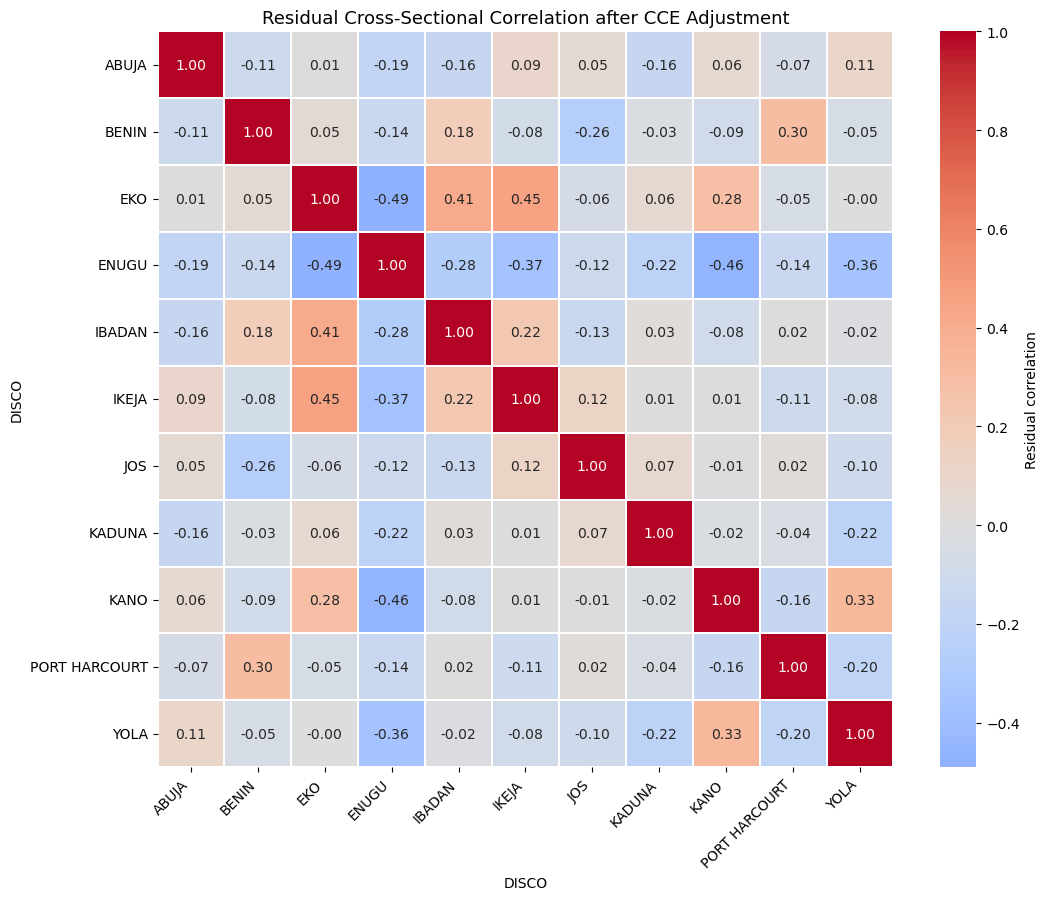

In [113]:
# RQ3.15 — Residual cross-sectional correlation heat map

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 9))

sns.heatmap(
    RQ3_RESIDUAL_CORR,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Residual correlation"}
)

plt.title(
    "Residual Cross-Sectional Correlation after CCE Adjustment",
    fontsize=13
)

plt.xlabel("DISCO")
plt.ylabel("DISCO")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ3_residual_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
# RQ3.16 — Ljung–Box residual serial-correlation test

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_results = []

for disco, g in RQ3_DCCE_LAGGED_RESIDUALS.groupby("DISCO"):

    residual = g.sort_values("DATE")["DCCE_LAGGED_RESIDUAL"].dropna()

    lb = acorr_ljungbox(
        residual,
        lags=[12],
        return_df=True
    )

    q12 = lb["lb_stat"].iloc[0]
    p12 = lb["lb_pvalue"].iloc[0]

    lb_results.append({
        "DISCO": disco,
        "N_Residuals": len(residual),
        "Ljung_Box_Q12": q12,
        "Ljung_Box_p12": p12,
        "Serial_Correlation_5pct": p12 < 0.05
    })

RQ3_LB_RESULTS = pd.DataFrame(lb_results)

display(
    RQ3_LB_RESULTS.round(6)
)

,DISCO,N_Residuals,Ljung_Box_Q12,Ljung_Box_p12,Serial_Correlation_5pct
0,ABUJA,103,20.480385,0.058527,False
1,BENIN,103,18.603777,0.098550,False
2,EKO,103,8.108913,0.776562,False
3,ENUGU,103,4.505882,0.972485,False
4,IBADAN,103,12.595884,0.399084,False
5,IKEJA,103,8.632397,0.733966,False
6,JOS,103,11.836800,0.458874,False
7,KADUNA,103,5.861990,0.922878,False
8,KANO,103,7.330237,0.835041,False
9,PORT HARCOURT,103,12.450715,0.410194,False


In [115]:
# RQ3.17 — Final diagnostics summary

RQ3_DIAGNOSTICS = pd.DataFrame({
    "Statistic": [
        "Residual CD statistic",
        "Residual CD p-value",
        "Mean absolute residual correlation",
        "Maximum absolute residual correlation",
        "DISCOs with significant Ljung–Box Q12",
        "Total DISCOs tested"
    ],
    "Value": [
        residual_cd,
        2 * (1 - t.cdf(abs(residual_cd), df=T_resid - 1)),
        mean_abs_corr,
        max_abs_corr,
        RQ3_LB_RESULTS["Serial_Correlation_5pct"].sum(),
        len(RQ3_LB_RESULTS)
    ]
})

display(
    RQ3_DIAGNOSTICS.round(6)
)

,Statistic,Value
0,Residual CD statistic,-2.994971
1,Residual CD p-value,0.003445
2,Mean absolute residual correlation,0.145023
3,Maximum absolute residual correlation,0.490235
4,DISCOs with significant Ljung–Box Q12,0.000000
5,Total DISCOs tested,11.000000


In [116]:
# RQ3.18 — Final RQ3 results table

RQ3_RESULTS_FINAL = pd.DataFrame({
    "Variable": ["d_MR"],
    "Mean_CCE_MG_Coefficient": [mg_beta],
    "SE": [mg_se],
    "t_statistic": [mg_t],
    "p_value": [mg_p],
    "CI_Lower_95": [mg_ci_low],
    "CI_Upper_95": [mg_ci_high]
})

display(
    RQ3_RESULTS_FINAL.round(6)
)

,Variable,Mean_CCE_MG_Coefficient,SE,t_statistic,p_value,CI_Lower_95,CI_Upper_95
0,d_MR,0.704622,0.206186,3.417418,0.006576,0.245212,1.164032


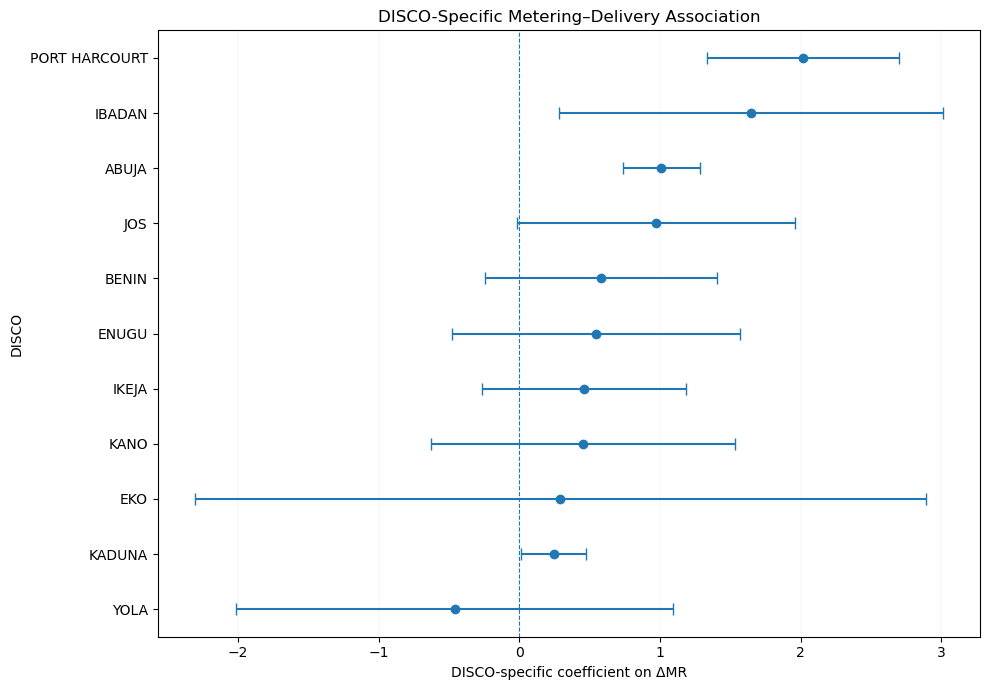

In [117]:
# FIGURE RQ3.1 — DISCO-specific metering coefficients

plot_df = (
    RQ3_DCCE_LAGGED_DISCO
    .sort_values("beta_d_MR")
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(plot_df))

ax.errorbar(
    plot_df["beta_d_MR"],
    y_pos,
    xerr=1.96 * plot_df["SE_beta"],
    fmt="o",
    capsize=4
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["DISCO"])

ax.set_xlabel(
    "DISCO-specific coefficient on ΔMR"
)

ax.set_ylabel("DISCO")

ax.set_title(
    "DISCO-Specific Metering–Delivery Association"
)

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ3_DISCO_specific_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

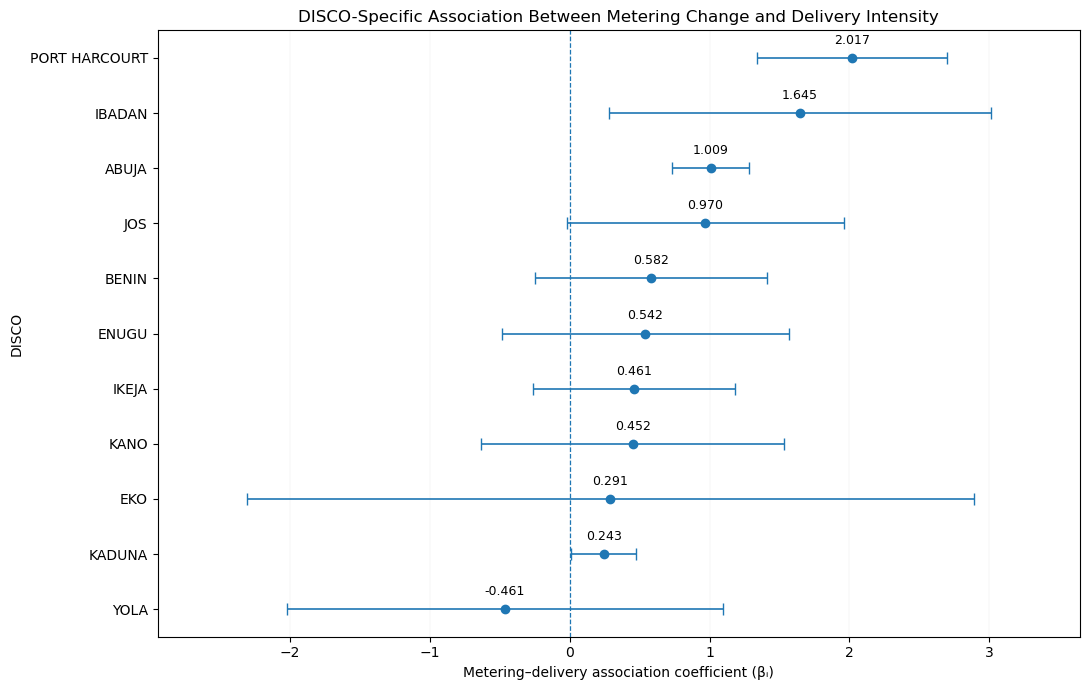

In [120]:
# FIGURE RQ3.1 — DISCO-specific metering–delivery coefficients with estimates

# FIGURE RQ3.1 — DISCO-specific metering–delivery coefficients

plot_df = (
    RQ3_DCCE_LAGGED_DISCO
    .sort_values("beta_d_MR")
    .copy()
)

plot_df["CI_Lower_95"] = (
    plot_df["beta_d_MR"] - 1.96 * plot_df["SE_beta"]
)

plot_df["CI_Upper_95"] = (
    plot_df["beta_d_MR"] + 1.96 * plot_df["SE_beta"]
)

fig, ax = plt.subplots(figsize=(11, 7))

y_pos = np.arange(len(plot_df))

ax.errorbar(
    plot_df["beta_d_MR"],
    y_pos,
    xerr=[
        plot_df["beta_d_MR"] - plot_df["CI_Lower_95"],
        plot_df["CI_Upper_95"] - plot_df["beta_d_MR"]
    ],
    fmt="o",
    capsize=4,
    linewidth=1.2
)

# Zero-association reference line
ax.axvline(
    0,
    linestyle="--",
    linewidth=0.9
)

# Coefficient labels ABOVE each point
for y, (_, row) in zip(y_pos, plot_df.iterrows()):
    ax.annotate(
        f"{row['beta_d_MR']:.3f}",
        xy=(row["beta_d_MR"], y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["DISCO"])

ax.set_xlabel(
    "Metering–delivery association coefficient (βᵢ)"
)

ax.set_ylabel("DISCO")

ax.set_title(
    "DISCO-Specific Association Between Metering Change and Delivery Intensity"
)

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

ax.margins(x=0.12)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ3_DISCO_specific_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

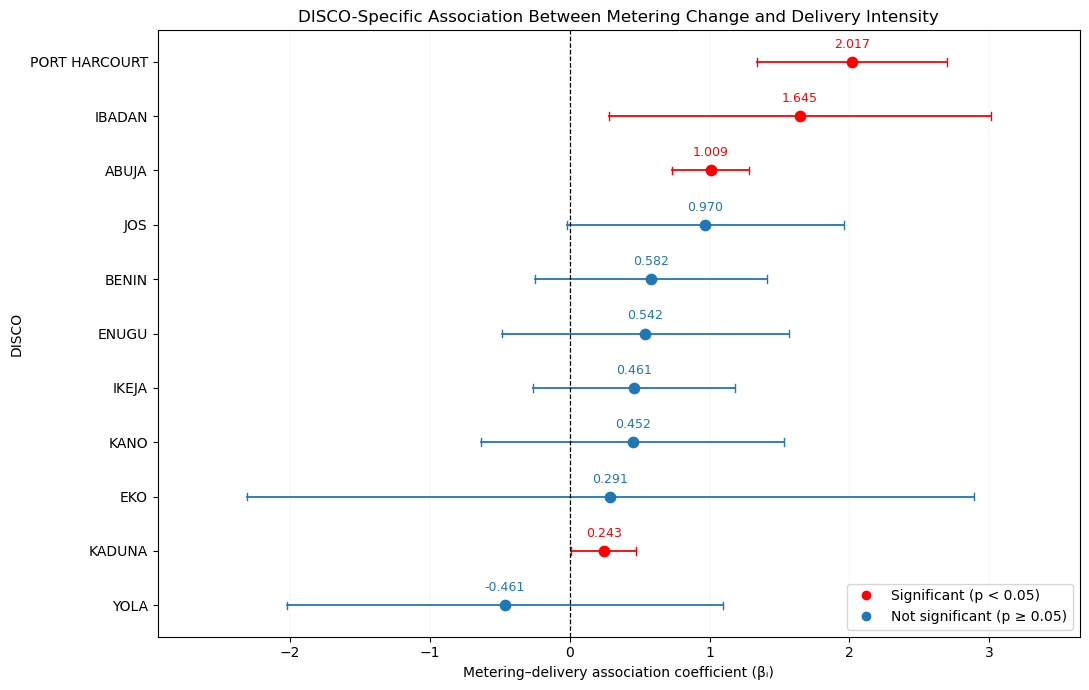

In [177]:
# FIGURE RQ3.1 — DISCO-specific metering–delivery coefficients
# Significant coefficients (p < 0.05) shown in red

# FIGURE RQ3.1 — DISCO-specific metering–delivery coefficients
# Red = significant at 5%; Blue = not significant

plot_df = (
    RQ3_DCCE_LAGGED_DISCO
    .sort_values("beta_d_MR")
    .reset_index(drop=True)
    .copy()
)

# 95% confidence intervals
plot_df["CI_Lower_95"] = (
    plot_df["beta_d_MR"] - 1.96 * plot_df["SE_beta"]
)

plot_df["CI_Upper_95"] = (
    plot_df["beta_d_MR"] + 1.96 * plot_df["SE_beta"]
)

# Significance
plot_df["Significant_5pct"] = (
    plot_df["p_beta"] < 0.05
)

fig, ax = plt.subplots(figsize=(11, 7))

y_pos = np.arange(len(plot_df))

for y, (_, row) in zip(y_pos, plot_df.iterrows()):

    beta = float(row["beta_d_MR"])
    ci_low = float(row["CI_Lower_95"])
    ci_high = float(row["CI_Upper_95"])
    significant = bool(row["Significant_5pct"])

    point_color = "red" if significant else "tab:blue"

    # Confidence interval
    ax.plot(
        [ci_low, ci_high],
        [y, y],
        color=point_color,
        linewidth=1.3
    )

    # CI caps
    ax.plot(
        [ci_low, ci_low],
        [y - 0.07, y + 0.07],
        color=point_color,
        linewidth=1.0
    )

    ax.plot(
        [ci_high, ci_high],
        [y - 0.07, y + 0.07],
        color=point_color,
        linewidth=1.0
    )

    # Point estimate
    ax.scatter(
        beta,
        y,
        color=point_color,
        s=55,
        zorder=3
    )

    # Numerical coefficient above point
    ax.annotate(
        f"{beta:.3f}",
        xy=(beta, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color=point_color
    )

# Zero-association reference
ax.axvline(
    0,
    linestyle="--",
    linewidth=0.9,
    color="black"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["DISCO"])

ax.set_xlabel(
    "Metering–delivery association coefficient (βᵢ)"
)

ax.set_ylabel("DISCO")

ax.set_title(
    "DISCO-Specific Association Between Metering Change and Delivery Intensity"
)

# Significance legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color="red",
        markersize=6,
        label="Significant (p < 0.05)"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color="tab:blue",
        markersize=6,
        label="Not significant (p ≥ 0.05)"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right"
)

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

ax.margins(x=0.12)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ3_DISCO_specific_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [121]:
# EXPORT — Complete RQ3 results

with pd.ExcelWriter(
    TABLE_DIR / "RQ3_Final_Results.xlsx",
    engine="openpyxl"
) as writer:

    CIPS_SUMMARY.to_excel(
        writer,
        sheet_name="CIPS_Summary",
        index=False
    )

    FE_RESULTS.to_excel(
        writer,
        sheet_name="FE_Benchmark",
        index=False
    )

    RQ3_RESULTS_FINAL.to_excel(
        writer,
        sheet_name="CCE_MG_Summary",
        index=False
    )

    RQ3_DCCE_LAGGED_DISCO.to_excel(
        writer,
        sheet_name="DISCO_Coefficients",
        index=False
    )

    RQ3_DIAGNOSTICS.to_excel(
        writer,
        sheet_name="Diagnostics",
        index=False
    )

    RQ3_LB_RESULTS.to_excel(
        writer,
        sheet_name="Ljung_Box",
        index=False
    )

    RQ3_RESIDUAL_CORR.to_excel(
        writer,
        sheet_name="Residual_Correlation"
    )

print(
    "Saved:",
    TABLE_DIR / "RQ3_Final_Results.xlsx"
)

Saved: /Users/goldenofforson/outputs/tables/RQ3_Final_Results.xlsx


RQ3 DONE

RQ4 — HETEROGENEITY AND REGIMES
RQ4_FEATURE_MATRIX
RQ4_STANDARDISATION
RQ4_K_SELECTION
RQ4_FINAL_REGIMES
RQ4_SUMMARY_EXPORT

In [122]:
# RQ4.1 — Build DISCO regime feature matrix

RQ4_FEATURES = (
    ADDI_FINAL_SUMMARY[
        ["DISCO", "Mean_ADDI", "Mean_Episode_Duration"]
    ]
    .rename(columns={
        "Mean_Episode_Duration": "ADDI_Persistence"
    })
    .merge(
        RQ3_DCCE_LAGGED_DISCO[
            ["DISCO", "beta_d_MR"]
        ],
        on="DISCO",
        how="inner"
    )
)

MR_MEAN = (
    PANEL_ANALYSIS
    .groupby("DISCO")["MR"]
    .mean()
    .rename("Mean_MR")
    .reset_index()
)

EDI_MEAN = (
    PANEL_ANALYSIS
    .groupby("DISCO")["EDI"]
    .mean()
    .rename("Mean_EDI")
    .reset_index()
)

RQ4_FEATURES = (
    MR_MEAN
    .merge(EDI_MEAN, on="DISCO")
    .merge(RQ4_FEATURES, on="DISCO")
)

RQ4_FEATURES = RQ4_FEATURES[
    [
        "DISCO",
        "Mean_MR",
        "Mean_EDI",
        "Mean_ADDI",
        "ADDI_Persistence",
        "beta_d_MR"
    ]
]

display(RQ4_FEATURES.round(6))

,DISCO,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
0,ABUJA,0.507716,0.000223,-0.004743,2.037037,1.008558
1,BENIN,0.568494,0.000172,-0.003078,1.406250,0.581744
2,EKO,0.539077,0.000448,-0.000907,1.892857,0.290906
3,ENUGU,0.438066,0.000157,-0.004766,2.346154,0.542078
4,IBADAN,0.374625,0.000124,-0.003459,1.962963,1.644918
5,IKEJA,0.560693,0.000296,-0.001390,1.677419,0.460741
6,JOS,0.297206,0.000159,-0.005600,2.000000,0.969640
7,KADUNA,0.347467,0.000217,-0.011873,2.560000,0.243400
8,KANO,0.262169,0.000211,-0.004116,2.038462,0.452011
9,PORT HARCOURT,0.528162,0.000254,-0.006363,1.812500,2.017378


In [123]:
# RQ4.2 — Validate regime feature matrix

feature_cols = [
    "Mean_MR",
    "Mean_EDI",
    "Mean_ADDI",
    "ADDI_Persistence",
    "beta_d_MR"
]

print("DISCOs:", RQ4_FEATURES["DISCO"].nunique())
print("Missing values:", RQ4_FEATURES[feature_cols].isna().sum().sum())
print("Constant features:", RQ4_FEATURES[feature_cols].nunique() == 1)

display(RQ4_FEATURES[feature_cols].describe().round(6))

DISCOs: 11
Missing values: 0
Constant features: Mean_MR             False
Mean_EDI            False
Mean_ADDI           False
ADDI_Persistence    False
beta_d_MR           False
dtype: bool


,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
count,11.000000,11.000000,11.000000,11.000000,11.000000
mean,0.419595,0.000217,-0.004528,1.960634,0.704622
std,0.132324,0.000094,0.002932,0.308482,0.683840
min,0.191865,0.000122,-0.011873,1.406250,-0.460530
25%,0.322336,0.000158,-0.005183,1.822917,0.371459
50%,0.438066,0.000211,-0.004116,1.962963,0.542078
75%,0.533619,0.000238,-0.003268,2.037749,0.989099
max,0.568494,0.000448,-0.000907,2.560000,2.017378


In [124]:
# RQ4.3 — Standardise regime features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

RQ4_FEATURES_STD = RQ4_FEATURES.copy()

RQ4_FEATURES_STD[feature_cols] = scaler.fit_transform(
    RQ4_FEATURES[feature_cols]
)

display(
    RQ4_FEATURES_STD[
        ["DISCO"] + feature_cols
    ].round(3)
)

,DISCO,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
0,ABUJA,0.698,0.068,-0.077,0.260,0.466
1,BENIN,1.180,-0.500,0.519,-1.885,-0.188
2,EKO,0.947,2.592,1.295,-0.230,-0.635
3,ENUGU,0.146,-0.669,-0.085,1.311,-0.249
4,IBADAN,-0.356,-1.038,0.383,0.008,1.442
5,IKEJA,1.118,0.885,1.123,-0.963,-0.374
6,JOS,-0.970,-0.640,-0.383,0.134,0.406
7,KADUNA,-0.572,0.007,-2.627,2.038,-0.707
8,KANO,-1.248,-0.061,0.148,0.265,-0.387
9,PORT HARCOURT,0.861,0.418,-0.656,-0.504,2.013


In [125]:
# RQ4.4 — Compare candidate K values

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

X = RQ4_FEATURES_STD[feature_cols].to_numpy()

cluster_comparison = []

for k in [2, 3, 4]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = km.fit_predict(X)

    counts = pd.Series(labels).value_counts().sort_index()

    cluster_comparison.append({
        "K": k,
        "Silhouette": silhouette_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Minimum_Cluster_Size": counts.min(),
        "Maximum_Cluster_Size": counts.max()
    })

RQ4_K_COMPARISON = pd.DataFrame(cluster_comparison)

display(
    RQ4_K_COMPARISON.round(4)
)

,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Minimum_Cluster_Size,Maximum_Cluster_Size
0,2,0.2328,4.8622,1.2662,5,6
1,3,0.1912,4.4282,1.0783,3,5
2,4,0.2043,4.9125,0.8408,1,4


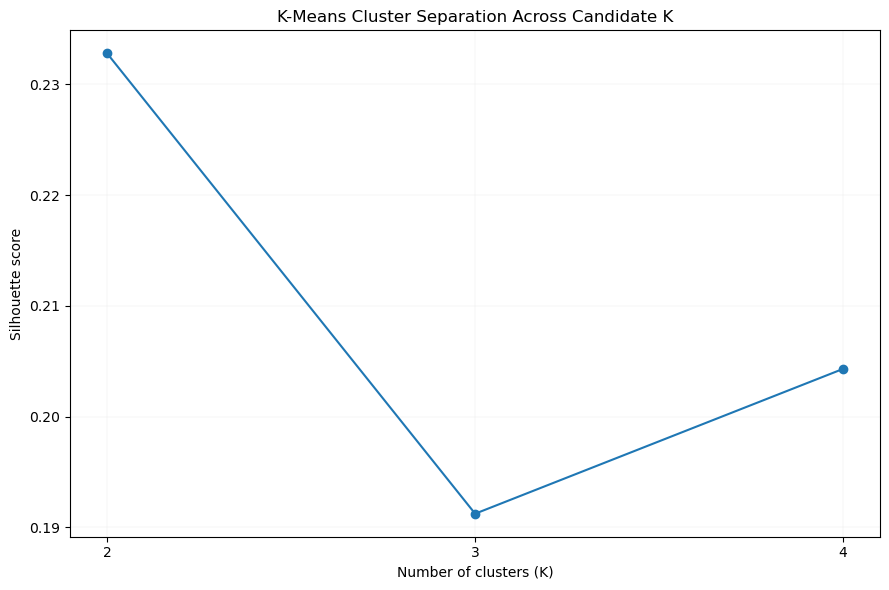

In [126]:
# FIGURE RQ4.1 — Cluster separation diagnostics

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    RQ4_K_COMPARISON["K"],
    RQ4_K_COMPARISON["Silhouette"],
    marker="o",
    label="Silhouette"
)

ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Silhouette score")
ax.set_title("K-Means Cluster Separation Across Candidate K")
ax.set_xticks([2, 3, 4])
ax.grid(True, linewidth=0.3, alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ4_K_selection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [127]:
# RQ4.6 — Final K = 3 clustering

final_k = 3

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=50
)

RQ4_FEATURES_STD["Regime_ID"] = (
    kmeans_final.fit_predict(X)
)

RQ4_FEATURES_STD = RQ4_FEATURES_STD.sort_values(
    "Regime_ID"
).reset_index(drop=True)

display(
    RQ4_FEATURES_STD[
        ["DISCO", "Regime_ID"] + feature_cols
    ].round(3)
)

,DISCO,Regime_ID,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
0,ENUGU,0,0.146,-0.669,-0.085,1.311,-0.249
1,JOS,0,-0.970,-0.640,-0.383,0.134,0.406
2,KADUNA,0,-0.572,0.007,-2.627,2.038,-0.707
3,KANO,0,-1.248,-0.061,0.148,0.265,-0.387
4,YOLA,0,-1.805,-1.063,0.362,-0.433,-1.787
5,BENIN,1,1.180,-0.500,0.519,-1.885,-0.188
6,EKO,1,0.947,2.592,1.295,-0.230,-0.635
7,IKEJA,1,1.118,0.885,1.123,-0.963,-0.374
8,ABUJA,2,0.698,0.068,-0.077,0.260,0.466
9,IBADAN,2,-0.356,-1.038,0.383,0.008,1.442


In [128]:
# RQ4.7 — Regime composition and size

RQ4_REGIME_COMPOSITION = (
    RQ4_FEATURES_STD
    .groupby("Regime_ID")
    .agg(
        N_DISCOs=("DISCO", "size"),
        DISCOs=("DISCO", lambda x: ", ".join(x))
    )
    .reset_index()
)

display(RQ4_REGIME_COMPOSITION)

,Regime_ID,N_DISCOs,DISCOs
0,0,5,"ENUGU, JOS, KADUNA, KANO, YOLA"
1,1,3,"BENIN, EKO, IKEJA"
2,2,3,"ABUJA, IBADAN, PORT HARCOURT"


In [129]:
# RQ4.8 — Regime centroids in standardised feature space

RQ4_CENTROIDS = (
    RQ4_FEATURES_STD
    .groupby("Regime_ID")[feature_cols]
    .mean()
    .reset_index()
)

display(
    RQ4_CENTROIDS.round(3)
)

,Regime_ID,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
0,0,-0.890,-0.485,-0.517,0.663,-0.545
1,1,1.082,0.992,0.979,-1.026,-0.399
2,2,0.401,-0.184,-0.117,-0.079,1.307


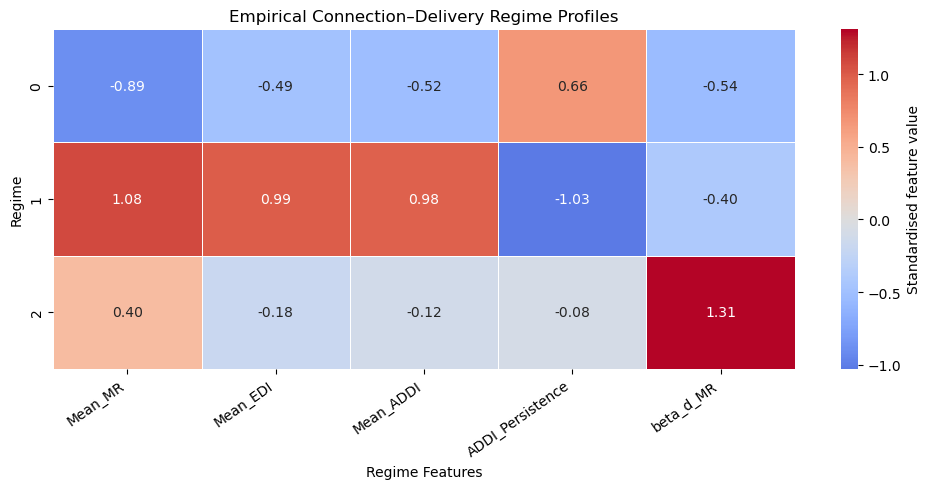

In [130]:
# FIGURE RQ4.2 — Standardised regime profiles

plt.figure(figsize=(10, 5))

heatmap_data = (
    RQ4_CENTROIDS
    .set_index("Regime_ID")
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.4,
    cbar_kws={"label": "Standardised feature value"}
)

plt.title(
    "Empirical Connection–Delivery Regime Profiles"
)

plt.xlabel("Regime Features")
plt.ylabel("Regime")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ4_regime_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
# RQ4.10 — Final regime summary

RQ4_REGIME_SUMMARY = (
    RQ4_FEATURES_STD
    .groupby("Regime_ID")
    .agg(
        N_DISCOs=("DISCO", "size"),
        Mean_MR=("Mean_MR", "mean"),
        Mean_EDI=("Mean_EDI", "mean"),
        Mean_ADDI=("Mean_ADDI", "mean"),
        ADDI_Persistence=("ADDI_Persistence", "mean"),
        Mean_beta=("beta_d_MR", "mean"),
        DISCOs=("DISCO", lambda x: ", ".join(x))
    )
    .reset_index()
)

display(
    RQ4_REGIME_SUMMARY.round(6)
)

,Regime_ID,N_DISCOs,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,Mean_beta,DISCOs
0,0,5,-0.889621,-0.485021,-0.517222,0.662831,-0.544929,"ENUGU, JOS, KADUNA, KANO, YOLA"
1,1,3,1.081856,0.992169,0.978932,-1.026064,-0.399007,"BENIN, EKO, IKEJA"
2,2,3,0.400845,-0.183801,-0.116896,-0.078654,1.307221,"ABUJA, IBADAN, PORT HARCOURT"


In [132]:
# RQ4.11 — Correct regime summary using raw, unstandardised features

REGIME_LABELS = RQ4_FEATURES_STD[
    ["DISCO", "Regime_ID"]
].copy()

RQ4_REGIME_SUMMARY = (
    RQ4_FEATURES
    .merge(REGIME_LABELS, on="DISCO", how="left")
    .groupby("Regime_ID")
    .agg(
        N_DISCOs=("DISCO", "size"),
        Mean_MR=("Mean_MR", "mean"),
        Mean_EDI=("Mean_EDI", "mean"),
        Mean_ADDI=("Mean_ADDI", "mean"),
        ADDI_Persistence=("ADDI_Persistence", "mean"),
        Mean_beta=("beta_d_MR", "mean"),
        DISCOs=("DISCO", lambda x: ", ".join(x))
    )
    .reset_index()
)

display(RQ4_REGIME_SUMMARY.round(6))

,Regime_ID,N_DISCOs,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,Mean_beta,DISCOs
0,0,5,0.307355,0.000173,-0.005974,2.155590,0.349320,"ENUGU, JOS, KADUNA, KANO, YOLA"
1,1,3,0.556088,0.000305,-0.001792,1.658842,0.444463,"BENIN, EKO, IKEJA"
2,2,3,0.470168,0.000200,-0.004855,1.937500,1.556951,"ABUJA, IBADAN, PORT HARCOURT"


In [133]:
# RQ4.12 — Inspect fresh cluster membership

RQ4_ASSIGNMENT = (
    RQ4_FEATURES
    .merge(
        REGIME_LABELS,
        on="DISCO",
        how="left"
    )
    .sort_values("Regime_ID")
    .reset_index(drop=True)
)

display(
    RQ4_ASSIGNMENT[
        ["DISCO", "Regime_ID"] + feature_cols
    ].round(6)
)

,DISCO,Regime_ID,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
0,ENUGU,0,0.438066,0.000157,-0.004766,2.346154,0.542078
1,JOS,0,0.297206,0.000159,-0.005600,2.000000,0.969640
2,KADUNA,0,0.347467,0.000217,-0.011873,2.560000,0.243400
3,KANO,0,0.262169,0.000211,-0.004116,2.038462,0.452011
4,YOLA,0,0.191865,0.000122,-0.003517,1.833333,-0.460530
5,BENIN,1,0.568494,0.000172,-0.003078,1.406250,0.581744
6,EKO,1,0.539077,0.000448,-0.000907,1.892857,0.290906
7,IKEJA,1,0.560693,0.000296,-0.001390,1.677419,0.460741
8,ABUJA,2,0.507716,0.000223,-0.004743,2.037037,1.008558
9,IBADAN,2,0.374625,0.000124,-0.003459,1.962963,1.644918


In [134]:
# RQ4.13 — Cluster stability across repeated initialisations

from sklearn.metrics import adjusted_rand_score

stability_results = []

for k in [2, 3]:
    
    labels_list = []
    
    for seed in range(50):
        
        km = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=50
        )
        
        labels_list.append(
            km.fit_predict(X)
        )
    
    ari_values = []
    
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            ari_values.append(
                adjusted_rand_score(
                    labels_list[i],
                    labels_list[j]
                )
            )
    
    stability_results.append({
        "K": k,
        "Mean_ARI": np.mean(ari_values),
        "Minimum_ARI": np.min(ari_values),
        "Maximum_ARI": np.max(ari_values)
    })

RQ4_STABILITY = pd.DataFrame(stability_results)

display(RQ4_STABILITY.round(4))

,K,Mean_ARI,Minimum_ARI,Maximum_ARI
0,2,1.0,1.0,1.0
1,3,1.0,1.0,1.0


In [135]:
# RQ4.14 — Compare substantive K=2 and K=3 solutions

comparison = RQ4_FEATURES[["DISCO"] + feature_cols].copy()

for k in [2, 3]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    comparison[f"Regime_K{k}"] = km.fit_predict(X)

print("K = 2")
display(
    comparison.groupby("Regime_K2")["DISCO"]
    .apply(list)
    .to_frame("DISCOs")
)

print("\nK = 3")
display(
    comparison.groupby("Regime_K3")["DISCO"]
    .apply(list)
    .to_frame("DISCOs")
)

K = 2


,DISCOs
Regime_K2,
0,"[ENUGU, IBADAN, JOS, KADUNA, KANO, YOLA]"
1,"[ABUJA, BENIN, EKO, IKEJA, PORT HARCOURT]"



K = 3


,DISCOs
Regime_K3,
0,"[ENUGU, JOS, KADUNA, KANO, YOLA]"
1,"[BENIN, EKO, IKEJA]"
2,"[ABUJA, IBADAN, PORT HARCOURT]"


In [136]:
# RQ4.15 — Compare raw feature profiles across K

for k in [2, 3]:

    profile = (
        comparison
        .groupby(f"Regime_K{k}")[feature_cols]
        .mean()
        .round(6)
    )

    print(f"\nK = {k} regime profiles")
    display(profile)


K = 2 regime profiles


,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
Regime_K2,,,,,
0,0.318566,0.000165,-0.005555,2.123485,0.565253
1,0.540828,0.000278,-0.003296,1.765213,0.871865



K = 3 regime profiles


,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
Regime_K3,,,,,
0,0.307355,0.000173,-0.005974,2.155590,0.349320
1,0.556088,0.000305,-0.001792,1.658842,0.444463
2,0.470168,0.000200,-0.004855,1.937500,1.556951


In [137]:
# RQ4.16 — Pairwise separation of final K=3 centroids

from scipy.spatial.distance import pdist, squareform

centroids_raw = (
    RQ4_FEATURES_STD
    .groupby("Regime_ID")[feature_cols]
    .mean()
)

centroid_distances = pd.DataFrame(
    squareform(
        pdist(
            centroids_raw.values,
            metric="euclidean"
        )
    ),
    index=centroids_raw.index,
    columns=centroids_raw.index
)

print("Pairwise Euclidean distances between K=3 centroids:")
display(centroid_distances.round(3))

Pairwise Euclidean distances between K=3 centroids:


Regime_ID,0,1,2
Regime_ID,,,
0,0.000,3.344,2.428
1,3.344,0.000,2.618
2,2.428,2.618,0.000


In [185]:
# RQ4.17 — Assign empirical regime labels

REGIME_NAMES = {
    0: "Lower Metering–Delivery Performance",
    1: "Moderate Metering–Delivery Intensity",
    2: "High Metering–Delivery Responsiveness"
}

RQ4_FEATURES_STD["Regime_Name"] = (
    RQ4_FEATURES_STD["Regime_ID"]
    .map(REGIME_NAMES)
)

RQ4_ASSIGNMENT = (
    RQ4_FEATURES_STD[
        ["DISCO", "Regime_ID", "Regime_Name"] + feature_cols
    ]
    .sort_values("Regime_ID")
    .reset_index(drop=True)
)

display(RQ4_ASSIGNMENT.round(6))

,DISCO,Regime_ID,Regime_Name,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,beta_d_MR
0,ENUGU,0,Lower Metering–Delivery Performance,0.146409,-0.668722,-0.084908,1.310731,-0.249294
1,JOS,0,Lower Metering–Delivery Performance,-0.970058,-0.640370,-0.383192,0.133840,0.406459
2,KADUNA,0,Lower Metering–Delivery Performance,-0.571691,0.007365,-2.627365,2.037788,-0.707379
3,KANO,0,Lower Metering–Delivery Performance,-1.247765,-0.060810,0.147573,0.264606,-0.387430
4,YOLA,0,Lower Metering–Delivery Performance,-1.804998,-1.062566,0.361784,-0.432811,-1.786999
5,BENIN,1,Moderate Metering–Delivery Intensity,1.180191,-0.500491,0.518894,-1.884854,-0.188459
6,EKO,1,Moderate Metering–Delivery Intensity,0.947023,2.592259,1.295200,-0.230435,-0.634519
7,IKEJA,1,Moderate Metering–Delivery Intensity,1.118354,0.884738,1.122701,-0.962903,-0.374042
8,ABUJA,2,High Metering–Delivery Responsiveness,0.698456,0.068389,-0.076967,0.259763,0.466148
9,IBADAN,2,High Metering–Delivery Responsiveness,-0.356434,-1.037952,0.382565,0.007918,1.442136


In [186]:
# RQ4.18 — Final empirical regime summary

RQ4_REGIME_SUMMARY = (
    RQ4_FEATURES
    .merge(
        RQ4_ASSIGNMENT[["DISCO", "Regime_ID", "Regime_Name"]],
        on="DISCO",
        how="left"
    )
    .groupby(
        ["Regime_ID", "Regime_Name"]
    )
    .agg(
        N_DISCOs=("DISCO", "size"),
        Mean_MR=("Mean_MR", "mean"),
        Mean_EDI=("Mean_EDI", "mean"),
        Mean_ADDI=("Mean_ADDI", "mean"),
        ADDI_Persistence=("ADDI_Persistence", "mean"),
        Mean_beta=("beta_d_MR", "mean"),
        DISCOs=("DISCO", lambda x: ", ".join(x))
    )
    .reset_index()
)

display(
    RQ4_REGIME_SUMMARY.round(6)
)

,Regime_ID,Regime_Name,N_DISCOs,Mean_MR,Mean_EDI,Mean_ADDI,ADDI_Persistence,Mean_beta,DISCOs
0,0,Lower Metering–Delivery Performance,5,0.307355,0.000173,-0.005974,2.155590,0.349320,"ENUGU, JOS, KADUNA, KANO, YOLA"
1,1,Moderate Metering–Delivery Intensity,3,0.556088,0.000305,-0.001792,1.658842,0.444463,"BENIN, EKO, IKEJA"
2,2,High Metering–Delivery Responsiveness,3,0.470168,0.000200,-0.004855,1.937500,1.556951,"ABUJA, IBADAN, PORT HARCOURT"


In [187]:
# RQ4.19 — Formal clustering selection record

RQ4_K_DECISION = pd.DataFrame({
    "Criterion": [
        "Silhouette",
        "Calinski-Harabasz",
        "Davies-Bouldin",
        "Cluster-size adequacy",
        "Stability",
        "Substantive differentiation"
    ],
    "Assessment": [
        "K=2 strongest",
        "K=2 stronger than K=3",
        "K=4 strongest, but singleton present",
        "K=3 acceptable; no singleton",
        "K=3 perfectly stable (ARI=1.00)",
        "K=3 reveals three distinct empirical profiles"
    ],
    "Final_Decision": [
        "K=3 retained",
        "K=3 retained",
        "K=4 rejected",
        "K=3 retained",
        "K=3 retained",
        "K=3 retained"
    ]
})

display(RQ4_K_DECISION)

,Criterion,Assessment,Final_Decision
0,Silhouette,K=2 strongest,K=3 retained
1,Calinski-Harabasz,K=2 stronger than K=3,K=3 retained
2,Davies-Bouldin,"K=4 strongest, but singleton present",K=4 rejected
3,Cluster-size adequacy,K=3 acceptable; no singleton,K=3 retained
4,Stability,K=3 perfectly stable (ARI=1.00),K=3 retained
5,Substantive differentiation,K=3 reveals three distinct empirical profiles,K=3 retained


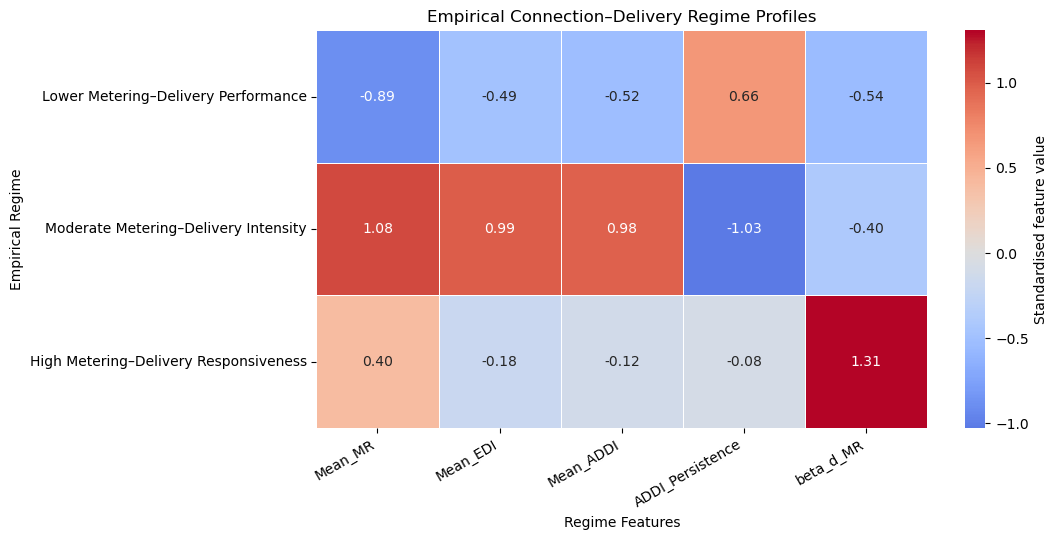

In [188]:
# FIGURE RQ4.1 — Final empirical regime profiles

heatmap_data = (
    RQ4_CENTROIDS
    .copy()
)

heatmap_data["Regime_Name"] = (
    heatmap_data["Regime_ID"]
    .map(REGIME_NAMES)
)

heatmap_data = heatmap_data.set_index(
    "Regime_Name"
)[feature_cols]

plt.figure(figsize=(11, 5.5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.4,
    cbar_kws={"label": "Standardised feature value"}
)

plt.title(
    "Empirical Connection–Delivery Regime Profiles"
)

plt.xlabel("Regime Features")
plt.ylabel("Empirical Regime")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ4_final_regime_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

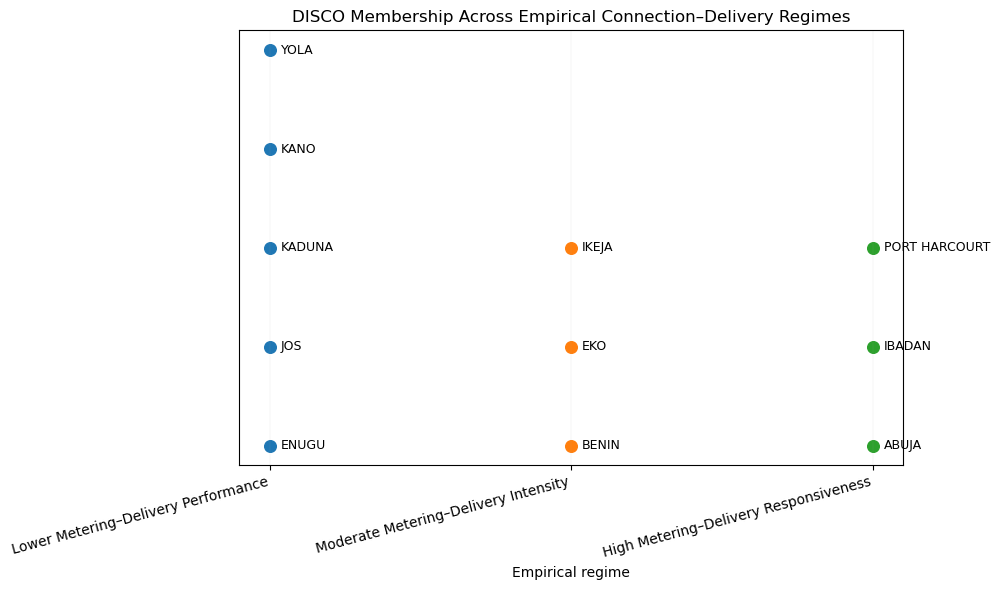

In [189]:
# FIGURE RQ4.2 — DISCO regime membership

membership = (
    RQ4_ASSIGNMENT
    .sort_values(["Regime_ID", "DISCO"])
)

fig, ax = plt.subplots(figsize=(10, 6))

for regime_id, group in membership.groupby("Regime_ID"):

    ax.scatter(
        [regime_id] * len(group),
        np.arange(len(group)),
        s=70
    )

    for y, disco in enumerate(group["DISCO"]):
        ax.annotate(
            disco,
            (regime_id, y),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=9
        )

ax.set_xticks(
    sorted(membership["Regime_ID"].unique())
)

ax.set_xticklabels(
    [
        REGIME_NAMES[i]
        for i in sorted(membership["Regime_ID"].unique())
    ],
    rotation=15,
    ha="right"
)

ax.set_yticks([])

ax.set_xlabel("Empirical regime")
ax.set_title("DISCO Membership Across Empirical Connection–Delivery Regimes")

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ4_regime_membership.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

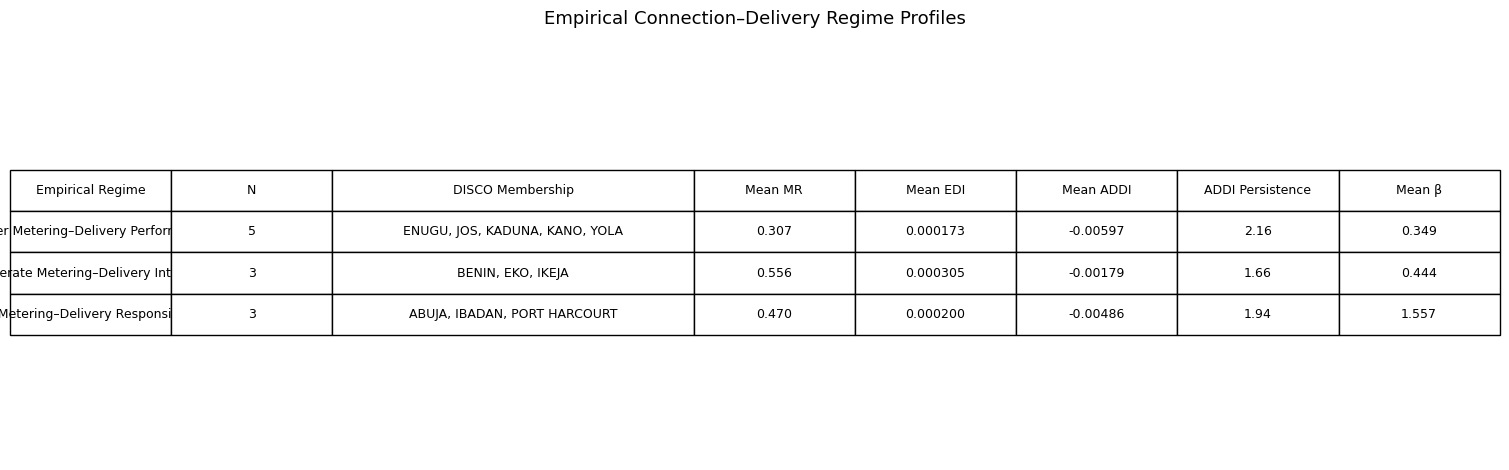

In [190]:
# FIGURE RQ4.2 — Regime profile matrix

regime_display = RQ4_REGIME_SUMMARY.copy()

regime_display["Membership"] = regime_display["DISCOs"]
regime_display["N"] = regime_display["N_DISCOs"]

regime_display = regime_display[
    [
        "Regime_Name",
        "N",
        "Membership",
        "Mean_MR",
        "Mean_EDI",
        "Mean_ADDI",
        "ADDI_Persistence",
        "Mean_beta"
    ]
].copy()

regime_display.columns = [
    "Empirical Regime",
    "N",
    "DISCO Membership",
    "Mean MR",
    "Mean EDI",
    "Mean ADDI",
    "ADDI Persistence",
    "Mean β"
]

fig, ax = plt.subplots(
    figsize=(15, 4.8)
)

ax.axis("off")

table = ax.table(
    cellText=[
        [
            row["Empirical Regime"],
            f"{row['N']:.0f}",
            row["DISCO Membership"],
            f"{row['Mean MR']:.3f}",
            f"{row['Mean EDI']:.6f}",
            f"{row['Mean ADDI']:.5f}",
            f"{row['ADDI Persistence']:.2f}",
            f"{row['Mean β']:.3f}"
        ]
        for _, row in regime_display.iterrows()
    ],
    colLabels=regime_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# Wider membership column
for row in range(len(regime_display) + 1):
    table[(row, 2)].set_width(0.28)

ax.set_title(
    "Empirical Connection–Delivery Regime Profiles",
    fontsize=13,
    pad=15
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ4_regime_profile_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [191]:
# EXPORT — Final RQ4 results

with pd.ExcelWriter(
    TABLE_DIR / "RQ4_Final_Results.xlsx",
    engine="openpyxl"
) as writer:

    RQ4_ASSIGNMENT.to_excel(
        writer,
        sheet_name="Regime_Assignment",
        index=False
    )

    RQ4_REGIME_SUMMARY.to_excel(
        writer,
        sheet_name="Regime_Summary",
        index=False
    )

    RQ4_CENTROIDS.to_excel(
        writer,
        sheet_name="Standardised_Centroids",
        index=False
    )

    RQ4_K_COMPARISON.to_excel(
        writer,
        sheet_name="K_Comparison",
        index=False
    )

    RQ4_STABILITY.to_excel(
        writer,
        sheet_name="Stability",
        index=False
    )

    RQ4_K_DECISION.to_excel(
        writer,
        sheet_name="K_Decision",
        index=False
    )

print(
    "Saved:",
    TABLE_DIR / "RQ4_Final_Results.xlsx"
)

Saved: /Users/goldenofforson/outputs/tables/RQ4_Final_Results.xlsx


R4 DONE 

RQ 5
RQ5_SAMPLE_GATE
RQ5_BREAK_SEARCH
RQ5_BREAK_VALIDATION
RQ5_PRE_POST_CCE
RQ5_PAIRED_COMPARISON
RQ5_REGIME_INTEGRATION
RQ5_FINAL_EXPORT

In [145]:
# RQ5.1 — Prepare structural-change dataset

RQ5_PANEL = PANEL_ANALYSIS[
    ["DISCO", "DATE", "ln_EDI", "MR", "d_MR"]
].copy()

RQ5_PANEL = RQ5_PANEL.sort_values(
    ["DISCO", "DATE"]
).reset_index(drop=True)

RQ5_PANEL["ln_EDI_lag1"] = (
    RQ5_PANEL.groupby("DISCO")["ln_EDI"]
    .shift(1)
)

print("RQ5 panel shape:", RQ5_PANEL.shape)
display(RQ5_PANEL.head())

RQ5 panel shape: (1188, 6)


,DISCO,DATE,ln_EDI,MR,d_MR,ln_EDI_lag1
0,ABUJA,2015-01-01,-8.012584,0.480803,NaN,NaN
1,ABUJA,2015-02-01,-8.001185,0.474404,-0.006398,-8.012584
2,ABUJA,2015-03-01,-8.061399,0.490591,0.016187,-8.001185
3,ABUJA,2015-04-01,-8.088545,0.498679,0.008088,-8.061399
4,ABUJA,2015-05-01,-8.203268,0.504818,0.006139,-8.088545


In [146]:
# RQ5.2 — Construct cross-sectional averages

RQ5_PANEL["CSA_ln_EDI"] = (
    RQ5_PANEL.groupby("DATE")["ln_EDI"]
    .transform("mean")
)

RQ5_PANEL["CSA_ln_EDI_lag1"] = (
    RQ5_PANEL.groupby("DISCO")["CSA_ln_EDI"]
    .shift(1)
)

RQ5_PANEL["CSA_d_MR"] = (
    RQ5_PANEL.groupby("DATE")["d_MR"]
    .transform("mean")
)

for lag in range(1, 5):
    RQ5_PANEL[f"CSA_ln_EDI_lag{lag}"] = (
        RQ5_PANEL.groupby("DISCO")["CSA_ln_EDI"]
        .shift(lag)
    )

    RQ5_PANEL[f"CSA_d_MR_lag{lag}"] = (
        RQ5_PANEL.groupby("DISCO")["CSA_d_MR"]
        .shift(lag)
    )

print("RQ5 variables constructed.")

RQ5 variables constructed.


In [147]:
# RQ5.3 — Define candidate break dates

SEARCH_START = pd.Timestamp("2016-07-01")
SEARCH_END = pd.Timestamp("2022-08-01")

candidate_dates = pd.date_range(
    SEARCH_START,
    SEARCH_END,
    freq="MS"
)

print("Candidate break dates:", len(candidate_dates))
print("Search window:", SEARCH_START.date(), "→", SEARCH_END.date())

Candidate break dates: 74
Search window: 2016-07-01 → 2022-08-01


In [150]:
# RQ5.4 — Prepare complete break-search sample

break_vars = [
    "ln_EDI",
    "ln_EDI_lag1",
    "d_MR",
    "CSA_ln_EDI",
    "CSA_ln_EDI_lag1",
    "CSA_ln_EDI_lag2",
    "CSA_ln_EDI_lag3",
    "CSA_ln_EDI_lag4",
    "CSA_d_MR",
    "CSA_d_MR_lag1",
    "CSA_d_MR_lag2",
    "CSA_d_MR_lag3",
    "CSA_d_MR_lag4"
]

RQ5_BREAK_DATA = (
    RQ5_PANEL[
        ["DISCO", "DATE"] + break_vars
    ]
    .dropna()
    .sort_values(["DISCO", "DATE"])
    .reset_index(drop=True)
)

print("Break-search sample:", RQ5_BREAK_DATA.shape)

Break-search sample: (1133, 15)


In [152]:
# RQ5.5 — Common structural-break screen

from scipy.stats import chi2

break_results = []

base_vars = [
    "ln_EDI_lag1",
    "d_MR",
    "CSA_ln_EDI",
    "CSA_ln_EDI_lag1",
    "CSA_ln_EDI_lag2",
    "CSA_ln_EDI_lag3",
    "CSA_ln_EDI_lag4",
    "CSA_d_MR",
    "CSA_d_MR_lag1",
    "CSA_d_MR_lag2",
    "CSA_d_MR_lag3",
    "CSA_d_MR_lag4"
]

for tau in candidate_dates:

    d = RQ5_BREAK_DATA.copy()

    d["POST"] = (d["DATE"] > tau).astype(int)
    d["dMR_POST"] = d["d_MR"] * d["POST"]

    X_cols = base_vars + ["POST", "dMR_POST"]

    X = sm.add_constant(
        d[X_cols].astype(float),
        has_constant="add"
    )

    model = sm.OLS(
        d["ln_EDI"].astype(float),
        X
    ).fit(cov_type="HC1")

    delta = model.params["dMR_POST"]
    se_delta = model.bse["dMR_POST"]

    wald = (delta / se_delta) ** 2
    p_value = chi2.sf(wald, 1)

    break_results.append({
        "Break_Date": tau,
        "Wald": wald,
        "p_value": p_value,
        "Beta_Shift": delta
    })

RQ5_BREAK_SCREEN = pd.DataFrame(break_results)

display(
    RQ5_BREAK_SCREEN
    .sort_values("Wald", ascending=False)
    .head(10)
    .round(6)
)

,Break_Date,Wald,p_value,Beta_Shift
22,2018-05-01,26.494136,0.000000,0.986352
23,2018-06-01,23.012891,0.000002,0.967590
24,2018-07-01,22.938167,0.000002,0.971113
25,2018-08-01,22.327784,0.000002,0.960630
30,2019-01-01,13.560202,0.000231,1.174018
57,2021-04-01,13.512470,0.000237,1.259486
32,2019-03-01,13.405541,0.000251,1.174964
29,2018-12-01,13.397625,0.000252,1.168557
33,2019-04-01,13.357703,0.000257,1.176919
28,2018-11-01,13.175310,0.000284,1.162198


In [153]:
# RQ5.6 — Identify strongest candidate break

best_break = (
    RQ5_BREAK_SCREEN
    .sort_values("Wald", ascending=False)
    .iloc[0]
)

BREAK_DATE = best_break["Break_Date"]

print("Strongest candidate:", BREAK_DATE.date())
print("Wald:", round(best_break["Wald"], 6))
print("p-value:", round(best_break["p_value"], 8))
print("Estimated beta shift:", round(best_break["Beta_Shift"], 6))

Strongest candidate: 2018-05-01
Wald: 26.494136
p-value: 2.6e-07
Estimated beta shift: 0.986352


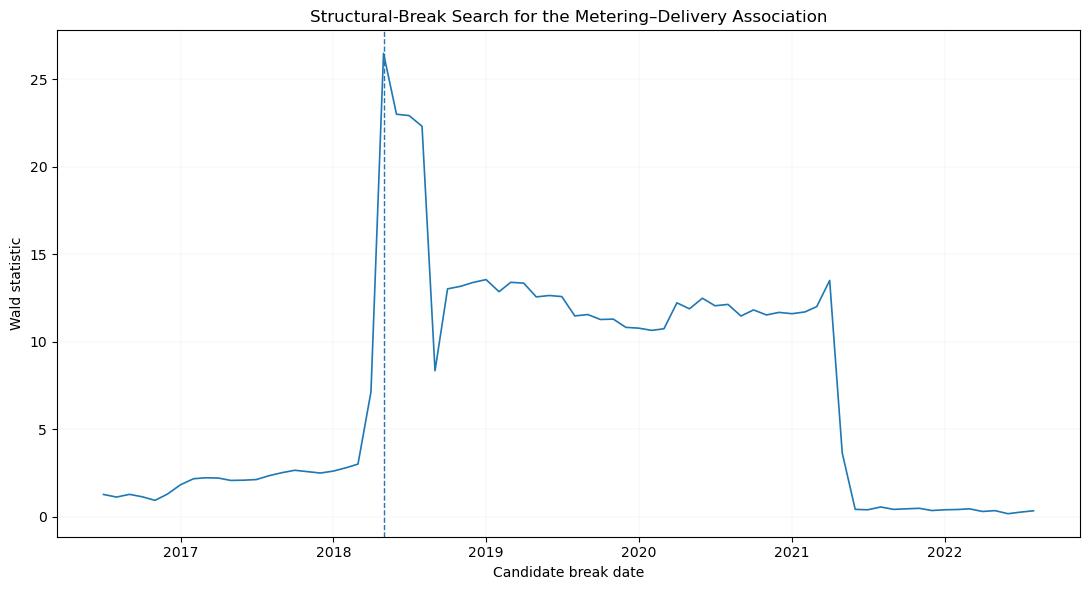

In [154]:
# FIGURE RQ5.1 — Structural-break search

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    RQ5_BREAK_SCREEN["Break_Date"],
    RQ5_BREAK_SCREEN["Wald"],
    linewidth=1.2
)

ax.axvline(
    BREAK_DATE,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Structural-Break Search for the Metering–Delivery Association"
)

ax.set_xlabel("Candidate break date")
ax.set_ylabel("Wald statistic")

ax.grid(
    True,
    linewidth=0.3,
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ5_structural_break_search.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

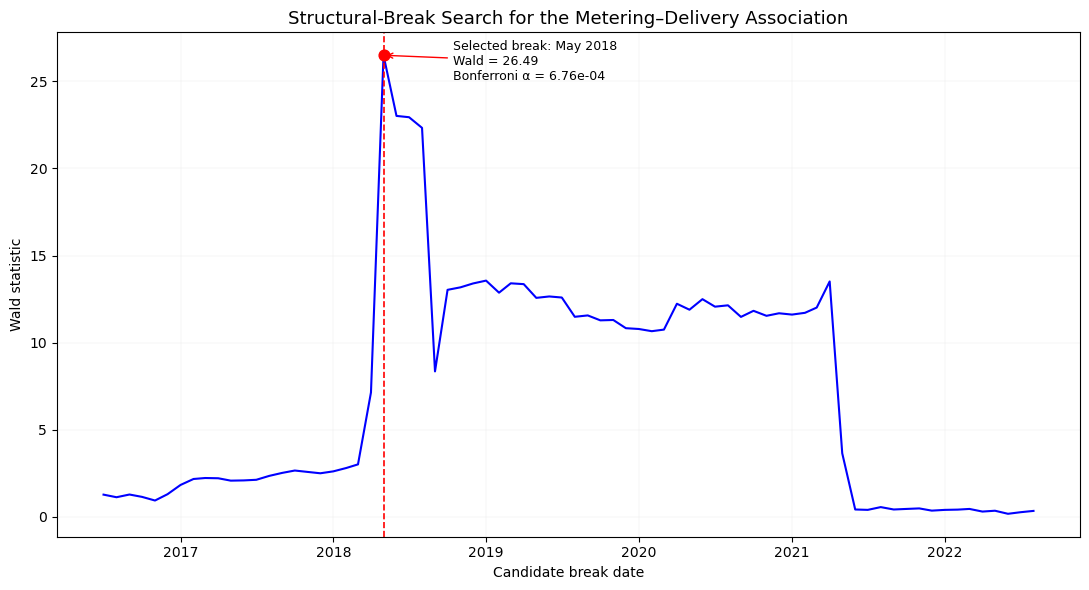

Bonferroni alpha = 6.756757e-04


In [184]:
# FIGURE RQ5.1 — Structural-break search
# Blue = Wald trend; Red = selected break

fig, ax = plt.subplots(figsize=(11, 6))

# Bonferroni threshold
M_BREAKS = len(RQ5_BREAK_SCREEN)
bonferroni_alpha = 0.05 / M_BREAKS

# Wald-statistic trend
ax.plot(
    RQ5_BREAK_SCREEN["Break_Date"],
    RQ5_BREAK_SCREEN["Wald"],
    color="blue",
    linewidth=1.5
)

# Selected break point
ax.scatter(
    BREAK_DATE,
    best_break["Wald"],
    color="red",
    s=60,
    zorder=5
)

# Selected break vertical line
ax.axvline(
    BREAK_DATE,
    color="red",
    linestyle="--",
    linewidth=1.2
)

# Selected break annotation
ax.annotate(
    f"Selected break: {BREAK_DATE.strftime('%B %Y')}\n"
    f"Wald = {best_break['Wald']:.2f}\n"
    f"Bonferroni α = {bonferroni_alpha:.2e}",
    xy=(BREAK_DATE, best_break["Wald"]),
    xytext=(50, -20),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    color="black",
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        linewidth=1
    )
)

ax.set_title(
    "Structural-Break Search for the Metering–Delivery Association",
    fontsize=13
)

ax.set_xlabel("Candidate break date")
ax.set_ylabel("Wald statistic")

ax.grid(
    True,
    linewidth=0.3,
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ5_structural_break_search.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Bonferroni alpha = {bonferroni_alpha:.6e}")

In [155]:
# RQ5.7 — Bonferroni validation of the strongest break

M_BREAKS = len(RQ5_BREAK_SCREEN)

raw_p = best_break["p_value"]

bonferroni_alpha = 0.05 / M_BREAKS
bonferroni_p = min(raw_p * M_BREAKS, 1.0)

BREAK_VALIDATION = pd.DataFrame({
    "Statistic": [
        "Candidate break dates",
        "Selected break date",
        "Wald statistic",
        "Raw p-value",
        "Bonferroni alpha",
        "Bonferroni-adjusted p-value",
        "Beta shift"
    ],
    "Value": [
        M_BREAKS,
        BREAK_DATE,
        best_break["Wald"],
        raw_p,
        bonferroni_alpha,
        bonferroni_p,
        best_break["Beta_Shift"]
    ]
})

display(BREAK_VALIDATION)

,Statistic,Value
0,Candidate break dates,74
1,Selected break date,2018-05-01 00:00:00
2,Wald statistic,26.494136
3,Raw p-value,0.0
4,Bonferroni alpha,0.000676
5,Bonferroni-adjusted p-value,0.00002
6,Beta shift,0.986352


In [156]:
# RQ5.8 — Inspect local structural-break region

local_breaks = (
    RQ5_BREAK_SCREEN[
        (RQ5_BREAK_SCREEN["Break_Date"] >= "2018-05-01") &
        (RQ5_BREAK_SCREEN["Break_Date"] <= "2018-08-01")
    ]
    .sort_values("Break_Date")
    .copy()
)

display(
    local_breaks.round(6)
)

,Break_Date,Wald,p_value,Beta_Shift
22,2018-05-01,26.494136,0.000000,0.986352
23,2018-06-01,23.012891,0.000002,0.967590
24,2018-07-01,22.938167,0.000002,0.971113
25,2018-08-01,22.327784,0.000002,0.960630


In [157]:
# RQ5.9 — Define pre- and post-break periods

RQ5_PRE_DATA = RQ5_PANEL[
    RQ5_PANEL["DATE"] <= BREAK_DATE
].copy()

RQ5_POST_DATA = RQ5_PANEL[
    RQ5_PANEL["DATE"] > BREAK_DATE
].copy()

print(
    "Pre-break:",
    RQ5_PRE_DATA["DATE"].min().date(),
    "→",
    RQ5_PRE_DATA["DATE"].max().date()
)

print(
    "Post-break:",
    RQ5_POST_DATA["DATE"].min().date(),
    "→",
    RQ5_POST_DATA["DATE"].max().date()
)

print("\nRows:")
print("Pre:", len(RQ5_PRE_DATA))
print("Post:", len(RQ5_POST_DATA))

Pre-break: 2015-01-01 → 2018-05-01
Post-break: 2018-06-01 → 2023-12-01

Rows:
Pre: 451
Post: 737


In [158]:
# RQ5.10 — Prepare complete pre/post CCE-MG samples

def prepare_rq5_sample(data):
    
    return (
        data[
            ["DISCO", "DATE"] + break_vars
        ]
        .dropna()
        .sort_values(["DISCO", "DATE"])
        .reset_index(drop=True)
    )

PRE_CCE_DATA = prepare_rq5_sample(RQ5_PRE_DATA)
POST_CCE_DATA = prepare_rq5_sample(RQ5_POST_DATA)

print("Pre-break CCE sample:", PRE_CCE_DATA.shape)
print("Post-break CCE sample:", POST_CCE_DATA.shape)

Pre-break CCE sample: (396, 15)
Post-break CCE sample: (737, 15)


In [159]:
# RQ5.11 — Estimate pre/post DISCO-specific CCE-MG coefficients

def estimate_period_cce(data):

    results = []

    x_vars = [
        "d_MR",
        "CSA_ln_EDI",
        "CSA_ln_EDI_lag1",
        "CSA_ln_EDI_lag2",
        "CSA_ln_EDI_lag3",
        "CSA_ln_EDI_lag4",
        "CSA_d_MR",
        "CSA_d_MR_lag1",
        "CSA_d_MR_lag2",
        "CSA_d_MR_lag3",
        "CSA_d_MR_lag4"
    ]

    for disco, g in data.groupby("DISCO"):

        y = g["ln_EDI"].astype(float)

        X = g[
            ["ln_EDI_lag1"] + x_vars
        ].astype(float)

        X = sm.add_constant(X, has_constant="add")

        model = sm.OLS(y, X).fit(cov_type="HC1")

        results.append({
            "DISCO": disco,
            "N": int(model.nobs),
            "beta_d_MR": model.params["d_MR"],
            "SE_beta": model.bse["d_MR"],
            "p_beta": model.pvalues["d_MR"]
        })

    return pd.DataFrame(results)

RQ5_PRE_CCE_MG = estimate_period_cce(PRE_CCE_DATA)
RQ5_POST_CCE_MG = estimate_period_cce(POST_CCE_DATA)

print("PRE-BREAK")
display(RQ5_PRE_CCE_MG.round(6))

print("\nPOST-BREAK")
display(RQ5_POST_CCE_MG.round(6))

PRE-BREAK


,DISCO,N,beta_d_MR,SE_beta,p_beta
0,ABUJA,36,0.690781,0.696483,0.321289
1,BENIN,36,1.294058,0.429669,0.002597
2,EKO,36,0.916350,1.509187,0.543731
3,ENUGU,36,-1.518808,1.546314,0.325995
4,IBADAN,36,2.421042,0.539145,0.000007
5,IKEJA,36,-0.096247,0.490830,0.844539
6,JOS,36,-3.044078,3.012651,0.312289
7,KADUNA,36,0.757807,0.311691,0.015046
8,KANO,36,0.687756,0.253761,0.006723
9,PORT HARCOURT,36,0.453102,0.412840,0.272412



POST-BREAK


,DISCO,N,beta_d_MR,SE_beta,p_beta
0,ABUJA,67,1.055493,0.140658,0.000000
1,BENIN,67,1.313708,0.738142,0.075117
2,EKO,67,-0.529817,2.414189,0.826292
3,ENUGU,67,0.182835,0.865834,0.832757
4,IBADAN,67,2.213656,1.192478,0.063404
5,IKEJA,67,0.985669,0.594867,0.097528
6,JOS,67,1.595597,0.754941,0.034555
7,KADUNA,67,-0.165745,0.346457,0.632367
8,KANO,67,1.015525,1.528659,0.506483
9,PORT HARCOURT,67,2.152781,0.355153,0.000000


In [160]:
# RQ5.12 — Pre/post Mean Group comparison

pre_beta = RQ5_PRE_CCE_MG["beta_d_MR"].mean()
post_beta = RQ5_POST_CCE_MG["beta_d_MR"].mean()

beta_change = post_beta - pre_beta

RQ5_PERIOD_SUMMARY = pd.DataFrame({
    "Period": [
        "Pre-break",
        "Post-break",
        "Change"
    ],
    "Mean_beta": [
        pre_beta,
        post_beta,
        beta_change
    ]
})

display(
    RQ5_PERIOD_SUMMARY.round(6)
)

,Period,Mean_beta
0,Pre-break,0.156244
1,Post-break,0.839995
2,Change,0.683751


In [161]:
# RQ5.13 — DISCO-specific pre/post coefficient changes

RQ5_BETA_COMPARISON = (
    RQ5_PRE_CCE_MG[
        ["DISCO", "beta_d_MR"]
    ]
    .rename(columns={
        "beta_d_MR": "Beta_Pre"
    })
    .merge(
        RQ5_POST_CCE_MG[
            ["DISCO", "beta_d_MR"]
        ].rename(columns={
            "beta_d_MR": "Beta_Post"
        }),
        on="DISCO",
        how="inner"
    )
)

RQ5_BETA_COMPARISON["Beta_Change"] = (
    RQ5_BETA_COMPARISON["Beta_Post"]
    - RQ5_BETA_COMPARISON["Beta_Pre"]
)

display(
    RQ5_BETA_COMPARISON.round(6)
)

,DISCO,Beta_Pre,Beta_Post,Beta_Change
0,ABUJA,0.690781,1.055493,0.364712
1,BENIN,1.294058,1.313708,0.019650
2,EKO,0.916350,-0.529817,-1.446167
3,ENUGU,-1.518808,0.182835,1.701643
4,IBADAN,2.421042,2.213656,-0.207386
5,IKEJA,-0.096247,0.985669,1.081917
6,JOS,-3.044078,1.595597,4.639675
7,KADUNA,0.757807,-0.165745,-0.923552
8,KANO,0.687756,1.015525,0.327769
9,PORT HARCOURT,0.453102,2.152781,1.699678


In [162]:
# RQ5.14 — Paired comparison of pre- and post-break coefficients

from scipy.stats import ttest_rel, wilcoxon

paired = RQ5_BETA_COMPARISON.dropna(
    subset=["Beta_Pre", "Beta_Post"]
).copy()

paired_t = ttest_rel(
    paired["Beta_Post"],
    paired["Beta_Pre"]
)

wilcoxon_test = wilcoxon(
    paired["Beta_Post"],
    paired["Beta_Pre"],
    alternative="two-sided"
)

RQ5_PAIRED_TEST = pd.DataFrame({
    "Test": [
        "Paired t-test",
        "Wilcoxon signed-rank"
    ],
    "Statistic": [
        paired_t.statistic,
        wilcoxon_test.statistic
    ],
    "p_value": [
        paired_t.pvalue,
        wilcoxon_test.pvalue
    ]
})

display(
    RQ5_PAIRED_TEST.round(6)
)

,Test,Statistic,p_value
0,Paired t-test,1.389491,0.194842
1,Wilcoxon signed-rank,16.000000,0.147461


In [163]:
# RQ5.15 — Direction of DISCO-specific coefficient changes

n_increase = (
    paired["Beta_Change"] > 0
).sum()

n_decrease = (
    paired["Beta_Change"] < 0
).sum()

n_no_change = (
    paired["Beta_Change"] == 0
).sum()

RQ5_DIRECTION = pd.DataFrame({
    "Statistic": [
        "DISCOs with increased beta",
        "DISCOs with decreased beta",
        "DISCOs with no change",
        "Mean beta change",
        "Median beta change"
    ],
    "Value": [
        n_increase,
        n_decrease,
        n_no_change,
        paired["Beta_Change"].mean(),
        paired["Beta_Change"].median()
    ]
})

display(
    RQ5_DIRECTION.round(6)
)

,Statistic,Value
0,DISCOs with increased beta,8.000000
1,DISCOs with decreased beta,3.000000
2,DISCOs with no change,0.000000
3,Mean beta change,0.683751
4,Median beta change,0.327769


In [192]:
# RQ5.16 — Structural change by empirical regime

RQ5_REGIME_CHANGE = (
    RQ5_BETA_COMPARISON
    .merge(
        RQ4_ASSIGNMENT[
            ["DISCO", "Regime_ID", "Regime_Name"]
        ],
        on="DISCO",
        how="left"
    )
)

RQ5_REGIME_CHANGE_SUMMARY = (
    RQ5_REGIME_CHANGE
    .groupby(
        ["Regime_ID", "Regime_Name"]
    )
    .agg(
        N_DISCOs=("DISCO", "size"),
        Mean_Beta_Pre=("Beta_Pre", "mean"),
        Mean_Beta_Post=("Beta_Post", "mean"),
        Mean_Beta_Change=("Beta_Change", "mean"),
        DISCOs=("DISCO", lambda x: ", ".join(x))
    )
    .reset_index()
)

display(
    RQ5_REGIME_CHANGE_SUMMARY.round(6)
)

,Regime_ID,Regime_Name,N_DISCOs,Mean_Beta_Pre,Mean_Beta_Post,Mean_Beta_Change,DISCOs
0,0,Lower Metering–Delivery Performance,5,-0.792081,0.409690,1.201771,"ENUGU, JOS, KADUNA, KANO, YOLA"
1,1,Moderate Metering–Delivery Intensity,3,0.704720,0.589853,-0.114867,"BENIN, EKO, IKEJA"
2,2,High Metering–Delivery Responsiveness,3,1.188309,1.807310,0.619001,"ABUJA, IBADAN, PORT HARCOURT"


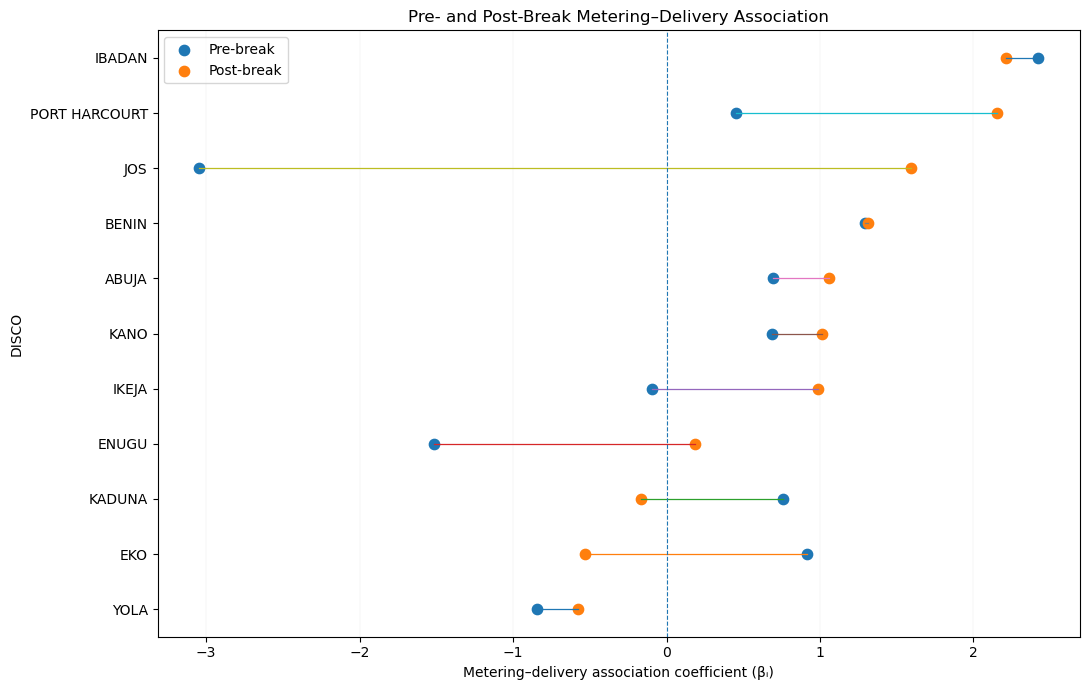

In [165]:
# FIGURE RQ5.2 — Pre/post DISCO-specific coefficients

plot_df = (
    RQ5_BETA_COMPARISON
    .sort_values("Beta_Post")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

y = np.arange(len(plot_df))

ax.scatter(
    plot_df["Beta_Pre"],
    y,
    label="Pre-break",
    s=55
)

ax.scatter(
    plot_df["Beta_Post"],
    y,
    label="Post-break",
    s=55
)

for i, row in plot_df.iterrows():

    ax.plot(
        [row["Beta_Pre"], row["Beta_Post"]],
        [i, i],
        linewidth=0.9
    )

ax.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["DISCO"])

ax.set_xlabel(
    "Metering–delivery association coefficient (βᵢ)"
)

ax.set_ylabel("DISCO")

ax.set_title(
    "Pre- and Post-Break Metering–Delivery Association"
)

ax.legend()

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ5_pre_post_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

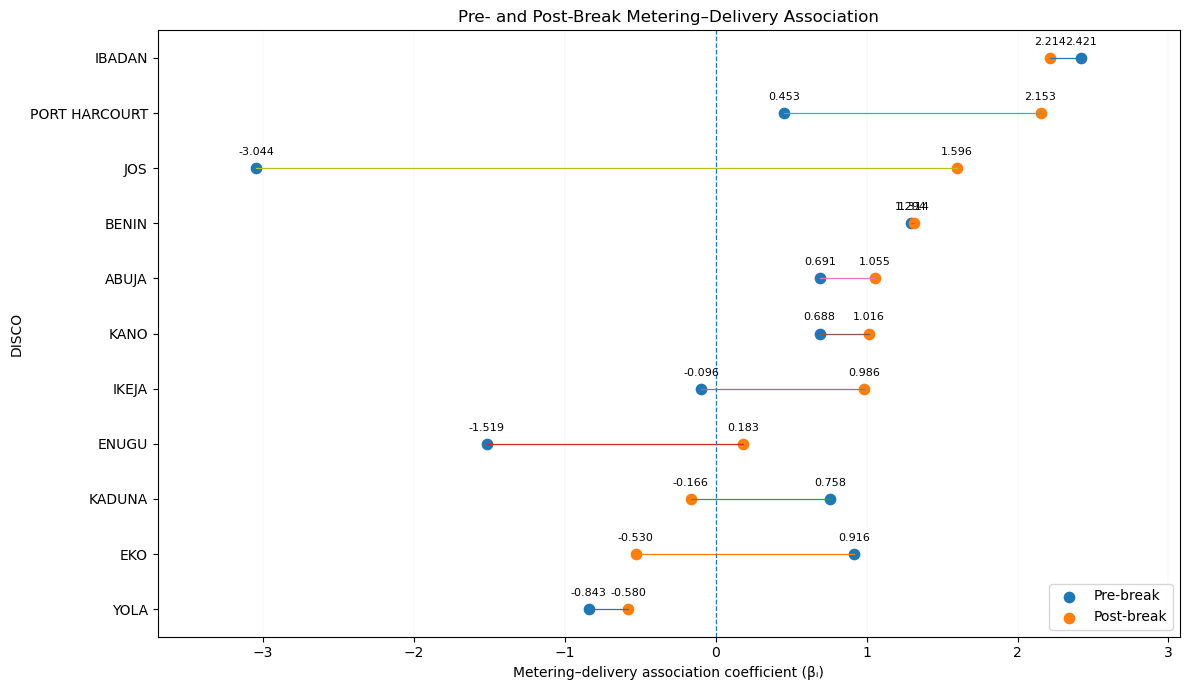

In [166]:
# FIGURE RQ5.2 — Quantified pre/post DISCO-specific coefficients

plot_df = (
    RQ5_BETA_COMPARISON
    .sort_values("Beta_Post")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 7))

y = np.arange(len(plot_df))

# Pre-break estimates
ax.scatter(
    plot_df["Beta_Pre"],
    y,
    s=55,
    label="Pre-break"
)

# Post-break estimates
ax.scatter(
    plot_df["Beta_Post"],
    y,
    s=55,
    label="Post-break"
)

# Connecting lines
for i, row in plot_df.iterrows():

    ax.plot(
        [row["Beta_Pre"], row["Beta_Post"]],
        [i, i],
        linewidth=0.9
    )

    # Pre-break coefficient label
    ax.annotate(
        f"{row['Beta_Pre']:.3f}",
        xy=(row["Beta_Pre"], i),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8
    )

    # Post-break coefficient label
    ax.annotate(
        f"{row['Beta_Post']:.3f}",
        xy=(row["Beta_Post"], i),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Zero-association reference
ax.axvline(
    0,
    linestyle="--",
    linewidth=0.9
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["DISCO"])

ax.set_xlabel(
    "Metering–delivery association coefficient (βᵢ)"
)

ax.set_ylabel("DISCO")

ax.set_title(
    "Pre- and Post-Break Metering–Delivery Association"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

ax.margins(x=0.12)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ5_pre_post_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

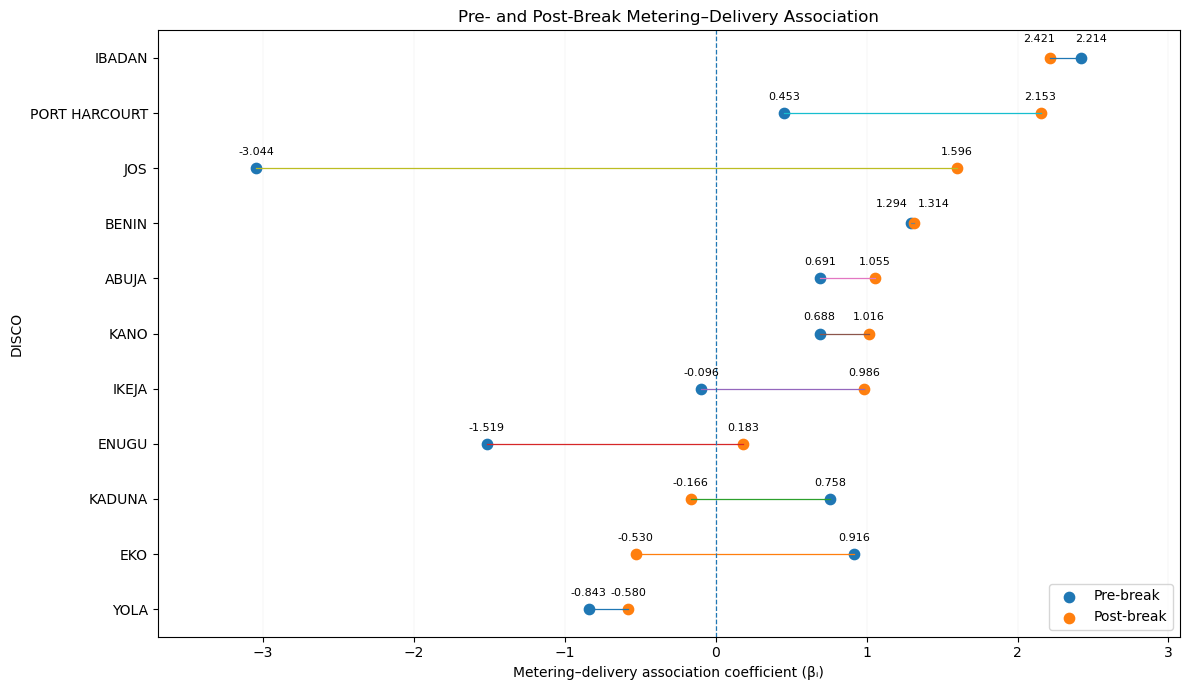

In [172]:
# FIGURE RQ5.2 — Quantified pre/post DISCO-specific coefficients

plot_df = (
    RQ5_BETA_COMPARISON
    .sort_values("Beta_Post")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 7))

y = np.arange(len(plot_df))

# Plot pre-break estimates
ax.scatter(
    plot_df["Beta_Pre"],
    y,
    s=55,
    label="Pre-break"
)

# Plot post-break estimates
ax.scatter(
    plot_df["Beta_Post"],
    y,
    s=55,
    label="Post-break"
)

# Connecting lines
for i, row in plot_df.iterrows():

    ax.plot(
        [row["Beta_Pre"], row["Beta_Post"]],
        [i, i],
        linewidth=0.9
    )

    disco = row["DISCO"]

    # Default label placement
    pre_offset = (0, 8)
    post_offset = (0, 8)

    # Special placement: BENIN
    if disco == "BENIN":
        pre_offset = (-14, 10)
        post_offset = (14, 10)

    # Special placement: IBADAN
    elif disco == "IBADAN":
        pre_offset = (-30, 10)
        post_offset = (30, 10)

    # Pre-break label
    ax.annotate(
        f"{row['Beta_Pre']:.3f}",
        xy=(row["Beta_Pre"], i),
        xytext=pre_offset,
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8
    )

    # Post-break label
    ax.annotate(
        f"{row['Beta_Post']:.3f}",
        xy=(row["Beta_Post"], i),
        xytext=post_offset,
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Zero-association reference
ax.axvline(
    0,
    linestyle="--",
    linewidth=0.9
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["DISCO"])

ax.set_xlabel(
    "Metering–delivery association coefficient (βᵢ)"
)

ax.set_ylabel("DISCO")

ax.set_title(
    "Pre- and Post-Break Metering–Delivery Association"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

ax.margins(x=0.12)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ5_pre_post_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [173]:
# RQ5.18 — Final structural-change summary

RQ5_FINAL_SUMMARY = pd.DataFrame({
    "Statistic": [
        "Selected break date",
        "Wald statistic",
        "Raw p-value",
        "Bonferroni-adjusted p-value",
        "Mean beta pre-break",
        "Mean beta post-break",
        "Mean beta change",
        "Paired t-test p-value",
        "Wilcoxon p-value",
        "DISCOs increasing",
        "DISCOs decreasing"
    ],
    "Value": [
        BREAK_DATE,
        best_break["Wald"],
        best_break["p_value"],
        bonferroni_p,
        pre_beta,
        post_beta,
        beta_change,
        paired_t.pvalue,
        wilcoxon_test.pvalue,
        n_increase,
        n_decrease
    ]
})

display(
    RQ5_FINAL_SUMMARY.round(6)
)

,Statistic,Value
0,Selected break date,2018-05-01 00:00:00
1,Wald statistic,26.494136
2,Raw p-value,0.0
3,Bonferroni-adjusted p-value,0.00002
4,Mean beta pre-break,0.156244
5,Mean beta post-break,0.839995
6,Mean beta change,0.683751
7,Paired t-test p-value,0.194842
8,Wilcoxon p-value,0.147461
9,DISCOs increasing,8


In [174]:
# EXPORT — Final RQ5 results

with pd.ExcelWriter(
    TABLE_DIR / "RQ5_Final_Results.xlsx",
    engine="openpyxl"
) as writer:

    RQ5_FINAL_SUMMARY.to_excel(
        writer,
        sheet_name="RQ5_Summary",
        index=False
    )

    RQ5_BREAK_SCREEN.to_excel(
        writer,
        sheet_name="Break_Screen",
        index=False
    )

    BREAK_VALIDATION.to_excel(
        writer,
        sheet_name="Break_Validation",
        index=False
    )

    RQ5_PRE_CCE_MG.to_excel(
        writer,
        sheet_name="Pre_Break_CCE",
        index=False
    )

    RQ5_POST_CCE_MG.to_excel(
        writer,
        sheet_name="Post_Break_CCE",
        index=False
    )

    RQ5_BETA_COMPARISON.to_excel(
        writer,
        sheet_name="Pre_Post_Coefficients",
        index=False
    )

    RQ5_PAIRED_TEST.to_excel(
        writer,
        sheet_name="Paired_Tests",
        index=False
    )

    RQ5_DIRECTION.to_excel(
        writer,
        sheet_name="Direction_Change",
        index=False
    )

    RQ5_REGIME_CHANGE_SUMMARY.to_excel(
        writer,
        sheet_name="Regime_Change",
        index=False
    )

print(
    "Saved:",
    TABLE_DIR / "RQ5_Final_Results.xlsx"
)

Saved: /Users/goldenofforson/outputs/tables/RQ5_Final_Results.xlsx


/var/folders/nc/fj81kn452j50b6gvr_846hbr0000gn/T/ipykernel_12710/2963820691.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


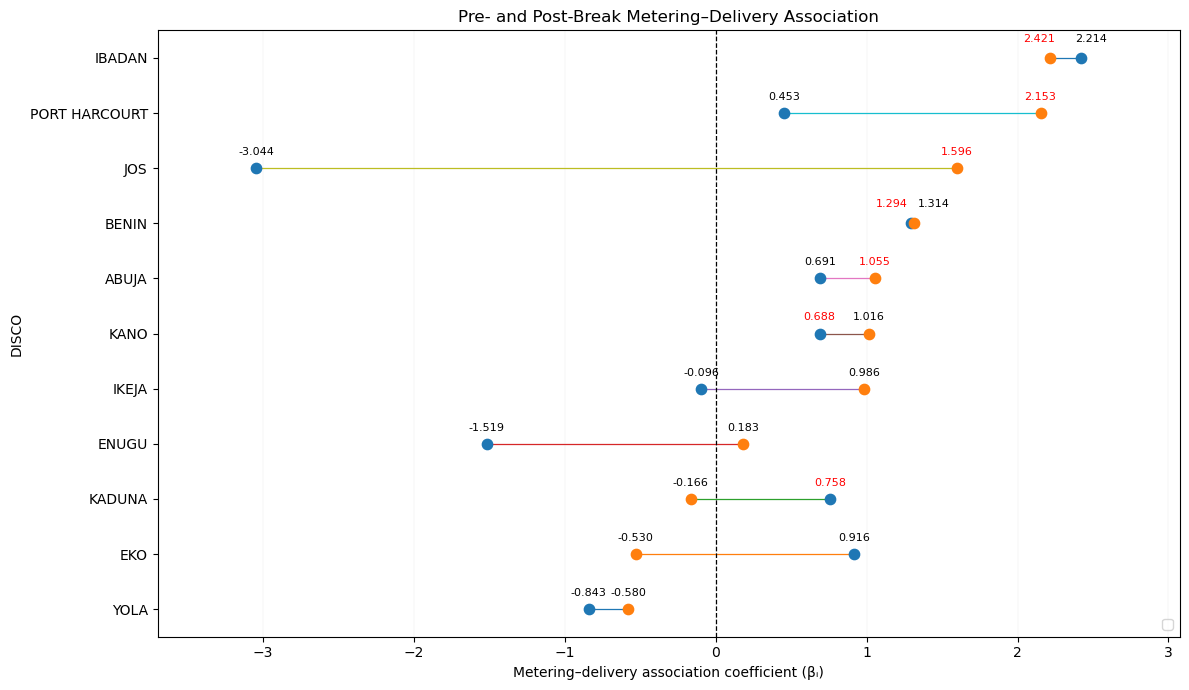

In [194]:
# FIGURE RQ5.2 — Quantified pre/post DISCO-specific coefficients
# Red labels = statistically significant coefficients (p < 0.05)

plot_df = (
    RQ5_BETA_COMPARISON
    .merge(
        RQ5_PRE_CCE_MG[["DISCO", "p_beta"]]
        .rename(columns={"p_beta": "p_Pre"}),
        on="DISCO",
        how="left"
    )
    .merge(
        RQ5_POST_CCE_MG[["DISCO", "p_beta"]]
        .rename(columns={"p_beta": "p_Post"}),
        on="DISCO",
        how="left"
    )
    .sort_values("Beta_Post")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 7))

y = np.arange(len(plot_df))

# Period colours
pre_color = "tab:blue"
post_color = "tab:orange"

for i, row in plot_df.iterrows():

    beta_pre = float(row["Beta_Pre"])
    beta_post = float(row["Beta_Post"])

    # Plot points
    ax.scatter(
        beta_pre,
        i,
        color=pre_color,
        s=55,
        zorder=3
    )

    ax.scatter(
        beta_post,
        i,
        color=post_color,
        s=55,
        zorder=3
    )

    # Connecting line
    ax.plot(
        [beta_pre, beta_post],
        [i, i],
        linewidth=0.9
    )

    # Significance colours for labels only
    pre_label_color = (
        "red" if float(row["p_Pre"]) < 0.05
        else "black"
    )

    post_label_color = (
        "red" if float(row["p_Post"]) < 0.05
        else "black"
    )

    # Default label positions
    pre_offset = (0, 8)
    post_offset = (0, 8)

    # Resolve close labels
    if row["DISCO"] == "BENIN":
        pre_offset = (-14, 10)
        post_offset = (14, 10)

    elif row["DISCO"] == "IBADAN":
        pre_offset = (-30, 10)
        post_offset = (30, 10)

    # Pre-break coefficient
    ax.annotate(
        f"{beta_pre:.3f}",
        xy=(beta_pre, i),
        xytext=pre_offset,
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color=pre_label_color
    )

    # Post-break coefficient
    ax.annotate(
        f"{beta_post:.3f}",
        xy=(beta_post, i),
        xytext=post_offset,
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color=post_label_color
    )

# Zero-association reference
ax.axvline(
    0,
    linestyle="--",
    linewidth=0.9,
    color="black"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["DISCO"])

ax.set_xlabel(
    "Metering–delivery association coefficient (βᵢ)"
)

ax.set_ylabel("DISCO")

ax.set_title(
    "Pre- and Post-Break Metering–Delivery Association"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="x",
    linewidth=0.3,
    alpha=0.25
)

ax.margins(x=0.12)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "RQ5_pre_post_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()